# 短时特征绘制

- 数据：`BK00-FIP-1000K-20260829T152356.900.npz`（1 MHz 采样，2 通道，400001 点，约 0.4 s）
- 滑窗：窗长/重叠**不再作为全局统一参数**，由第 1、2、3 节各自定义（本 notebook 各节均取窗长 25 ms、重叠 10 ms，步长 15 ms）
- 横轴：时间（s）；纵轴：特征值
- 特征可指定：短时能量、短时功率、过零率、带内能量/功率/能量占比（频段可指定，如 8–50 kHz）等
- 图内文字均为英文（Times New Roman）
- 预处理：Butterworth 零相位带通（默认 1 kHz–100 kHz、4 阶，`sosfiltfilt`）；**带通范围/阶数各节可调、独立定义**，特征在滤波后信号上计算
- 仅绘制通道 1（`phase_data`）
- 通用函数统一封装在第 0 节；第 1 节对比曲线**参照 2.1 节**补充软阈值异常检测
- 带内特征采用**时域带通法**计算（由滤波器抑制频谱泄漏，无需 FFT 加窗）；频带能量加窗的技术细节见 0.2


## 0. 通用函数库

所有可复用流程均封装为函数放在本节，后续各节直接调用，保证预处理、滑窗、检测口径一致：

- 数据读取：`load_signal`（.npz / .tdms 统一接口）
- 预处理：`preprocess_bandpass`（零相位带通）、`load_preprocessed`（读文件 + 预处理组合）；**带通范围 / 阶数为显式参数，由第 1、2、3 节各自定义传入，不设全局统一值**
- 分帧：`frames` / `frame_times`（窗长 / 步长为**显式参数**，由第 1、2、3 节各自定义传入，不设全局统一值）
- 逐帧特征：`feat_energy` / `feat_power` / `feat_rms` / `feat_zcr`、`short_time_feature`、`short_time_band_feature`、`compute_all_features`
- 异常检测：`soft_threshold`（自适应软阈值）、`detect_events`（异常帧合并为事件）

特征定义与公式见 0.2，软阈值原理见 0.3。

### 0.1 数据读取与预处理

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re
import json

from scipy.signal import butter, sosfiltfilt, correlate

# 全部图统一：英文 + Times New Roman（mathtext 用 STIX 与之匹配）
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'

# Common channel selection used by all sections (0 = first phase channel).
SEL_CH = 0
# ---------- 4.2 节统一样式：标签 / 刻度字号 16 ----------
# 仅影响本节及后续创建的图（第 5 节暂无绘图，不影响）
plt.rcParams['axes.labelsize'] = 18     # 坐标轴标签
plt.rcParams['xtick.labelsize'] = 18    # x 轴刻度
plt.rcParams['ytick.labelsize'] = 18    # y 轴刻度
plt.rcParams['legend.fontsize'] = 18  # 图例
plt.rcParams['axes.titlesize'] = 18    # 标题

%matplotlib inline


def load_signal(path):
    """读取信号数据，兼容 .npz 与 .tdms 两种格式。
    返回 dict：可用 dd['phase_data'] / dd['sample_rate'] / dd['channel_names'] / dd['type']。
    - .npz: 直接取原键；
    - .tdms: phase_data 为按通道列堆叠的 (npts, nch)；sample_rate 从文件名解析（如 1MHz -> 1e6）；
             channel_names 为通道名；type 从文件名推断（bk/qj -> BK/QJ，否则用根属性 name）。
    """
    path = Path(path)
    if path.suffix.lower() == '.npz':
        d = np.load(path, allow_pickle=True)
        out = {k: d[k] for k in d.files}
        d.close()
        return out
    if path.suffix.lower() == '.tdms':
        from nptdms import TdmsFile
        tf = TdmsFile.read(path)
        groups = list(tf.groups())
        if len(groups) == 1:
            chs = list(groups[0].channels())
        else:  # 多 group 时取通道数最多的那个 group
            chs = max((list(g.channels()) for g in groups), key=len)
        ch_names = [ch.name for ch in chs]
        data = np.column_stack([np.asarray(ch[:], dtype=float) for ch in chs])
        name = str(tf.properties.get('name', path.stem))
        m = re.search(r'(\d+(?:\.\d+)?)\s*([kKmMgG]?)[hH]z', name)
        if not m:
            raise ValueError(f'无法从文件名解析采样率: {path.name}')
        fs = float(m.group(1)) * {'': 1, 'k': 1e3, 'K': 1e3, 'm': 1e6, 'M': 1e6, 'g': 1e9, 'G': 1e9}[m.group(2)]
        low = name.lower()
        typ = 'BK' if 'bk' in low else 'QJ' if 'qj' in low else name
        return {'phase_data': data, 'sample_rate': fs, 'channel_names': ch_names, 'type': typ}
    raise ValueError(f'不支持的文件格式: {path.suffix}')


# ---------- 预处理函数：带通范围 / 阶数为显式参数，由各节自行定义（默认 1~100 kHz、4 阶） ----------


def preprocess_bandpass(x, fs_, band=(1e3, 100e3), order=4):
    """Butterworth 零相位带通（sosfiltfilt）。
    band/order 由调用方指定（各节可调、独立定义，不依赖全局变量）。
    x 可为 1-D (npts,) 或 2-D (npts, nch)，按最后一个轴滤波。"""
    sos = butter(order, [band[0], band[1]], btype='bandpass', fs=fs_, output='sos')
    return sosfiltfilt(sos, x, axis=0)


def load_preprocessed(path, band=(1e3, 100e3), order=4, channel=0, fs_expected=None):
    """封装各节重复的「读文件 + 取通道 + 带通预处理」流程；band/order 由调用方指定（各节可调）。
    返回 (x_pp, fs)：x_pp 为指定通道的 1-D 带通信号。"""
    dd = load_signal(path)
    x = dd['phase_data'][:, channel].astype(float)
    f_ = float(dd['sample_rate'])
    if fs_expected is not None:
        assert f_ == fs_expected, f'{Path(path).name} 采样率 {f_} 与全局 {fs_expected} 不一致'
    return preprocess_bandpass(x, f_, band, order), f_


# ---------- 全局数据（第 0 节演示用，仅通道 1） ----------
# # 第 0 节演示用预处理参数（局部变量；第 1、2、3 节各自重新定义，互不依赖）
# BP_LO0, BP_HI0, BP_ORDER0 = 1e3, 100e3, 4
# NPZ = Path(r'E:\codes\ZZ-BK\DATA09\v0-qj\QJ00-FIP-1000K-20260829T151238.710.npz')
# d = load_signal(NPZ)
# data = d['phase_data']              # (npts, nch)
# fs = float(d['sample_rate'])        # 1e6
# ch_names = [str(s) for s in d['channel_names']]
# npts, nch = data.shape
# t_sig = np.arange(npts) / fs
# print(f'fs={fs} Hz, npts={npts}, 时长={npts/fs:.3f} s, 通道={ch_names}')

# data_pp = preprocess_bandpass(data, fs, (BP_LO0, BP_HI0), BP_ORDER0)     # 全通道零相位带通
# print(f'预处理: Butterworth {BP_ORDER0} 阶带通 {BP_LO0/1e3:g}~{BP_HI0/1e3:g} kHz (sosfiltfilt 零相位)')

# # 滤波后波形（通道 1）
# fig, ax = plt.subplots(figsize=(11, 3))
# ax.plot(t_sig, data_pp[:, 0], lw=0.8, alpha=0.9, label=f'Bandpass {BP_LO0/1e3:g}-{BP_HI0/1e3:g} kHz')
# ax.set_xlabel('Time (s)'); ax.set_ylabel('Amplitude'); ax.legend(); ax.grid(alpha=0.3)
# ax.set_title(f'Preprocessing (Channel {ch_names[0]}, first 5 ms)')
# plt.tight_layout(); plt.show()


### 0.2 滑窗分帧与特征公式

滑窗：窗长 $W$（ms），重叠 $O$（ms），步长 $W-O$。第 $n$ 帧为 $x_n(m),\;m=0,\dots,N-1$，$N=\lfloor W f_s \rfloor$ 为窗内采样点数。

- **短时能量**（对幅值变化最敏感）：

$$E(n)=\sum_{m=0}^{N-1} x_n^2(m)$$

- **短时功率**（能量的时间平均 / 均方值）：

$$P(n)=\frac{1}{N}\sum_{m=0}^{N-1} x_n^2(m)$$

- **短时 RMS**（有效值，量纲与信号一致）：

$$X_{rms}(n)=\sqrt{P(n)}=\sqrt{\frac{1}{N}\sum_{m=0}^{N-1} x_n^2(m)}$$

- **过零率**（符号变化的平均频率，区分窄带/宽带）：

$$ZCR(n)=\frac{1}{N-1}\sum_{m=1}^{N-1}\big|\operatorname{sgn}\big(x_n(m)\big)-\operatorname{sgn}\big(x_n(m-1)\big)\big|$$

- **带内能量 / 带内功率 / 带内能量占比**（时域带通法，无 FFT 泄漏）：先对整段信号做 $[f_{lo},f_{hi}]$ 带通得 $x_{band}[n]$，再逐帧求：

$$E_{band}(n)=\sum_{m=0}^{N-1} x_{band,n}^2(m),\qquad
P_{band}(n)=\frac{E_{band}(n)}{N},\qquad
R_{band}(n)=\frac{E_{band}(n)}{\sum_{m=0}^{N-1} x_n^2(m)}$$

#### 技术细节：频带能量计算与加窗

计算特定频带（如 8–50 kHz）的短时能量有两条路线，关键区别在是否需要对每帧**加窗**：

- **频域法（FFT）**：对每帧做 FFT 后仅累加目标频带内的谱线能量。帧的有限长度截断等效于乘以矩形窗，频域产生**频谱泄漏**——带外能量经矩形窗旁瓣混入带内，帧长越短泄漏越严重，因此必须先加窗压低旁瓣：

  $$X_n(k)=\sum_{m=0}^{N-1} w(m)\,x_n(m)\,e^{-j2\pi km/N},\qquad \hat{E}_{band}(n)=\sum_{k=k_{lo}}^{k_{hi}} |X_n(k)|^2$$

  - $w(m)$ 为窗函数（汉宁 Hanning / 海明 Hamming / Blackman 等），以主瓣展宽（频率分辨率下降）为代价压低旁瓣；
  - 加窗使帧能量减缩，需按窗能量系数补偿 $\hat{E}_{band}(n)\cdot \frac{N}{\sum_m w^2(m)}$，否则与定义 $E_{band}$ 量纲不一致。

- **时域带通法（本 notebook 采用，`short_time_band_feature`）**：先对整段信号做 $[f_{lo},f_{hi}]$ 零相位带通，再在滤波后信号上逐帧求能量。滤波器自身的阻带衰减已抑制帧截断带来的泄漏，**无需再显式加窗**，也从原理上避免了 FFT 泄漏：

  $$E_{band}(n)=\sum_{m=0}^{N-1} x_{band,n}^2(m)$$

补充说明：
- 滑窗分帧即对信号分段截取（等效矩形窗）；时域特征（能量/功率/RMS/过零率）直接在帧上计算，同样无需额外加窗；
- 带内占比 $R_{band}=E_{band}/E_{total}$ 的分子、分母使用同一套分帧与窗，窗效应在比值中相互抵消。

In [3]:
# ---------- 滑窗分帧与特征函数 ----------
# 注意：滑窗宽度与步长**不再作为全局统一参数**，改为显式参数（win_ms / ovlp_ms），
# 由第 1、2、3 节各自定义并传入；本节仅封装通用流程，不绑定具体窗参数。


def frame_times(n, w, h, fs_):
    """各帧中心点对应的时间 (s)；w=窗长(点)，h=步长(点)"""
    starts = np.arange(0, n - w + 1, h)
    return (starts + w / 2) / fs_


def frames(x, w, h):
    """按窗长 w / 步长 h 分帧，返回 (n_frames, w)"""
    starts = np.arange(0, len(x) - w + 1, h)
    idx = starts[:, None] + np.arange(w)[None, :]
    return x[idx]


def ms2points(win_ms, ovlp_ms, fs_):
    """窗长/重叠 (ms) -> (窗长点数 w, 步长点数 h)"""
    return int(round(win_ms * 1e-3 * fs_)), int(round((win_ms - ovlp_ms) * 1e-3 * fs_))


# ---------- 逐帧特征：输入一帧 (win,)，返回标量（公式见 0.2 节） ----------
def feat_energy(fr):
    """短时能量 E(n) = sum(x^2)"""
    return float(np.sum(fr ** 2))


def feat_power(fr):
    """短时功率 P(n) = E(n)/N = mean(x^2)"""
    return float(np.mean(fr ** 2))


def feat_rms(fr):
    """短时 RMS X_rms(n) = sqrt(mean(x^2))"""
    return float(np.sqrt(np.mean(fr ** 2)))


def feat_zcr(fr):
    """短时过零率 ZCR(n)（先去直流；归一化：每采样点平均过零次数）"""
    s = np.sign(fr - fr.mean())
    s[s == 0] = 1
    return float(np.mean(np.abs(np.diff(s)) > 0))


def short_time_feature(x, feat_fn, win_ms, ovlp_ms, fs_=None):
    """Extract a frame-wise feature and return (t, values).

    Pass fs_ explicitly when possible. If fs_ is None, the function falls back to
    the notebook-level global variable fs at call time, so defining this function
    does not require fs to already exist.
    """
    if fs_ is None:
        if 'fs' not in globals():
            raise NameError('short_time_feature needs a sample rate: pass fs_ or define global fs first')
        fs_ = fs
    w, h = ms2points(win_ms, ovlp_ms, fs_)
    frs = frames(x, w, h)
    vals = np.array([feat_fn(fr) for fr in frs])
    return frame_times(len(x), w, h, fs_), vals


def short_time_band_feature(x, fs_, f_lo, f_hi, mode='energy',
                            win_ms=25.0, ovlp_ms=10.0, order=4):
    """带内特征（时域带通法，无 FFT 泄漏）：对整段信号带通后逐帧求能量。
    mode: energy=带内能量, power=带内功率, ratio=带内能量占比（=带内能量/帧总能量）。
    win_ms/ovlp_ms 由调用方指定（各节自行定义，不依赖全局变量）。
    注：时域带通法已由滤波器阻带抑制帧截断泄漏，无需对帧额外加窗（技术细节见 0.2）。"""
    w, h = ms2points(win_ms, ovlp_ms, fs_)
    xb = preprocess_bandpass(x, fs_, (f_lo, f_hi), order)   # 整段带通（零相位，无逐帧边缘瞬态）
    e = np.sum(frames(xb, w, h) ** 2, axis=1)               # 带内能量 E_band(n)
    if mode == 'energy':
        v = e
    elif mode == 'power':
        v = e / w
    elif mode == 'ratio':
        tot = np.sum(frames(x, w, h) ** 2, axis=1)          # 帧总能量（预处理信号上）
        v = np.divide(e, tot, out=np.zeros_like(e), where=tot > 0)
    else:
        raise ValueError(mode)
    return frame_times(len(x), w, h, fs_), v


def compute_all_features(x, fs_, features=None, win_ms=25.0, ovlp_ms=10.0):
    """Compute all short-time features with an explicit sample rate.

    features maps names to callables with signature fn(x, fs_, win_ms, ovlp_ms).
    Passing fs_ explicitly avoids hidden dependence on a notebook-level global fs.
    """
    feats = FEATURES if features is None else features
    return {fnm: fn(x, fs_, win_ms, ovlp_ms) for fnm, fn in feats.items()}


### 0.4 自相关与高阶自相关工具函数

本节集中放置 4.2、4.3 复用的函数，按用途分为二阶自相关、模板相关短时特征、三/四阶时延乘积和二维平面绘图辅助。


In [4]:
# ---------- 二阶自相关：窗口截取 / 曲线计算 / 模板相关 ----------
def autocorr_curve(x, fs_, normalize=True, demean=True, method='fft'):
    """计算一维二阶自相关曲线，返回 (lag_ms, r)。"""
    s = np.asarray(x, dtype=float)
    if demean:
        s = s - np.mean(s)
    r = correlate(s, s, mode='full', method=method)
    if normalize:
        r0 = r[len(s) - 1]
        if abs(r0) > np.finfo(float).eps:
            r = r / r0
    lag_ms = (np.arange(len(r)) - (len(s) - 1)) / fs_ * 1e3
    return lag_ms, r


def segment_autocorrelation(path, t0, dur_ms, channel, band, order):
    """读取、带通、截取窗口，并计算去均值且 r(0)=1 的二阶自相关。"""
    dd = load_signal(path)
    x = dd['phase_data'][:, channel].astype(float)
    fs_ = float(dd['sample_rate'])
    xp = preprocess_bandpass(x, fs_, band, order)
    i0 = int(round(float(t0) * fs_))
    n_win = int(round(float(dur_ms) * 1e-3 * fs_))
    seg = xp[i0:i0 + n_win]
    t_seg = (np.arange(len(seg)) + i0) / fs_
    lag_ms, r = autocorr_curve(seg, fs_, normalize=True, demean=True, method='fft')
    return Path(path).stem, fs_, t_seg, seg, lag_ms, r


def pearson_corr(a, b):
    """计算两条等长曲线的 Pearson 相关系数；常量序列返回 0。"""
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    a0 = a - np.mean(a); b0 = b - np.mean(b)
    den = np.linalg.norm(a0) * np.linalg.norm(b0)
    return 0.0 if den <= np.finfo(float).eps else float(np.dot(a0, b0) / den)


def autocorr_template_from_results(results):
    """由 4.2.2 的多窗口自相关结果求平均模板。"""
    vals = list(results.values())
    lag_ref = vals[0][4]
    stack = np.vstack([np.interp(lag_ref, item[4], item[5]) for item in vals])
    return lag_ref, np.mean(stack, axis=0), stack


def sliding_autocorr_similarity(x, fs_, template_lag_ms, template, win_ms=20.0, step_ms=10.0,
                                corr_lag_range_ms=None, use_abs_lag=True):
    """滑窗计算窗口自相关曲线与模板的 Pearson 相关系数。

    corr_lag_range_ms 可设置为 (lo_ms, hi_ms)，仅使用指定时延范围计算相关系数。
    use_abs_lag=True 时按 |lag| 选择范围，适合二阶自相关的对称时延；False 时只按原始 lag 选择。
    """
    w = int(round(win_ms * 1e-3 * fs_)); h = int(round(step_ms * 1e-3 * fs_))
    frs = frames(x, w, h); t = frame_times(len(x), w, h, fs_)
    template_lag_ms = np.asarray(template_lag_ms, dtype=float)
    template = np.asarray(template, dtype=float)
    if corr_lag_range_ms is None:
        lag_mask = np.ones_like(template_lag_ms, dtype=bool)
    else:
        lo, hi = sorted(map(float, corr_lag_range_ms))
        lag_axis = np.abs(template_lag_ms) if use_abs_lag else template_lag_ms
        lag_mask = (lag_axis >= lo) & (lag_axis <= hi)
        if np.count_nonzero(lag_mask) < 2:
            raise ValueError(f'相关时延范围 {corr_lag_range_ms} ms 内可用点数不足')
    template_sel = template[lag_mask]
    vals = np.zeros(len(frs), dtype=float)
    for i, fr in enumerate(frs):
        lag_ms, r = autocorr_curve(fr, fs_, normalize=True, demean=True, method='fft')
        r_i = np.interp(template_lag_ms, lag_ms, r)
        vals[i] = pearson_corr(r_i[lag_mask], template_sel)
    return t, vals


def save_autocorr_template(path, lag_ms, template, stack=None, meta=None):
    """Save a mean second-order autocorrelation template to a local .npz file."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    payload = {
        'lag_ms': np.asarray(lag_ms, dtype=float),
        'template': np.asarray(template, dtype=float),
        'meta_json': json.dumps(meta or {}, ensure_ascii=False),
    }
    if stack is not None:
        payload['stack'] = np.asarray(stack, dtype=float)
    np.savez_compressed(path, **payload)
    return path


def load_autocorr_template(path):
    """Load a local .npz autocorrelation template as (lag_ms, template, meta)."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'Autocorr template file not found: {path}')
    with np.load(path, allow_pickle=False) as data:
        lag_ms = data['lag_ms'].astype(float)
        template = data['template'].astype(float)
        meta = json.loads(str(data['meta_json'])) if 'meta_json' in data.files else {}
    return lag_ms, template, meta


def detect_autocorr_template_files(files, template_path, win_ms, step_ms, corr_lag_ms,
                                   threshold_k, min_gap_frames, band, order,
                                   channel=0, label_prefix=''):
    """Run short-time autocorrelation-template detection for multiple files.

    Each result stores the preprocessed waveform, its time axis, the template-correlation
    curve, threshold, detected frames, and merged event intervals for plotting.
    """
    tpl_lag_ms, tpl, tpl_meta = load_autocorr_template(template_path)
    results = {}
    print(f'Loaded autocorr template: {template_path}')
    for path in files:
        path = Path(path)
        dd = load_signal(path)
        x = dd['phase_data'][:, channel].astype(float)
        fs_ = float(dd['sample_rate'])
        x_pp = preprocess_bandpass(x, fs_, band, order)
        sig_t = np.arange(len(x_pp)) / fs_
        feat_t, feat_v = sliding_autocorr_similarity(
            x_pp, fs_, tpl_lag_ms, tpl,
            win_ms=win_ms, step_ms=step_ms,
            corr_lag_range_ms=corr_lag_ms, use_abs_lag=True,
        )
        thr = soft_threshold(feat_v, k=threshold_k, side='upper', method='mad')
        mask, events = detect_events(feat_t, feat_v, thr, min_gap_frames=min_gap_frames)
        key = path.name if not label_prefix else f'{label_prefix}-{path.stem}'
        results[key] = {
            'path': path,
            'fs': fs_,
            'signal_t': sig_t,
            'signal': x_pp,
            'feat_t': feat_t,
            'feat_v': feat_v,
            'thr': thr,
            'mask': mask,
            'events': events,
            'corr_lag_ms': tuple(corr_lag_ms),
            'win_ms': float(win_ms),
            'step_ms': float(step_ms),
            'band': tuple(band),
            'order': int(order),
            'template_meta': tpl_meta,
        }
        print(f'{path.name}: thr={thr:.3f}, events={len(events)}')
    return results


def plot_autocorr_template_detection_result(name, result, section_label=''):
    """Plot waveform and autocorr-template correlation in two shared-x rows."""
    feat_t = result['feat_t']
    feat_v = result['feat_v']
    thr = result['thr']
    mask = result['mask']
    events = result['events']
    corr_lag_ms = result['corr_lag_ms']

    fig, axes = plt.subplots(
        2, 1, figsize=(12, 6.0), sharex=True,
        gridspec_kw={'height_ratios': [1.15, 1.0], 'hspace': 0},
    )
    ax0, ax1 = axes

    ax0.plot(result['signal_t'], result['signal'], lw=0.55, color='tab:gray')
    ax0.set_ylabel('Amplitude')
    ax0.set_title(f'{section_label} [{name}] time waveform and autocorr-template detection')
    ax0.grid(alpha=0.3)

    ax1.plot(feat_t, feat_v, lw=1.1, color='tab:blue', label='Autocorr-template correlation')
    ax1.axhline(thr, color='tab:red', ls='--', lw=1.2, label=f'Threshold = {thr:.3f}')
    ax1.scatter(feat_t[mask], feat_v[mask], s=18, color='tab:red', zorder=3, label='Detected frames')
    for ev in events:
        for ax in axes:
            ax.axvspan(ev['t0'], ev['t1'], color='tab:red', alpha=0.12)
            ax.axvline(ev['t_peak'], color='tab:red', alpha=0.35, lw=0.8)
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Correlation coefficient')
    ax1.set_ylim(-.55, 1.05)
    # ax1.set_title(f'|lag|={corr_lag_ms[0]:g}-{corr_lag_ms[1]:g} ms, events={len(events)}')
    ax1.legend(fontsize=10, loc='lower right')
    ax1.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return fig, axes


def plot_autocorr_template_detection_results(results, section_label=''):
    """Plot short-time autocorrelation-template detection results file by file."""
    for name, result in results.items():
        plot_autocorr_template_detection_result(name, result, section_label=section_label)


# ---------- 三阶 / 四阶自相关：时延乘积与切片 ----------
def lag_shift_zero_fill(x, s):
    """返回 y[t] = x[t+s]，越界位置补 0。"""
    x = np.asarray(x, dtype=float); n = len(x)
    if s == 0: return x.copy()
    y = np.zeros(n, dtype=float)
    if s > 0: y[:-s] = x[s:]
    else: y[-s:] = x[:n + s]
    return y


def higher_order_plane(x, lags, fix=0, order=3):
    """计算三阶/四阶二维时延平面，按有效样本数平均，不做幅值归一化。"""
    if order not in (3, 4): raise ValueError('order must be 3 or 4')
    x = np.asarray(x, dtype=float); n = len(x); lags = np.asarray(lags, dtype=int)
    P = np.zeros((len(lags), len(lags)), dtype=float)
    sh_fix = lag_shift_zero_fill(x, fix) if order == 4 else None
    for j, t2 in enumerate(lags):
        v = x * lag_shift_zero_fill(x, int(t2))
        if sh_fix is not None: v = v * sh_fix
        c = correlate(x, v, mode='full', method='fft')
        mx = np.maximum(np.maximum(0, lags), t2); mn = np.minimum(np.minimum(0, lags), t2)
        if sh_fix is not None:
            mx = np.maximum(mx, fix); mn = np.minimum(mn, fix)
        P[:, j] = c[n - 1 + lags] / np.maximum(n - (mx - mn), 1)
    return P


def ac3_diag(x, T):
    """三阶自相关对角切片 R3(tau,tau)=E[x(t)x(t+tau)^2]。"""
    x = np.asarray(x, dtype=float); n = len(x); lags = np.arange(-T, T + 1)
    return np.array([np.sum(x * lag_shift_zero_fill(x, int(t)) ** 2) / max(n - abs(int(t)), 1) for t in lags], dtype=float)


def ac4_diag(x, T):
    """四阶自相关对角切片 R4(tau,tau,tau)=E[x(t)x(t+tau)^3]。"""
    x = np.asarray(x, dtype=float); n = len(x); lags = np.arange(-T, T + 1)
    return np.array([np.sum(x * lag_shift_zero_fill(x, int(t)) ** 3) / max(n - abs(int(t)), 1) for t in lags], dtype=float)


def lag_grid_for_segments(segments, fs_, tau_plane_ms, tau_slice_ms=None, max_plane_pts=2001):
    """按片段长度和最大网格点数生成时延网格。"""
    d_tau = 1e3 / fs_; nmax = min(len(item[3]) for item in segments) - 1
    Tp = min(int(round(tau_plane_ms / d_tau)), nmax)
    Ts = Tp if tau_slice_ms is None else min(int(round(tau_slice_ms / d_tau)), nmax)
    step = max(1, int(np.ceil((2 * Tp + 1) / max_plane_pts)))
    lags = np.arange(-Tp, Tp + 1, step, dtype=int)
    return lags, lags * d_tau, Ts, np.arange(-Ts, Ts + 1) * d_tau, d_tau, step


def centered_color_limits(P, scale=0.70):
    """二维图显示：先去均值，再使用 min/max 的指定比例作为色条范围。"""
    Q = np.asarray(P, dtype=float) - np.mean(P)
    vmin = float(np.min(Q) * scale); vmax = float(np.max(Q) * scale)
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        vmax = max(abs(vmin), abs(vmax), np.finfo(float).eps); vmin = -vmax
    return Q, vmin, vmax


def plot_r3_plane_grid(items, planes, tau_axis_ms, title, color_scale=0.70, ncol=5, figsize_per_ax=(3.3, 3.0)):
    """网格绘制多个去均值、不归一化的三阶自相关二维平面。"""
    n = len(items); nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(figsize_per_ax[0] * ncol, figsize_per_ax[1] * nrow), squeeze=False)
    extent = [tau_axis_ms[0], tau_axis_ms[-1], tau_axis_ms[0], tau_axis_ms[-1]]
    for k, (label, item) in enumerate(items):
        ax = axes[k // ncol][k % ncol]
        Q, vmin, vmax = centered_color_limits(planes[label], color_scale)
        im = ax.imshow(Q, origin='lower', aspect='auto', cmap='RdBu_r', extent=extent, vmin=vmin, vmax=vmax)
        ax.set_title(label); ax.set_xlabel('tau1 (ms)'); ax.set_ylabel('tau2 (ms)')
        plt.colorbar(im, ax=ax, fraction=0.046)
    for k in range(n, nrow * ncol): axes[k // ncol][k % ncol].axis('off')
    fig.suptitle(title); plt.tight_layout(); plt.show()
    return fig, axes


### 0.3 软阈值异常检测（公式）

对某一特征的短时曲线 $v=\{v_0,v_1,\dots\}$，从数据自身分布自适应估计上阈值（只检测正向异常）：

$$\text{thr} = \operatorname{median}(v) + k\cdot\hat\sigma$$

- `k`：阈值系数，越大越严格（默认 6）
- MAD 法（默认，稳健）：$\hat\sigma=1.4826\cdot\operatorname{MAD}(v)$，其中 $\operatorname{MAD}(v)=\operatorname{median}\big(|v-\operatorname{median}(v)|\big)$；1.4826 为高斯分布下的尺度归一化系数，使 $\hat\sigma$ 与标准差相当，且对背景噪声与偶发尖峰稳健
- STD 法：$\hat\sigma=\operatorname{std}(v)$，但均值/标准差易被强异常拉偏，仅作备选

超过阈值的帧记为**异常帧**；连续（或间隔 $\le$ `min_gap_frames` 帧）的异常帧合并为一个**异常事件**，输出：起止时间 `t0/t1`、峰值 `v_peak` 及峰值时刻 `t_peak`。

In [5]:
# ---------- 软阈值异常检测（公式见 0.3 节） ----------
def soft_threshold(v, k=6.0, side='upper', method='mad'):
    """自适应软阈值：thr = median ± k*scale。
    method='mad': scale = 1.4826*MAD（稳健，默认）；'std': scale = std。
    side='upper' 返回上阈值（检测正向异常，默认）；'lower' 返回下阈值；'both' 返回 (lo, hi)。"""
    v = np.asarray(v, dtype=float)
    med = np.median(v)
    if method == 'mad':
        mad = np.median(np.abs(v - med))
        scale = 1.4826 * mad if mad > 0 else np.std(v)
    else:
        scale = np.std(v)
    thr_lo, thr_hi = med - k * scale, med + k * scale
    return {'upper': thr_hi, 'lower': thr_lo, 'both': (thr_lo, thr_hi)}[side]


def detect_events(t, v, thr, min_gap_frames=2):
    """标记 v > thr 的异常帧，将邻近异常帧合并为事件。
    返回 (mask, events)；events 元素: dict(t0, t1, t_peak, v_peak)。"""
    v = np.asarray(v, dtype=float)
    mask = v > thr
    idx = np.flatnonzero(mask)
    events = []
    if idx.size:
        splits = np.flatnonzero(np.diff(idx) > min_gap_frames + 1) + 1
        for grp in np.split(idx, splits):
            ipk = int(grp[np.argmax(v[grp])])
            events.append(dict(t0=float(t[grp[0]]), t1=float(t[grp[-1]]),
                               t_peak=float(t[ipk]), v_peak=float(v[ipk])))
    return mask, events


In [6]:
# ---------- 汇总待测特征表（可增删；带内特征频段可任意指定） ----------
# 所有特征函数签名统一为 fn(x, win_ms, ovlp_ms)，窗参数由 compute_all_features 透传
FEATURES = {
    '????':                lambda x, fs_, win_ms, ovlp_ms: short_time_feature(x, feat_energy, win_ms, ovlp_ms, fs_=fs_),
    '????':                lambda x, fs_, win_ms, ovlp_ms: short_time_feature(x, feat_power, win_ms, ovlp_ms, fs_=fs_),
    '??RMS':                 lambda x, fs_, win_ms, ovlp_ms: short_time_feature(x, feat_rms, win_ms, ovlp_ms, fs_=fs_),
    '???':                  lambda x, fs_, win_ms, ovlp_ms: short_time_feature(x, feat_zcr, win_ms, ovlp_ms, fs_=fs_),
    '????(8-50kHz)':      lambda x, fs_, win_ms, ovlp_ms: short_time_band_feature(x, fs_, 8e3, 50e3, 'energy', win_ms, ovlp_ms),
    '????(8-50kHz)':      lambda x, fs_, win_ms, ovlp_ms: short_time_band_feature(x, fs_, 8e3, 50e3, 'power', win_ms, ovlp_ms),
    '??????(8-50kHz)':  lambda x, fs_, win_ms, ovlp_ms: short_time_band_feature(x, fs_, 8e3, 50e3, 'ratio', win_ms, ovlp_ms),
}

EN_FEAT = {'短时能量': 'Short-time Energy',
           '短时功率': 'Short-time Power',
           '短时RMS': 'Short-time RMS',
           '过零率': 'Zero-Crossing Rate'}


def en_feat_name(nm):
    """特征名转英文（带内特征支持任意频段）"""
    if nm in EN_FEAT:
        return EN_FEAT[nm]
    out = nm.replace('带内能量占比(', 'Band Energy Ratio (')
    out = out.replace('带内能量(', 'Band Energy (')
    out = out.replace('带内功率(', 'Band Power (')
    return out.replace('kHz)', ' kHz)')


# 第 0 节演示用滑窗参数（局部变量；第 1、2、3 节各自重新定义，互不依赖）
# WIN_MS0, OVLP_MS0 = 25.0, 10.0

# SEL_CH = 0  # 仅通道 1（phase_data）
# results = compute_all_features(data_pp[:, SEL_CH], fs, win_ms=WIN_MS0, ovlp_ms=OVLP_MS0)

# for fname, (t, v) in results.items():
#     print(f'{fname}: {len(t)} 帧, 帧时刻 {t[0]:.4f}~{t[-1]:.4f} s, 通道={ch_names[SEL_CH]}')


In [7]:
# # ---------- 绘图：每个特征一行，每个通道一条曲线 ----------
# nfeat = len(results)
# fig, axes = plt.subplots(nfeat, 1, figsize=(11, 3.0 * nfeat), sharex=True)
# if nfeat == 1:
#     axes = [axes]

# for ax, (fname, (t, v)) in zip(axes, results.items()):
#     ax.plot(t, v, '-o', ms=4, lw=1.2, color='tab:blue')
#     ax.set_ylabel(en_feat_name(fname))
#     ax.grid(alpha=0.3)

# axes[-1].set_xlabel('Time (s)')
# axes[0].set_title(f'Short-time Features (Channel {ch_names[SEL_CH]}, Window {WIN_MS0:g} ms, Overlap {OVLP_MS0:g} ms)')
# plt.tight_layout()
# plt.show()


In [8]:
# # ---------- 快速查看单个特征（可任意指定） ----------
# # 示例：只想看 14-50 kHz 带内能量，可改为 FEATURES 中的任意键，或自定义特征函数
# sel = '带内能量(10-50kHz)'

# fig, ax = plt.subplots(figsize=(11, 3.5))
# t, v = results[sel]
# ax.plot(t, v, '-o', ms=5, lw=1.4, color='tab:blue')
# ax.set_xlabel('时间 (s)')
# ax.set_ylabel(sel)
# ax.set_title(f'{sel}（通道 {ch_names[SEL_CH]}，窗长 {WIN_MS0:g} ms，重叠 {OVLP_MS0:g} ms）')
# ax.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()


In [9]:
# # ---------- 数值一览 ----------
# import pandas as pd
# rows = []
# for fname, (t, v) in results.items():
#     rows.append({'特征': fname, '均值': np.mean(v),
#                  '最小': np.min(v), '最大': np.max(v)})
# df = pd.DataFrame(rows)
# df


## 1、 静水 两信号各短时特征对比（一种特征一张图）

对比 `QJ00` 与 `BK00` 两个信号的各短时特征（同样的预处理与滑窗参数，仅通道 1）。
两文件录制时刻不同，横轴取各自信号内的相对时间；每个特征单独一张图，两条曲线同图叠加对比。

第 1 节的曲线**参照 2.1 节**加入软阈值自动检测（每条曲线按自身分布自适应估计阈值），便于自动定位断丝 / 敲击等异常事件。

In [18]:
# ---------- Section 1: short-time features for QJ00 vs BK00, channel 1 ----------
FILES = {
    'Knock': 'E:/codes/ZZ-BK/DATA09/v0-qj/QJ00-FIP-1000K-20260829T151238.710.npz',
    'Wire Break': 'E:/codes/ZZ-BK/DATA09/v0-bk/BK00-FIP-1000K-20260829T152356.900.npz',
}

# Sliding-window parameters for Section 1.
WIN_MS1, OVLP_MS1 = 25.0, 10.0

# Preprocessing parameters for Section 1.
BP_LO1, BP_HI1, BP_ORDER1 = 1e3, 100e3, 4

cmp_res = {}   # {label: {feat_name: (t, vals)}}
for label, p in FILES.items():
    # Load, select channel, and apply the section-specific bandpass filter.
    x_pp, f_ = load_preprocessed(p, band=(BP_LO1, BP_HI1), order=BP_ORDER1,
                                 channel=SEL_CH, fs_expected=None)
    # Compute all short-time features with the sample rate passed explicitly.
    cmp_res[label] = compute_all_features(x_pp, f_, win_ms=WIN_MS1, ovlp_ms=OVLP_MS1)
    n_fr = len(next(iter(cmp_res[label].values()))[0])
    _ch_names = load_signal(p).get('channel_names', [f'ch{i + 1}' for i in range(SEL_CH + 1)])
    _ch_name = _ch_names[SEL_CH] if SEL_CH < len(_ch_names) else f'ch{SEL_CH + 1}'
    print(f'{label} ({Path(p).stem.split("-")[0]}): duration {len(x_pp)/f_:.3f} s, '
          f'{n_fr} frames, channel {_ch_name}')


Knock (QJ00): duration 0.400 s, 26 frames, channel phase_data
Wire Break (BK00): duration 0.400 s, 26 frames, channel phase_data


**软阈值检测说明（参照 2.1）**：对每条曲线按其自身分布自适应估计阈值 $\text{thr}=\operatorname{median}(v)+k\cdot 1.4826\cdot\operatorname{MAD}(v)$；
图中同色虚线为该曲线的阈值，空心圆圈为超过阈值的异常帧，半透明色带为合并后的异常事件区间。
`k` 与 `min_gap_frames` 可调（默认 `k=6`、`min_gap=2`），事件检测结果随图打印在下方。

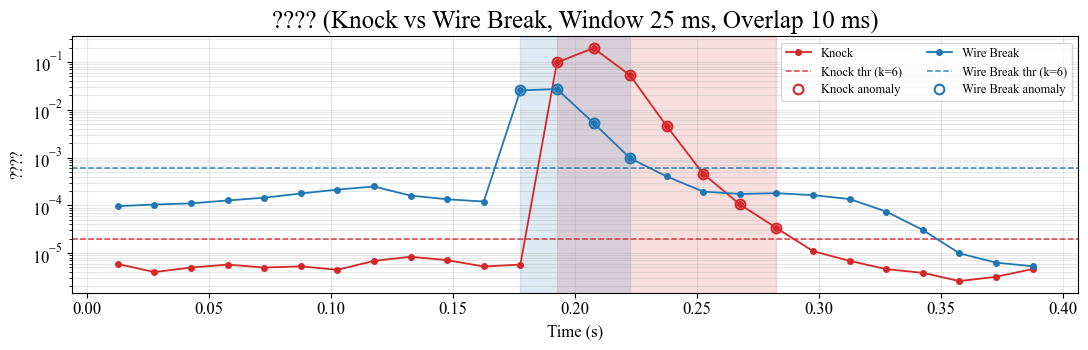

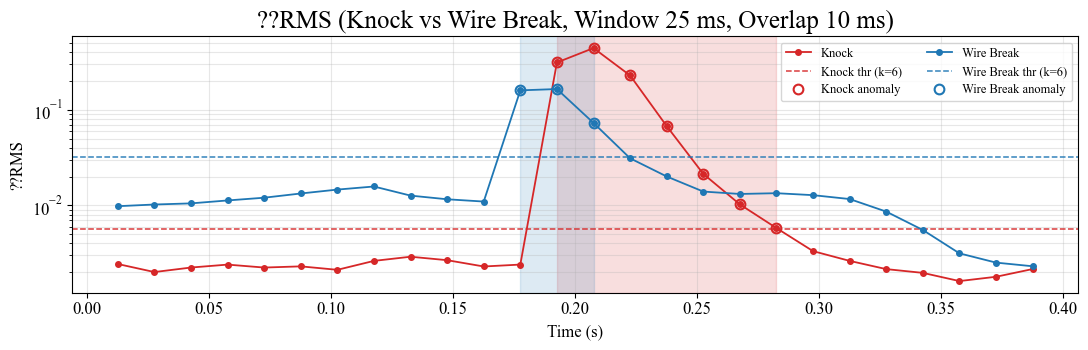

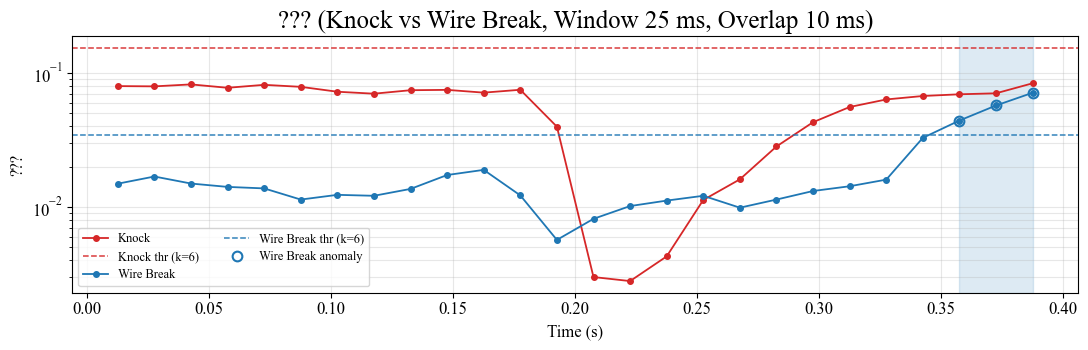

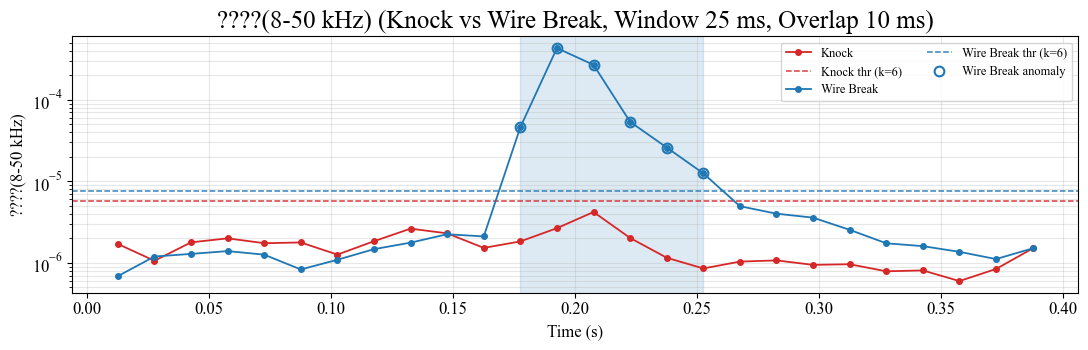

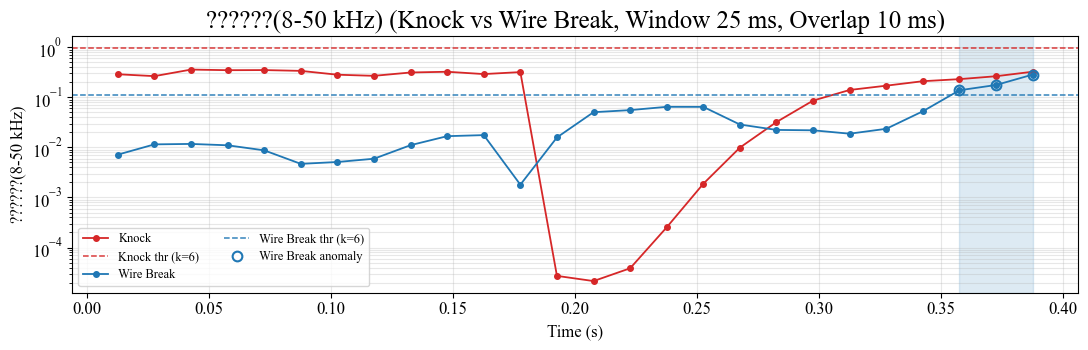

???? [Knock]: thr=2e-05, 异常帧 7/26 → 1 事件 (0.193-0.282s @0.196)
???? [Wire Break]: thr=0.000616, 异常帧 4/26 → 1 事件 (0.177-0.223s @0.0272)
??RMS [Knock]: thr=0.00559, 异常帧 7/26 → 1 事件 (0.193-0.282s @0.443)
??RMS [Wire Break]: thr=0.032, 异常帧 3/26 → 1 事件 (0.177-0.207s @0.165)
??? [Knock]: thr=0.153, 异常帧 0/26 → 0 事件 (-)
??? [Wire Break]: thr=0.0345, 异常帧 3/26 → 1 事件 (0.357-0.388s @0.0712)
????(8-50kHz) [Knock]: thr=5.8e-06, 异常帧 0/26 → 0 事件 (-)
????(8-50kHz) [Wire Break]: thr=7.56e-06, 异常帧 6/26 → 1 事件 (0.177-0.253s @0.000431)
??????(8-50kHz) [Knock]: thr=0.963, 异常帧 0/26 → 0 事件 (-)
??????(8-50kHz) [Wire Break]: thr=0.114, 异常帧 3/26 → 1 事件 (0.357-0.388s @0.284)


In [19]:
# ---------- 每特征一张图：两信号对比 + 软阈值检测（参照 2.1 节） ----------
# 跨数量级的特征用对数纵轴（按名称规则自动判定，不随频段改动失效）
LOG_FEATS = {nm for nm in FEATURES if nm != '过零率' and '占比' not in nm}
EN_LABELS = {'敲击': 'Knock (QJ00)', '断丝': 'Wire Break (BK00)',
             'QJ00': 'QJ00', 'BK00': 'BK00'}
labels = list(FILES)
CMAP = {labels[0]: 'tab:red', labels[1]: 'tab:blue'}   # 按位置配色：第1个文件红，第2个蓝

THR_K = 6      # 阈值系数 k（thr = median + k*1.4826*MAD），可调
MIN_GAP = 2    # 事件合并允许的最大间隔帧数

detect_summary = {}   # {feat_name: {label: (thr, mask, events)}}
for fnm in FEATURES:
    fig, ax = plt.subplots(figsize=(11, 3.6))
    for label in labels:
        t, v = cmp_res[label][fnm]
        # 软阈值检测（口径与 2.1 一致）
        thr = soft_threshold(v, THR_K, side='upper', method='mad')
        mask, events = detect_events(t, v, thr, MIN_GAP)
        detect_summary.setdefault(fnm, {})[label] = (thr, mask, events)
        # 特征曲线
        ax.plot(t, v, '-o', ms=4, lw=1.3, color=CMAP[label],
                label=EN_LABELS.get(label, label))
        # 阈值线（同色虚线）
        ax.axhline(thr, color=CMAP[label], ls='--', lw=1.1, alpha=0.9,
                   label=f'{EN_LABELS.get(label, label)} thr (k={THR_K:g})')
        # 异常帧（同色空心圆）
        if mask.any():
            ax.plot(t[mask], v[mask], 'o', ms=7, mfc='none', mec=CMAP[label], mew=1.5,
                    label=f'{EN_LABELS.get(label, label)} anomaly')
        # 异常事件区间（同色半透明色带）
        for ev in events:
            ax.axvspan(ev['t0'], ev['t1'], color=CMAP[label], alpha=0.15)
    if fnm in LOG_FEATS:
        ax.set_yscale('log')
        ax.grid(alpha=0.3, which='both')
    else:
        ax.grid(alpha=0.3)
    name_en = en_feat_name(fnm)
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel(name_en, fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.legend(fontsize=9, ncol=2)
    vs = ' vs '.join(EN_LABELS.get(l, l) for l in labels)
    ax.set_title(f'{name_en} ({vs}, '
                 f'Window {WIN_MS1:g} ms, Overlap {OVLP_MS1:g} ms)')
    plt.tight_layout()
    plt.show()

# 打印各特征各信号的检测结果摘要
for fnm in FEATURES:
    for label in labels:
        thr, mask, events = detect_summary[fnm][label]
        ev_str = '; '.join(f'{ev["t0"]:.3f}-{ev["t1"]:.3f}s @{ev["v_peak"]:.3g}'
                           for ev in events) or '-'
        print(f'{fnm} [{label}]: thr={thr:.3g}, 异常帧 {mask.sum()}/{len(mask)}'
              f' → {len(events)} 事件 ({ev_str})')


In [20]:
# ---------- 两信号特征数值对比 ----------
labels = list(FILES)
rows = []
for fnm in FEATURES:
    row = {'特征': fnm}
    for label in labels:
        _, v = cmp_res[label][fnm]
        row[f'{label} 均值'] = np.mean(v)
        row[f'{label} 最大'] = np.max(v)
    den = row[f'{labels[1]} 均值']
    row[f'均值比 {labels[0]}/{labels[1]}'] = row[f'{labels[0]} 均值'] / den if den != 0 else np.nan
    rows.append(row)
df_cmp = pd.DataFrame(rows)
df_cmp


,特征,Knock 均值,Knock 最大,Wire Break 均值,Wire Break 最大,均值比 Knock/Wire Break
0,????,0.013536,0.196286,0.002388,0.027229,5.669119
1,??RMS,0.043616,0.443042,0.025712,0.165012,1.696379
2,???,0.056756,0.083763,0.018839,0.071163,3.012658
3,????(8-50kHz),0.000002,0.000004,0.000034,0.000431,0.046815
4,??????(8-50kHz),0.200709,0.358393,0.043507,0.284326,4.613306


### 1.1 静水数据短时自相关模板检测

从 4.2.4 保存的本地平均自相关模板读取断丝特征，对 `E:\codes\pccp\ZZ2026\bk\0` 下 TDMS 文件进行短时自相关-模板相关检测，绘图方式与 5.1 节一致。


In [21]:
# ---------- 1.1 parameters: paths, preprocessing, and autocorr-template detection ----------
# Data folder for this subsection. Edit FILES_11 if only part of the TDMS files should be processed.
DATA_DIR_11 = Path(r'E:\codes\pccp\ZZ2026\bk\0')
FILES_11 = sorted(DATA_DIR_11.glob('*.tdms'))

# Local autocorrelation template saved by Section 4.2.4.
AC11_TEMPLATE_PATH = Path(r'E:\codes\ZZ-BK\notebooks\outputs\autocorr_template_bk15_mean.npz')

# Preprocessing parameters: zero-phase Butterworth bandpass before feature calculation.
BP11_LO = 0.5e3       # Bandpass lower cutoff (Hz)
BP11_HI = 20e3        # Bandpass upper cutoff (Hz)
BP11_ORDER = 4        # Butterworth filter order

# Short-time autocorrelation-template feature parameters.
AC11_WIN_MS = 20.0              # Sliding window length (ms); aligned with the template window length
AC11_STEP_MS = 10.0             # Sliding step (ms); smaller values give denser detection curves
AC11_CORR_LAG_MS = (1.0, 17.0)  # Absolute lag range used for Pearson correlation (ms)

# Soft-threshold event detection parameters applied to the correlation curve.
AC11_K = 6.0                    # MAD threshold multiplier; larger values are stricter
AC11_MIN_GAP = 4                # Maximum frame gap for merging adjacent detections into one event

print(f'0 m/s directory has {len(FILES_11)} TDMS files:')
for _p in FILES_11:
    print('  -', _p.name)


0 m/s directory has 3 TDMS files:
  - SemiPhase-1MHz-2026-8-20-19-4-11.tdms
  - SemiPhase-1MHz-2026-8-20-19-6-5.tdms
  - SemiPhase-1MHz-2026-8-20-19-7-5.tdms


Loaded autocorr template: E:\codes\ZZ-BK\notebooks\outputs\autocorr_template_bk15_mean.npz
SemiPhase-1MHz-2026-8-20-19-4-11.tdms: thr=0.268, events=2
SemiPhase-1MHz-2026-8-20-19-6-5.tdms: thr=0.338, events=0
SemiPhase-1MHz-2026-8-20-19-7-5.tdms: thr=0.260, events=0


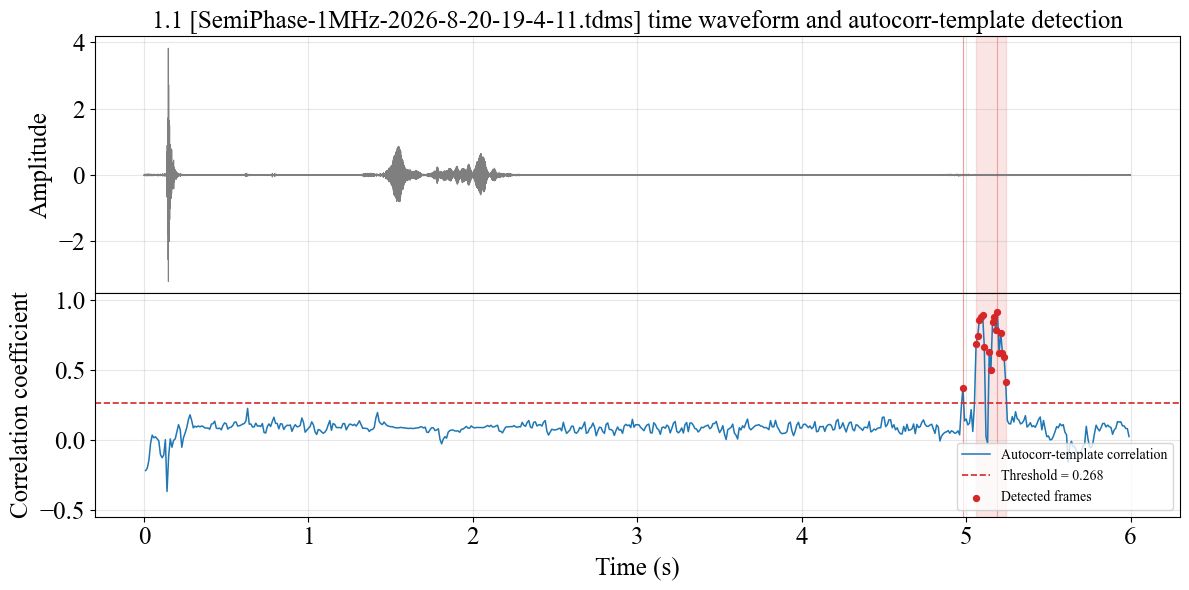

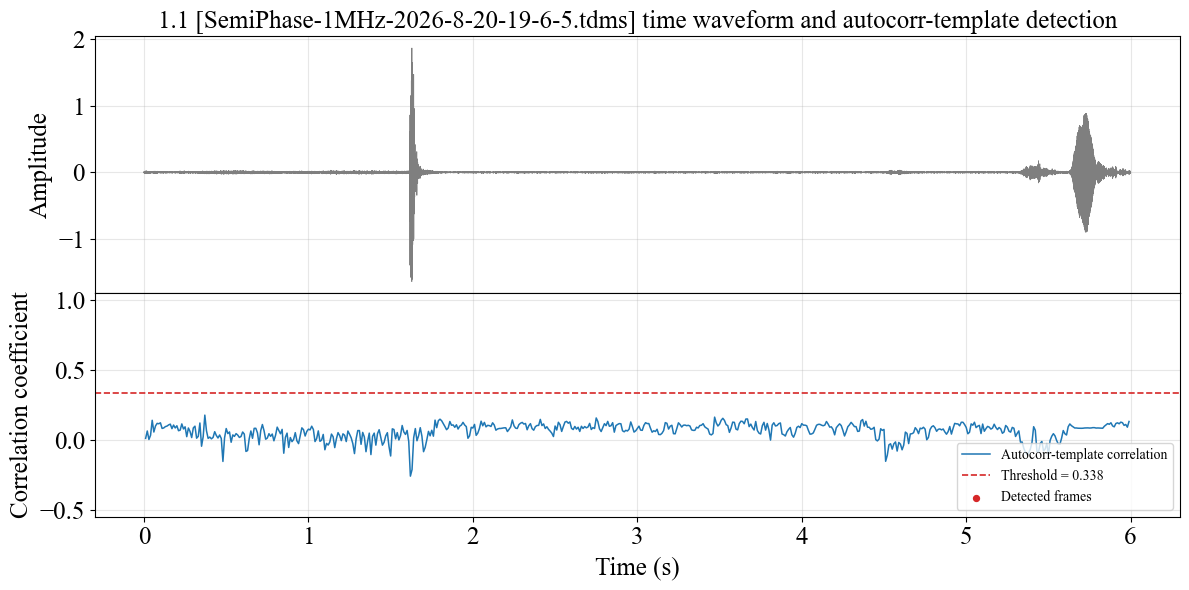

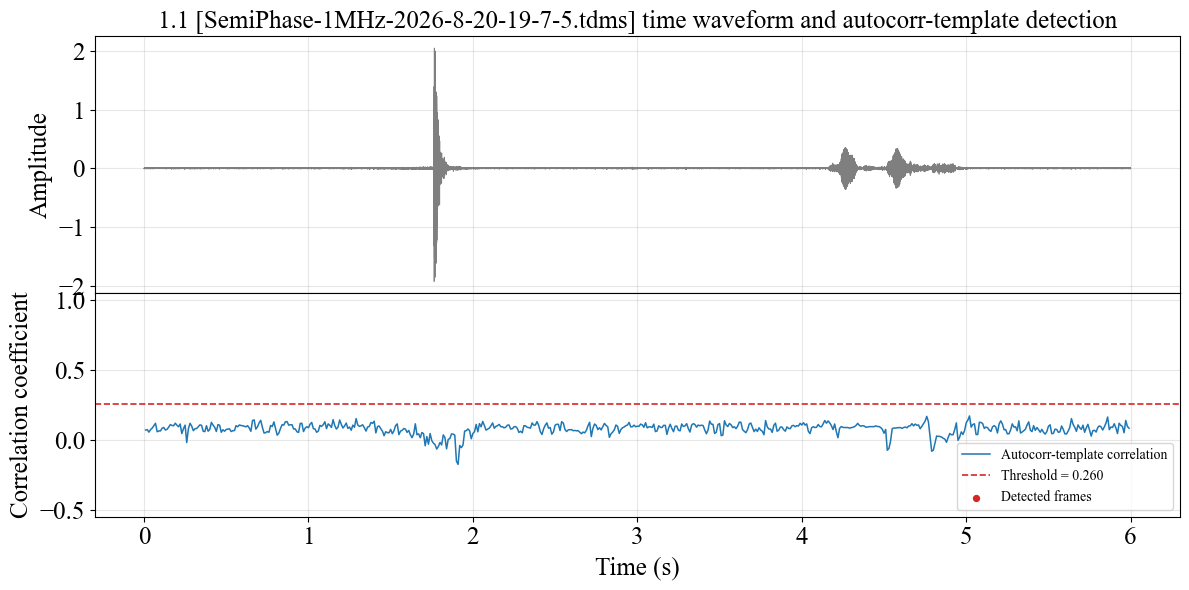

In [22]:
# ---------- 1.1 compute and plot: waveform + autocorr-template correlation ----------
ac11_results = detect_autocorr_template_files(
    FILES_11, AC11_TEMPLATE_PATH,
    win_ms=AC11_WIN_MS, step_ms=AC11_STEP_MS,
    corr_lag_ms=AC11_CORR_LAG_MS,
    threshold_k=AC11_K, min_gap_frames=AC11_MIN_GAP,
    band=(BP11_LO, BP11_HI), order=BP11_ORDER,
    channel=SEL_CH,
)
plot_autocorr_template_detection_results(ac11_results, section_label='1.1')


## 2、 0.5 m/s流速

### 2.1 短时能量

In [24]:
# ---------- 2.1 参数设置与计算：带内能量 + 软阈值检测 ----------
BAND_FILES = {
    'QJ05':  r"E:\codes\ZZ-BK\DATA09\v05-qj\QJ05-FIP-1000K-20260904T175827.793.npz",
    # 'BK05 (v05)': r"E:\codes\ZZ-BK\DATA09\v05-bk\BK05-FIP-1000K-20260904T180533.000.npz",
    # 'BK05': r"E:\codes\pccp\ZZ2026\bk\0.5\SemiPhase-1MHz-2026-8-21-11-39-1.tdms",
}

BAND_LO, BAND_HI = 1e3, 50e3   # 指定频带 (Hz)，可调

# 第 2 节滑窗参数（各节独立定义，不再使用全局统一参数）
WIN_MS21, OVLP_MS21 = 25.0, 10.0

# 第 2.1 节预处理参数（带通范围/阶数，各节独立定义、可调）
BP_LO21, BP_HI21, BP_ORDER21 = 1e3, 100e3, 4

band_res = {}   # {label: (t, band_energy)}
for label, p in BAND_FILES.items():
    # 复用第 0 节封装：加载 + 带通预处理（参数取本节 BP_LO21/BP_HI21/BP_ORDER21）
    x_pp, f_ = load_preprocessed(p, band=(BP_LO21, BP_HI21), order=BP_ORDER21,
                                 channel=SEL_CH, fs_expected=None)
    # 带内能量（时域带通法，无 FFT 泄漏）
    band_res[label] = short_time_band_feature(x_pp, f_, BAND_LO, BAND_HI, 'energy',
                                              win_ms=WIN_MS21, ovlp_ms=OVLP_MS21)
    t_, v_ = band_res[label]
    print(f'{label}: 时长 {len(x_pp)/f_:.3f} s, {len(t_)} 帧, '
          f'窗长 {WIN_MS21:g} ms / 重叠 {OVLP_MS21:g} ms, '
          f'带内能量({BAND_LO/1e3:g}-{BAND_HI/1e3:g} kHz) 峰值 {np.max(v_):.3g}')

THR_K = 20       # 阈值系数 k（thr = median + k*MAD，可调）；MAD 为稳健尺度估计，衡量数据离散程度
MIN_GAP = 2      # 事件合并允许的最大间隔帧数

detect_res = {}  # {label: (thr, mask, events)}
for label, (t_, v_) in band_res.items():
    thr = soft_threshold(v_, THR_K)
    mask, events = detect_events(t_, v_, thr, MIN_GAP)
    detect_res[label] = (thr, mask, events)
    print(f'{label}: thr={thr:.4g} (median={np.median(v_):.4g}, k={THR_K:g}), '
          f'异常帧 {mask.sum()}/{len(v_)} → {len(events)} 个事件')
    for i, ev in enumerate(events, 1):
        print(f'  事件 {i}: t={ev["t0"]:.3f}~{ev["t1"]:.3f} s, '
              f'峰值 {ev["v_peak"]:.3g} @ {ev["t_peak"]:.3f} s')


QJ05: 时长 0.400 s, 26 帧, 窗长 25 ms / 重叠 10 ms, 带内能量(1-50 kHz) 峰值 1.36e+04
QJ05: thr=88.08 (median=9.411, k=20), 异常帧 3/26 → 1 个事件
  事件 1: t=0.177~0.207 s, 峰值 1.36e+04 @ 0.193 s


对比 `QJ00`（v0-qj，0.5 m/s）与 `BK05`（v05-bk）两个信号的短时**带内能量**曲线，并用**软阈值**自动判定异常事件。

- 预处理与滑窗参数与前文一致（1~100 kHz 零相位带通，窗长 25 ms / 重叠 10 ms）
- 带内特征用时域带通法（`short_time_band_feature`），频带 `BAND_LO ~ BAND_HI` 可调（默认 5~50 kHz）；由滤波器抑制频谱泄漏，**无需对帧加窗**（技术细节见 0.2）
- 软阈值从曲线自身分布自适应估计：`thr = median + k * 1.4826 * MAD`（MAD 为中位数绝对偏差，1.4826 为高斯尺度归一化系数），对背景噪声与偶发尖峰稳健；`k` 越大阈值越严格（默认 6）
- 超过阈值的帧标记为异常帧；连续（或间隔 ≤ `min_gap_frames` 帧）的异常帧合并为一个异常事件，输出起止时间与峰值
- 也可选 `method='std'`（均值 ± k·标准差），但均值/标准差易被强异常拉偏，默认推荐 MAD


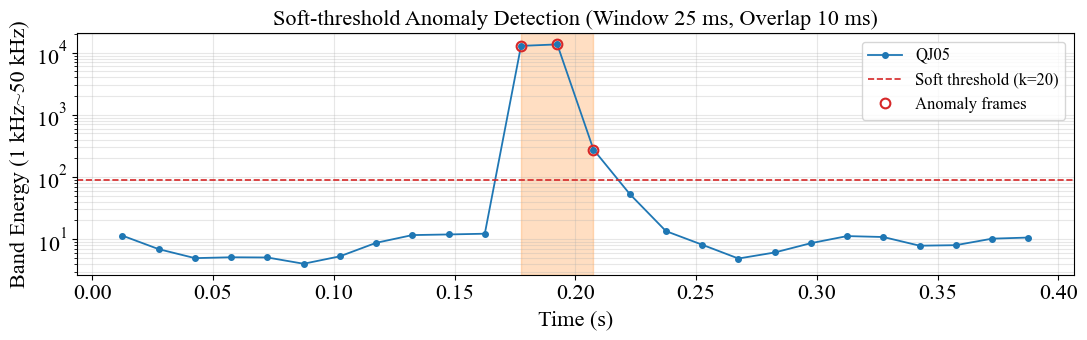

In [25]:
# ---------- 绘图：带内能量 + 软阈值/异常帧/事件标注 ----------
fig, ax = plt.subplots(figsize=(11, 3.5))
for label, (t_, v_) in band_res.items():
    thr, mask, events = detect_res[label]
    ax.plot(t_, v_, '-o', ms=4, lw=1.3, label=label)
    ax.axhline(thr, color='tab:red', ls='--', lw=1.2,
               label=f'Soft threshold (k={THR_K:g})')
    ax.plot(t_[mask], v_[mask], 'o', ms=7, mfc='none', mec='tab:red', mew=1.5,
            label='Anomaly frames')
    for ev in events:
        ax.axvspan(ev['t0'], ev['t1'], color='tab:orange', alpha=0.25)
ax.set_yscale('log')
ax.grid(alpha=0.3, which='both')
ax.set_xlabel('Time (s)', fontsize=16)
ax.set_ylabel(f'Band Energy ({BAND_LO/1e3:g} kHz~{BAND_HI/1e3:g} kHz)', fontsize=16)
ax.set_title(f'Soft-threshold Anomaly Detection '
             f'(Window {WIN_MS21:g} ms, Overlap {OVLP_MS21:g} ms)', fontsize=16)
ax.legend(fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=16)
plt.tight_layout()
plt.show()


### 2.2 小波包节点能量占比（dada / dadd）短时曲线

对比 `QJ00` 与 `BK05` 在 **1~100 kHz 带通**信号上的小波包节点能量占比（`dada`、`dadd`）短时曲线（滑窗逐帧计算），口径与 production 一致。

- 预处理：1~100 kHz 零相位带通 + WPT 前按 `target_rate = min(fs, max(4000, 3*band_hz[1]))` 降采样（300 kHz）
- 层数自适应：`ceil(log2(rate/16000))` = 5 → 32 个终端节点（每节点 4.6875 kHz）
- 节点按 pywt `order='freq'` 命名；每帧占比 = 该节点能量 / 该帧全部 32 个终端节点能量之和（float64）
- 滑窗：窗长 25 ms / 重叠 10 ms（按 300 kHz 换算）；`dada`、`dadd` 为 4 层父节点，子带按其 freq 序终端子节点并集计算

FS_WPT=300 kHz, 层数=5, 终端节点=32, 每节点 4.688 kHz
  dada: 子带 112.50-121.88 kHz
  dadd: 子带 121.88-131.25 kHz
QJ05 (v05): 26 帧, 帧时刻 0.0125~0.3875 s
BK05 (v05): 26 帧, 帧时刻 0.0125~0.3875 s


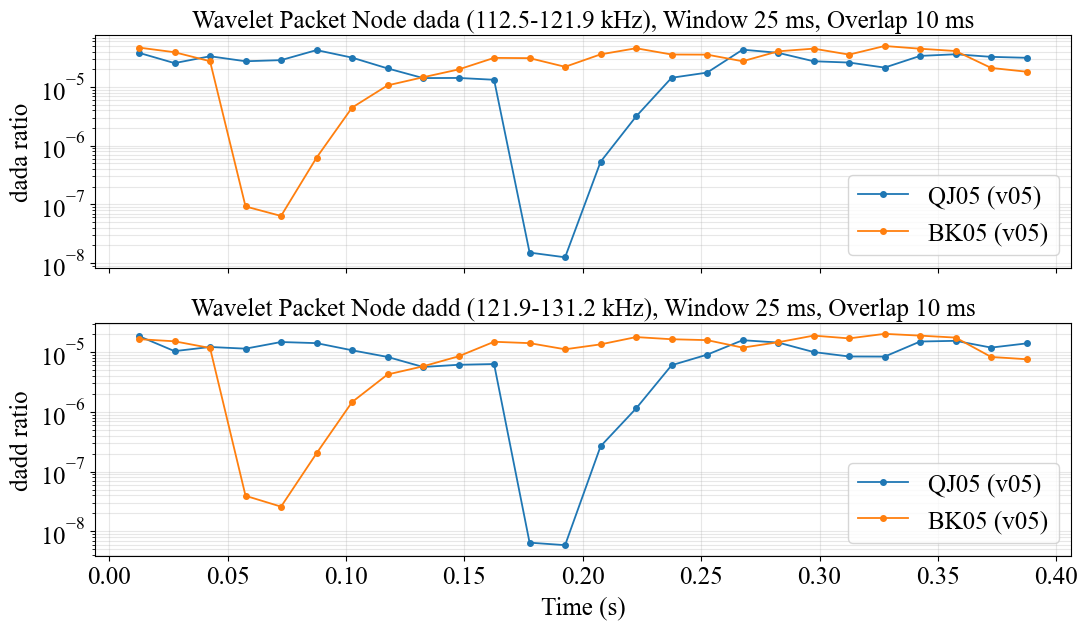

In [26]:
# ---------- 2.2 小波包节点能量占比（dada / dadd）---------
import pywt
from scipy.signal import resample_poly
from math import gcd

# 本节对比文件
BAND_FILES = {
    'QJ05 (v05)':  r"E:\codes\ZZ-BK\DATA09\v05-qj\QJ05-FIP-1000K-20260904T175827.793.npz",
    'BK05 (v05)': r"E:\codes\ZZ-BK\DATA09\v05-bk\BK05-FIP-1000K-20260904T180533.000.npz",
}

WP_WAVELET = 'db4'
BAND_LO2, BAND_HI2 = 1e3, 100e3   # 本节带通 1~100 kHz（各节独立定义、可调）
BP_ORDER22 = 4                     # 本节滤波器阶数（可调）
WP_NODES = ['dada', 'dadd']            # 待对比节点（可改）

# 口径与 production（signal_ops.py）一致：WPT 前按 target_rate 降采样
FS_REF22 = float(load_signal(next(iter(BAND_FILES.values())))['sample_rate'])
FS_WPT = min(FS_REF22, max(4000, 3.0 * BAND_HI2))      # 1-100k -> 300 kHz
WP_LEVEL = int(np.ceil(np.log2(FS_WPT / 16000.0)))  # 自适应层数 -> 5


def decimate_to(x, fs_in, fs_out):
    """将 x 从 fs_in 重采样到 fs_out"""
    g = gcd(int(round(fs_in)), int(round(fs_out)))
    return resample_poly(x, int(round(fs_out)) // g, int(round(fs_in)) // g)


# 该层数下 order='freq' 的终端节点顺序（用于子带映射，与 signal_ops.py:424 一致）
_probe = pywt.WaveletPacket(np.zeros(2 ** (WP_LEVEL + 6)), WP_WAVELET, mode='symmetric', maxlevel=WP_LEVEL)
WP_ORDER = [n.path for n in _probe.get_level(WP_LEVEL, order='freq')]
df_node = (FS_WPT / 2) / 2 ** WP_LEVEL          # 每节点带宽 (Hz)


def node_band(node):
    """节点（可为父路径，如 dada/dadd）-> 子带：按 order='freq' 终端节点并集"""
    idx = [i for i, p in enumerate(WP_ORDER) if p.startswith(node)]
    if not idx:
        raise ValueError(node)
    return min(idx) * df_node, (max(idx) + 1) * df_node


print(f'FS_WPT={FS_WPT/1e3:.0f} kHz, 层数={WP_LEVEL}, 终端节点={len(WP_ORDER)}, 每节点 {df_node/1e3:.3f} kHz')
for n in WP_NODES:
    lo, hi = node_band(n)
    print(f'  {n}: 子带 {lo/1e3:.2f}-{hi/1e3:.2f} kHz')

# 第 2.2 节滑窗参数（独立定义，不再使用全局统一参数）；按 FS_WPT 换算，复用第 0 节 frames / frame_times
WIN_MS22, OVLP_MS22 = 25.0, 10.0
win2 = int(round(WIN_MS22 * 1e-3 * FS_WPT))
hop2 = int(round((WIN_MS22 - OVLP_MS22) * 1e-3 * FS_WPT))


def frame_wp_ratios(fr, nodes=WP_NODES):
    """单帧 WPT（order='freq'）：返回 {节点: 能量占比}，分母为全部终端节点能量之和；
    父路径（如 dada/dadd）按其全部后代终端节点能量求和"""
    wp = pywt.WaveletPacket(fr, WP_WAVELET, mode='symmetric', maxlevel=WP_LEVEL)
    e = {n.path: float(np.sum(np.asarray(n.data) ** 2)) for n in wp.get_level(WP_LEVEL, order='freq')}
    tot = sum(e.values())
    return {p: sum(v for k, v in e.items() if k.startswith(p)) / tot for p in nodes}


wp_st = {}   # {label: {节点: (t, vals)}}
for label, p in BAND_FILES.items():
    # 复用第 0 节封装：加载 + 带通预处理（参数取本节 BAND_LO2/BAND_HI2/BP_ORDER22）
    x_bp, f_ = load_preprocessed(p, band=(BAND_LO2, BAND_HI2), order=BP_ORDER22,
                                 channel=SEL_CH, fs_expected=None)
    x_wp = decimate_to(x_bp, f_, FS_WPT)
    frs = frames(x_wp, win2, hop2)
    t_ = frame_times(len(x_wp), win2, hop2, FS_WPT)
    vals = {n: [] for n in WP_NODES}
    for fr in frs:
        r = frame_wp_ratios(fr)
        for n in WP_NODES:
            vals[n].append(r[n])
    wp_st[label] = {n: (t_, np.array(vals[n])) for n in WP_NODES}
    print(f'{label}: {len(t_)} 帧, 帧时刻 {t_[0]:.4f}~{t_[-1]:.4f} s')

# 绘图：每个节点一张图，两信号叠加（对数纵轴）
fig, axes = plt.subplots(len(WP_NODES), 1, figsize=(11, 3.2 * len(WP_NODES)), sharex=True)
if len(WP_NODES) == 1:
    axes = [axes]
for ax, n in zip(axes, WP_NODES):
    lo, hi = node_band(n)
    for label in wp_st:
        t_, v_ = wp_st[label][n]
        ax.plot(t_, v_, '-o', ms=4, lw=1.3, label=label)
    ax.set_yscale('log')
    ax.grid(alpha=0.3, which='both')
    ax.set_ylabel(f'{n} ratio')
    ax.legend()
    ax.set_title(f'Wavelet Packet Node {n} ({lo/1e3:.1f}-{hi/1e3:.1f} kHz), '
                 f'Window {WIN_MS22:g} ms, Overlap {OVLP_MS22:g} ms')
axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()


### 2.3 0.5 m/s 数据短时自相关模板检测

从 4.2.4 保存的本地平均自相关模板读取断丝特征，对 `E:\codes\pccp\ZZ2026\bk\0.5` 下 TDMS 文件进行短时自相关-模板相关检测，绘图方式与 5.1 节一致。


In [27]:
# ---------- 2.3 parameters: paths, preprocessing, and autocorr-template detection ----------
# Data folder for this subsection. Edit FILES_23 if only part of the TDMS files should be processed.
DATA_DIR_23 = Path(r'E:\codes\pccp\ZZ2026\bk\0.5')
FILES_23 = sorted(DATA_DIR_23.glob('*.tdms'))

# Local autocorrelation template saved by Section 4.2.4.
AC23_TEMPLATE_PATH = Path(r'E:\codes\ZZ-BK\notebooks\outputs\autocorr_template_bk15_mean.npz')

# Preprocessing parameters: zero-phase Butterworth bandpass before feature calculation.
BP23_LO = 0.5e3       # Bandpass lower cutoff (Hz)
BP23_HI = 20e3        # Bandpass upper cutoff (Hz)
BP23_ORDER = 4        # Butterworth filter order

# Short-time autocorrelation-template feature parameters.
AC23_WIN_MS = 20.0              # Sliding window length (ms); aligned with the template window length
AC23_STEP_MS = 10.0             # Sliding step (ms); smaller values give denser detection curves
AC23_CORR_LAG_MS = (1.0, 17.0)  # Absolute lag range used for Pearson correlation (ms)

# Soft-threshold event detection parameters applied to the correlation curve.
AC23_K = 6.0                    # MAD threshold multiplier; larger values are stricter
AC23_MIN_GAP = 4                # Maximum frame gap for merging adjacent detections into one event

print(f'0.5 m/s directory has {len(FILES_23)} TDMS files:')
for _p in FILES_23:
    print('  -', _p.name)


0.5 m/s directory has 6 TDMS files:
  - SemiPhase-1MHz-2026-8-21-11-37-37.tdms
  - SemiPhase-1MHz-2026-8-21-11-38-7.tdms
  - SemiPhase-1MHz-2026-8-21-11-39-1.tdms
  - SemiPhase-1MHz-2026-8-21-11-40-19.tdms
  - SemiPhase-1MHz-2026-8-21-11-44-23.tdms
  - SemiPhase-1MHz-2026-8-21-11-44-59.tdms


Loaded autocorr template: E:\codes\ZZ-BK\notebooks\outputs\autocorr_template_bk15_mean.npz
SemiPhase-1MHz-2026-8-21-11-37-37.tdms: thr=0.458, events=4
SemiPhase-1MHz-2026-8-21-11-38-7.tdms: thr=0.604, events=0
SemiPhase-1MHz-2026-8-21-11-39-1.tdms: thr=0.710, events=0
SemiPhase-1MHz-2026-8-21-11-40-19.tdms: thr=0.679, events=1
SemiPhase-1MHz-2026-8-21-11-44-23.tdms: thr=0.616, events=1
SemiPhase-1MHz-2026-8-21-11-44-59.tdms: thr=0.690, events=1


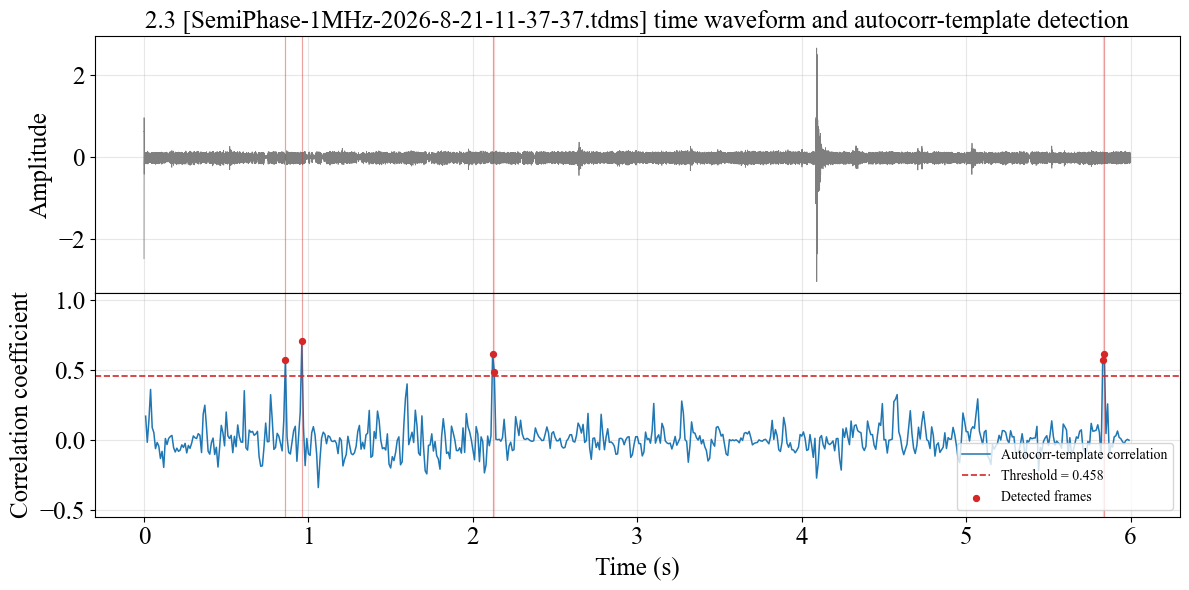

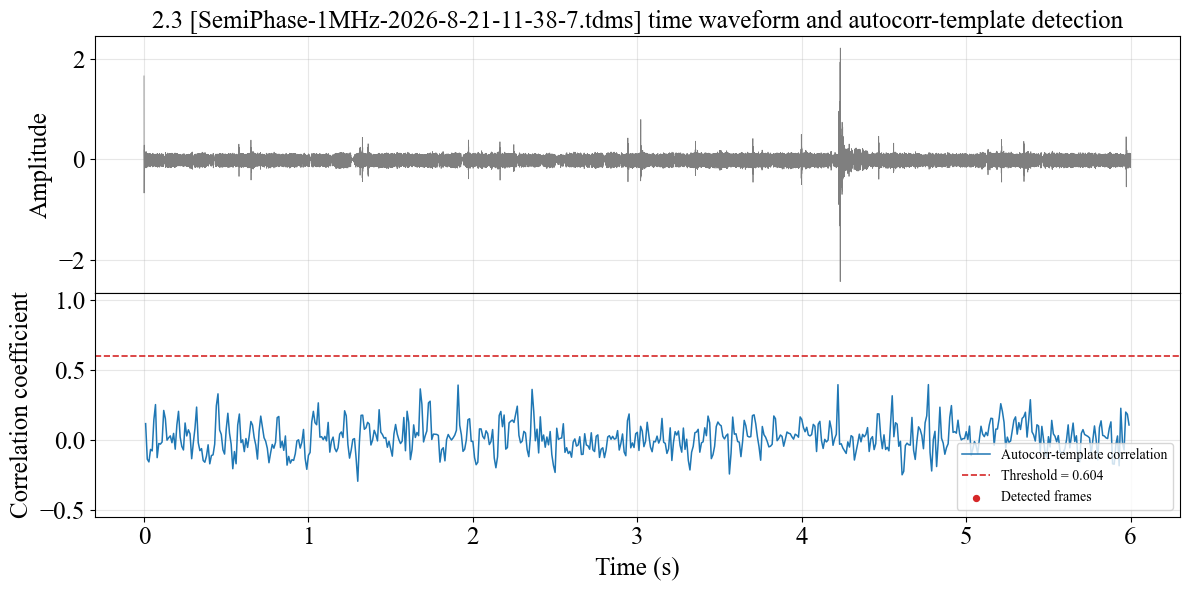

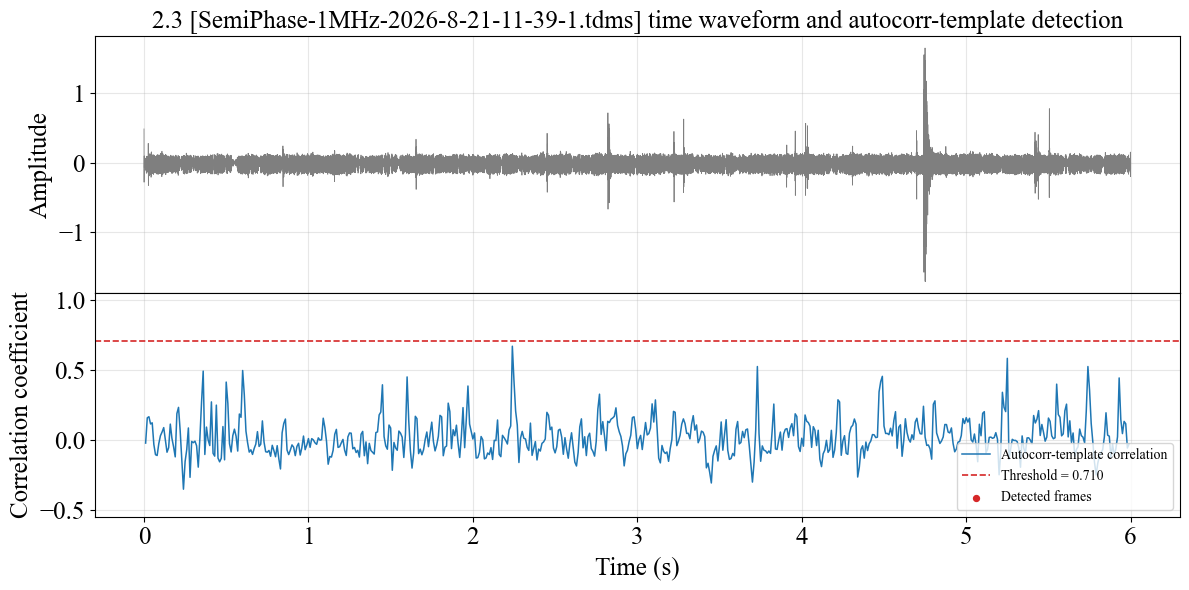

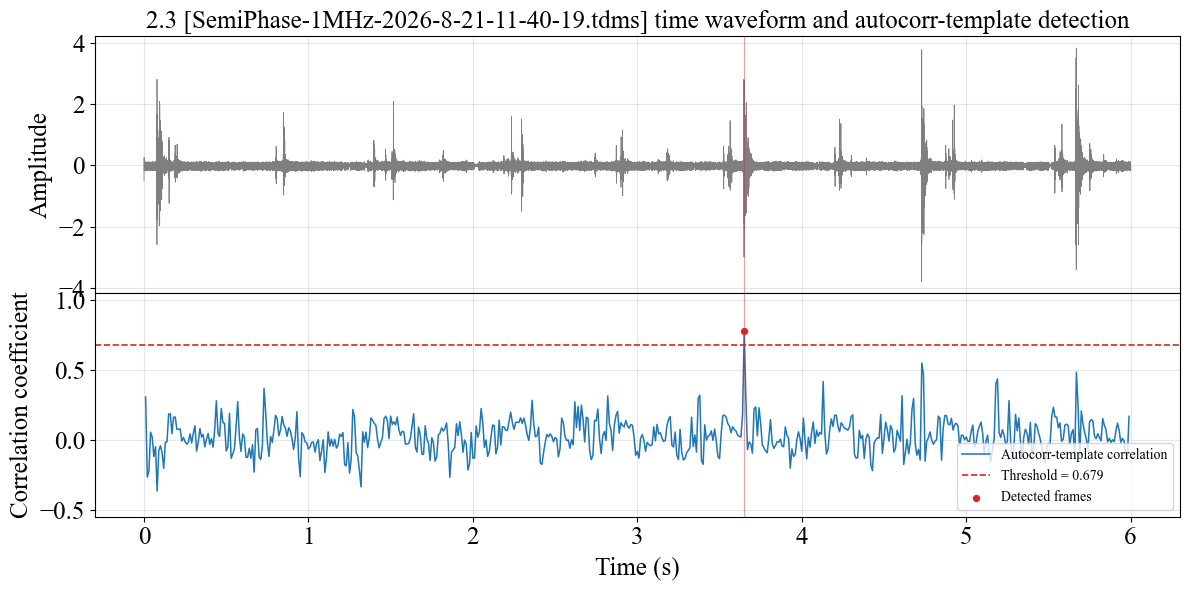

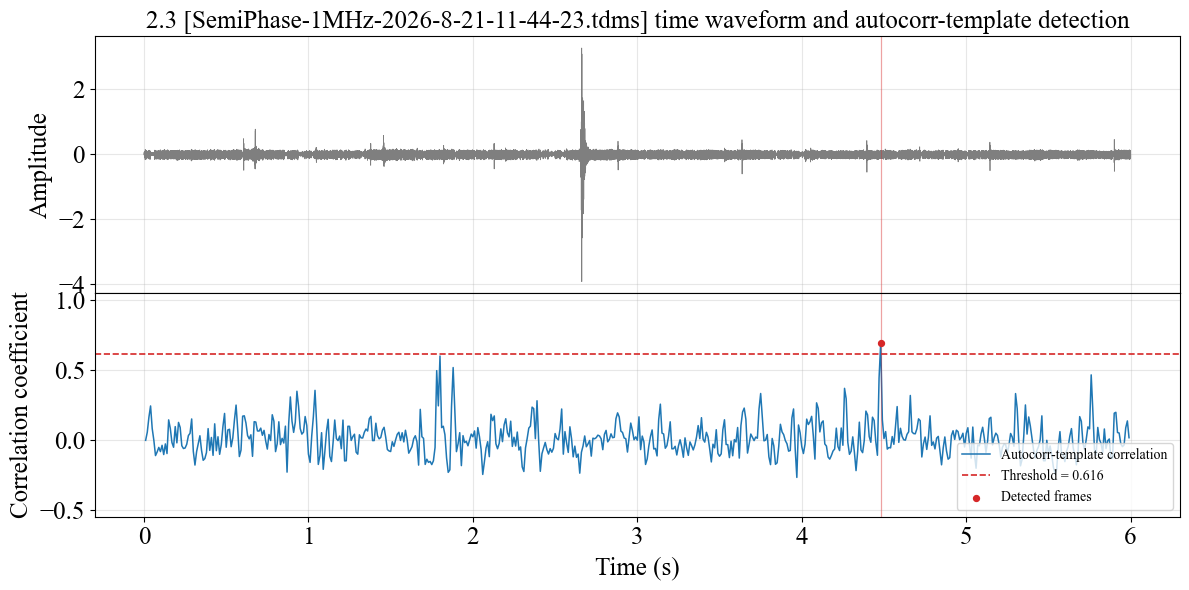

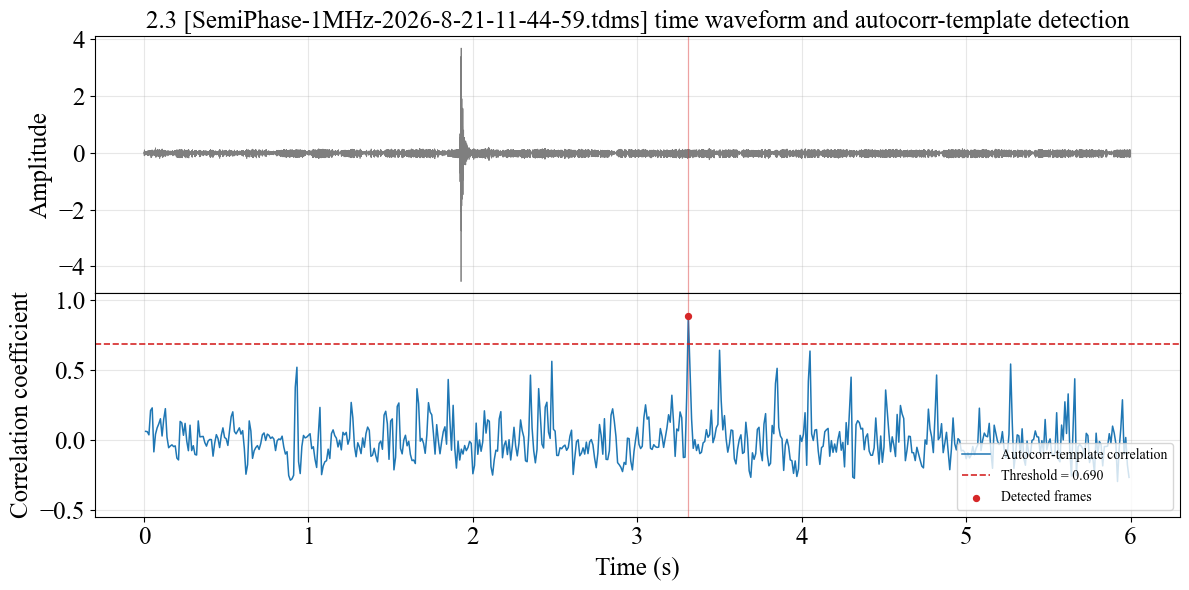

In [28]:
# ---------- 2.3 compute and plot: waveform + autocorr-template correlation ----------
ac23_results = detect_autocorr_template_files(
    FILES_23, AC23_TEMPLATE_PATH,
    win_ms=AC23_WIN_MS, step_ms=AC23_STEP_MS,
    corr_lag_ms=AC23_CORR_LAG_MS,
    threshold_k=AC23_K, min_gap_frames=AC23_MIN_GAP,
    band=(BP23_LO, BP23_HI), order=BP23_ORDER,
    channel=SEL_CH,
)
plot_autocorr_template_detection_results(ac23_results, section_label='2.3')


## 3、1.0 m/s 流速

## 3.1 短时能量

In [28]:
# ---------- 3.1 参数设置与计算：带内能量 + 软阈值检测（参照 2.1 节） ----------
DATA_DIR_10 = Path(r'E:\codes\pccp\ZZ2026\bk\1.0')
_tdms = sorted(DATA_DIR_10.glob('*.tdms'))[:1]
BAND_FILES3 = {f'BK10-{i + 1}': str(p) for i, p in enumerate(_tdms)}
print(f'1.0 m/s 共 {len(BAND_FILES3)} 个文件:', ', '.join(BAND_FILES3))

BAND_LO3, BAND_HI3 = 2e3, 20e3   # 指定频带 (Hz)，可调

# 第 3 节滑窗参数（各节独立定义，不再使用全局统一参数）
WIN_MS3, OVLP_MS3 = 25.0, 10.0

# 第 3 节预处理参数（带通范围/阶数，各节独立定义、可调）
BP_LO3, BP_HI3, BP_ORDER3 = 1e3, 100e3, 4

THR_K3 = 10       # 阈值系数 k（thr = median + k*1.4826*MAD，可调）
MIN_GAP3 = 2      # 事件合并允许的最大间隔帧数

band_res3, detect_res3 = {}, {}   # {label: (t, band_energy)} / {label: (thr, mask, events)}
for label, p in BAND_FILES3.items():
    # 复用第 0 节封装：加载 + 带通预处理（参数取本节 BP_LO3/BP_HI3/BP_ORDER3）
    x_pp, f_ = load_preprocessed(p, band=(BP_LO3, BP_HI3), order=BP_ORDER3,
                                 channel=SEL_CH, fs_expected=None)
    # 带内能量（时域带通法，无 FFT 泄漏）
    band_res3[label] = short_time_band_feature(x_pp, f_, BAND_LO3, BAND_HI3, 'energy',
                                               win_ms=WIN_MS3, ovlp_ms=OVLP_MS3)
    t_, v_ = band_res3[label]
    # 软阈值检测（公式见 0.3 节）
    thr = soft_threshold(v_, THR_K3)
    mask, events = detect_events(t_, v_, thr, MIN_GAP3)
    detect_res3[label] = (thr, mask, events)
    print(f'{label} ({Path(p).stem}): 时长 {len(x_pp)/f_:.3f} s, {len(t_)} 帧, '
          f'窗长 {WIN_MS3:g} ms / 重叠 {OVLP_MS3:g} ms, '
          f'带内能量({BAND_LO3/1e3:g}-{BAND_HI3/1e3:g} kHz) 峰值 {np.max(v_):.3g}')
    print(f'  thr={thr:.4g} (median={np.median(v_):.4g}, k={THR_K3:g}), '
          f'异常帧 {mask.sum()}/{len(v_)} → {len(events)} 个事件')
    for i, ev in enumerate(events, 1):
        print(f'  事件 {i}: t={ev["t0"]:.3f}~{ev["t1"]:.3f} s, '
              f'峰值 {ev["v_peak"]:.3g} @ {ev["t_peak"]:.3f} s')


1.0 m/s 共 1 个文件: BK10-1
BK10-1 (SemiPhase-1MHz-2026-8-21-14-25-36): 时长 6.000 s, 399 帧, 窗长 25 ms / 重叠 10 ms, 带内能量(2-20 kHz) 峰值 395
  thr=330.2 (median=62.73, k=10), 异常帧 2/399 → 1 个事件
  事件 1: t=2.817~2.833 s, 峰值 395 @ 2.833 s


对 `E:\codes\pccp\ZZ2026\bk\1.0` 中的全部 TDMS 文件（1.0 m/s 断丝）计算短时**带内能量**曲线，并用**软阈值**自动判定异常事件。

- 预处理与滑窗参数与前文一致（1~100 kHz 零相位带通，窗长 25 ms / 重叠 10 ms），仅通道 1
- 带内特征用时域带通法（`short_time_band_feature`），频带 1~50 kHz（与 2.1 一致）；由滤波器抑制频谱泄漏，**无需对帧加窗**（技术细节见 0.2）
- 软阈值从曲线自身分布自适应估计：`thr = median + k * 1.4826 * MAD`（MAD 为中位数绝对偏差），对背景噪声与偶发尖峰稳健；`k` 越大阈值越严格（此处取 20，与 2.1 一致）
- 超过阈值的帧标记为异常帧；连续（或间隔 ≤ `min_gap_frames` 帧）的异常帧合并为一个异常事件，输出起止时间与峰值
- 也可选 `method='std'`（均值 ± k·标准差），但均值/标准差易被强异常拉偏，默认推荐 MAD

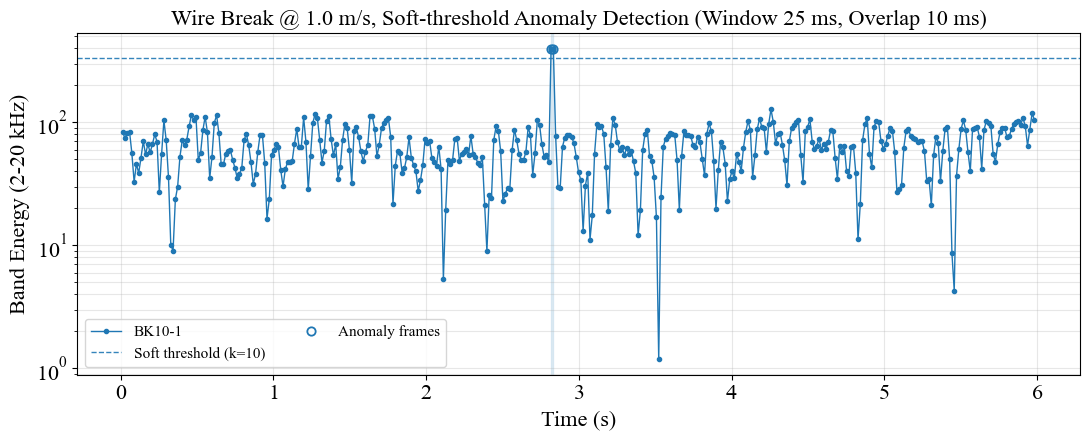

In [29]:
# ---------- 绘图：带内能量 + 软阈值/异常帧/事件标注（参照 2.1 节） ----------
fig, ax = plt.subplots(figsize=(11, 4.5))
cyc = plt.rcParams['axes.prop_cycle'].by_key()['color']
CMAP3 = {label: cyc[i % len(cyc)] for i, label in enumerate(band_res3)}
_first = next(iter(band_res3))
for label, (t_, v_) in band_res3.items():
    thr, mask, events = detect_res3[label]
    c = CMAP3[label]
    ax.plot(t_, v_, '-o', ms=3, lw=1.0, color=c, label=label)
    ax.axhline(thr, color=c, ls='--', lw=1.0, alpha=0.9,
               label=f'Soft threshold (k={THR_K3:g})' if label == _first else None)
    ax.plot(t_[mask], v_[mask], 'o', ms=6, mfc='none', mec=c, mew=1.3,
            label='Anomaly frames' if label == _first else None)
    for ev in events:
        ax.axvspan(ev['t0'], ev['t1'], color=c, alpha=0.12)
ax.set_yscale('log')
ax.grid(alpha=0.3, which='both')
ax.set_xlabel('Time (s)', fontsize=16)
ax.set_ylabel(f'Band Energy ({BAND_LO3/1e3:g}-{BAND_HI3/1e3:g} kHz)', fontsize=16)
ax.set_title(f'Wire Break @ 1.0 m/s, Soft-threshold Anomaly Detection '
             f'(Window {WIN_MS3:g} ms, Overlap {OVLP_MS3:g} ms)', fontsize=16)
ax.legend(fontsize=11, ncol=2)
ax.tick_params(axis='both', which='major', labelsize=16)
plt.tight_layout()
plt.show()


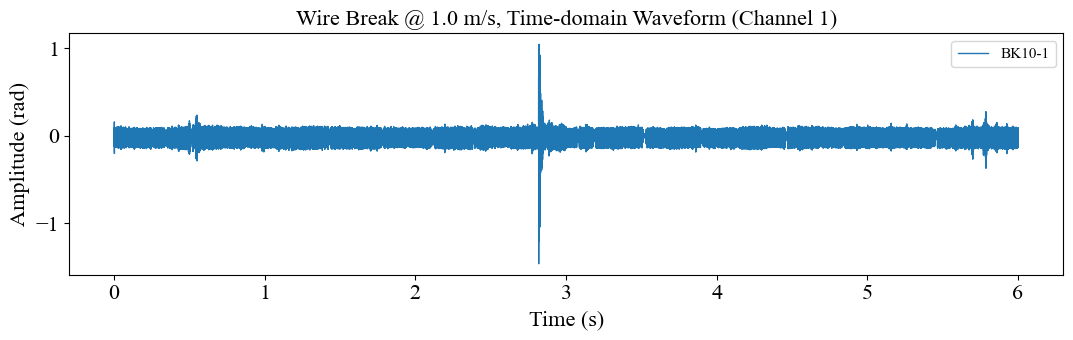

In [41]:
# 绘制时域图（仅通道 1）
fig, ax = plt.subplots(figsize=(11, 3.5))
for label, p in BAND_FILES3.items():
    dd = load_signal(p)
    x = dd['phase_data'][:, SEL_CH]
    # 滤波
    x = preprocess_bandpass(x, float(dd['sample_rate']), (BP_LO3, BP_HI3), BP_ORDER3)
    x[:1000]=0.0  # 避免开头滤波瞬态过大
    f_ = float(dd['sample_rate'])
    t_ = np.arange(len(x)) / f_
    ax.plot(t_, x, lw=1.0, label=label)
ax.set_xlabel('Time (s)', fontsize=16)
ax.set_ylabel('Amplitude (rad)', fontsize=16)
ax.set_title('Wire Break @ 1.0 m/s, Time-domain Waveform (Channel 1)', fontsize=16)
ax.legend(fontsize=11)
ax.tick_params(axis='both', which='major', labelsize=16)
plt.tight_layout()
plt.show()


## 3.2 1.0 m/s 数据短时自相关模板检测

从 4.2.4 保存的本地平均自相关模板读取断丝特征，对 `E:\codes\pccp\ZZ2026\bk\1.0` 下 TDMS 文件进行短时自相关-模板相关检测，绘图方式与 5.1 节一致。


In [44]:
# ---------- 3.2 parameters: paths, preprocessing, and autocorr-template detection ----------
# Data folder for this subsection. Edit FILES_32 if only part of the TDMS files should be processed.
DATA_DIR_32 = Path(r'E:\codes\pccp\ZZ2026\bk\1.0')
FILES_32 = sorted(DATA_DIR_32.glob('*.tdms'))

# Local autocorrelation template saved by Section 4.2.4.
AC32_TEMPLATE_PATH = Path(r'E:\codes\ZZ-BK\notebooks\outputs\autocorr_template_bk15_mean.npz')

# Preprocessing parameters: zero-phase Butterworth bandpass before feature calculation.
BP32_LO = 2e3       # Bandpass lower cutoff (Hz)
BP32_HI = 20e3        # Bandpass upper cutoff (Hz)
BP32_ORDER = 4        # Butterworth filter order

# Short-time autocorrelation-template feature parameters.
AC32_WIN_MS = 20.0              # Sliding window length (ms); aligned with the template window length
AC32_STEP_MS = 10.0             # Sliding step (ms); smaller values give denser detection curves
AC32_CORR_LAG_MS = (1.0, 17.0)  # Absolute lag range used for Pearson correlation (ms)

# Soft-threshold event detection parameters applied to the correlation curve.
AC32_K = 6.0                    # MAD threshold multiplier; larger values are stricter
AC32_MIN_GAP = 4                # Maximum frame gap for merging adjacent detections into one event

print(f'1.0 m/s directory has {len(FILES_32)} TDMS files:')
for _p in FILES_32:
    print('  -', _p.name)


1.0 m/s directory has 5 TDMS files:
  - SemiPhase-1MHz-2026-8-21-14-25-36.tdms
  - SemiPhase-1MHz-2026-8-21-14-26-12.tdms
  - SemiPhase-1MHz-2026-8-21-14-27-12.tdms
  - SemiPhase-1MHz-2026-8-21-14-27-54.tdms
  - SemiPhase-1MHz-2026-8-21-14-28-48.tdms


Loaded autocorr template: E:\codes\ZZ-BK\notebooks\outputs\autocorr_template_bk15_mean.npz
SemiPhase-1MHz-2026-8-21-14-25-36.tdms: thr=0.058, events=2
SemiPhase-1MHz-2026-8-21-14-26-12.tdms: thr=0.029, events=2
SemiPhase-1MHz-2026-8-21-14-27-12.tdms: thr=0.039, events=2
SemiPhase-1MHz-2026-8-21-14-27-54.tdms: thr=0.033, events=2
SemiPhase-1MHz-2026-8-21-14-28-48.tdms: thr=0.025, events=2


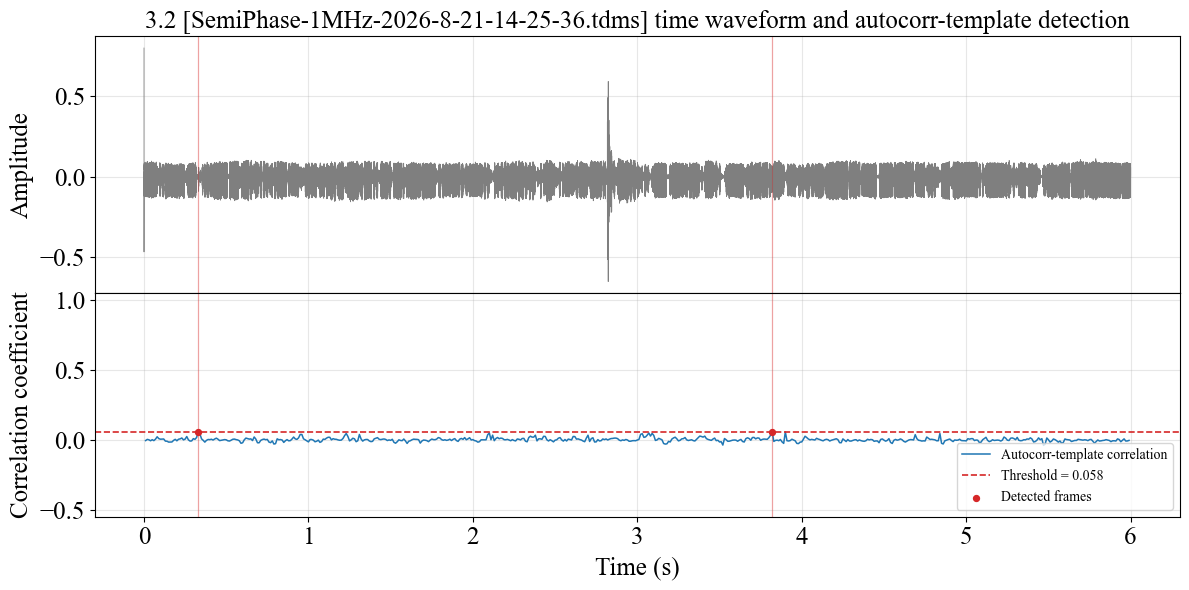

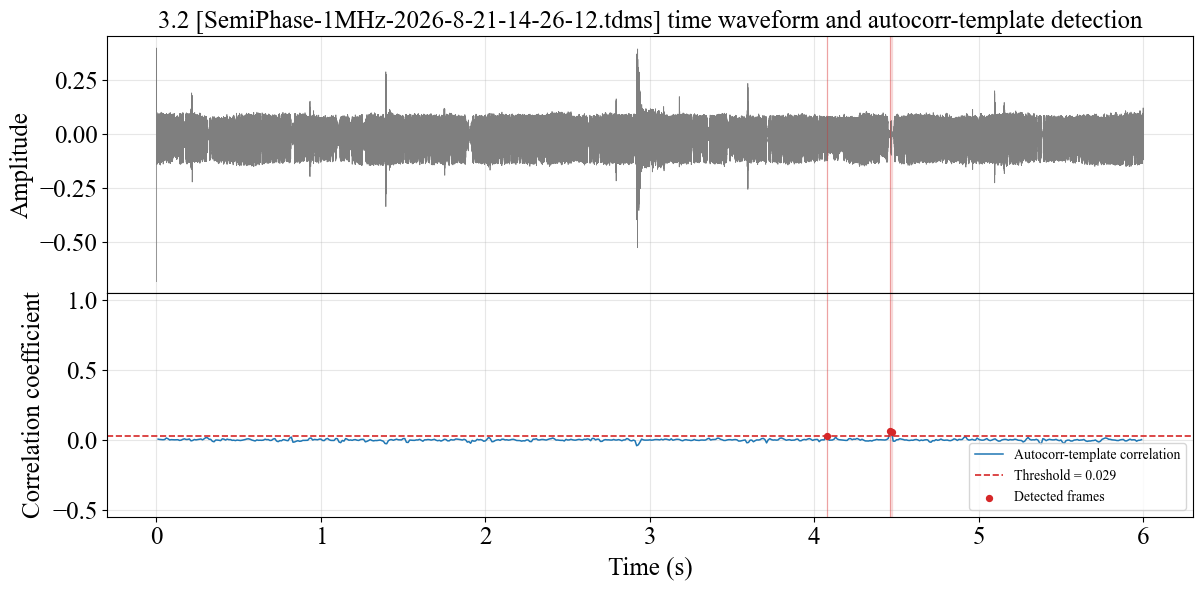

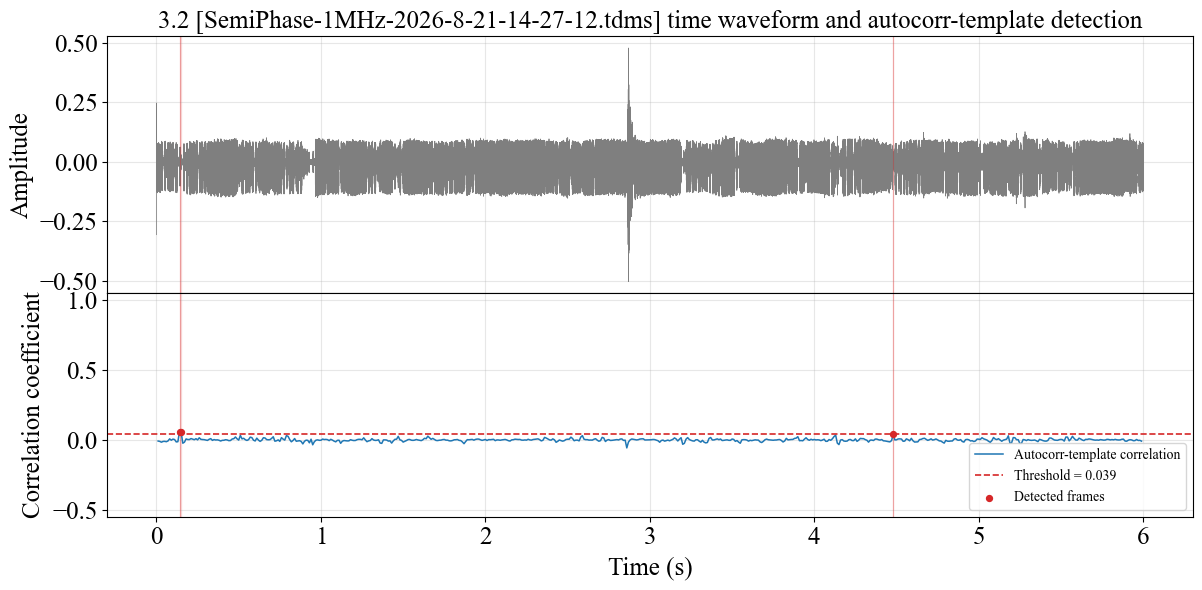

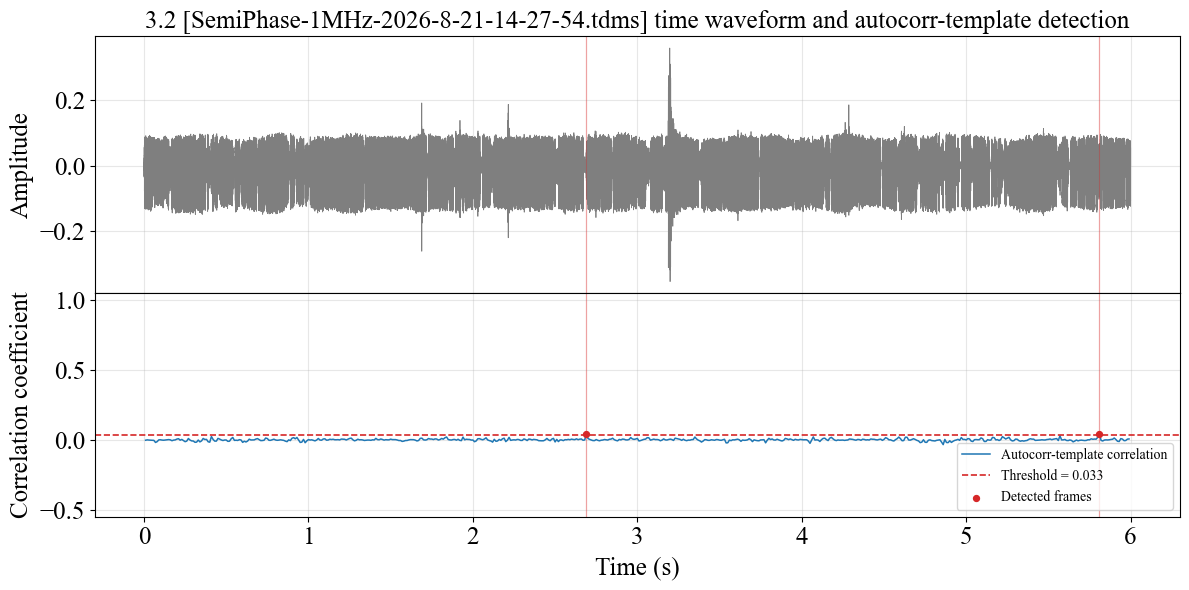

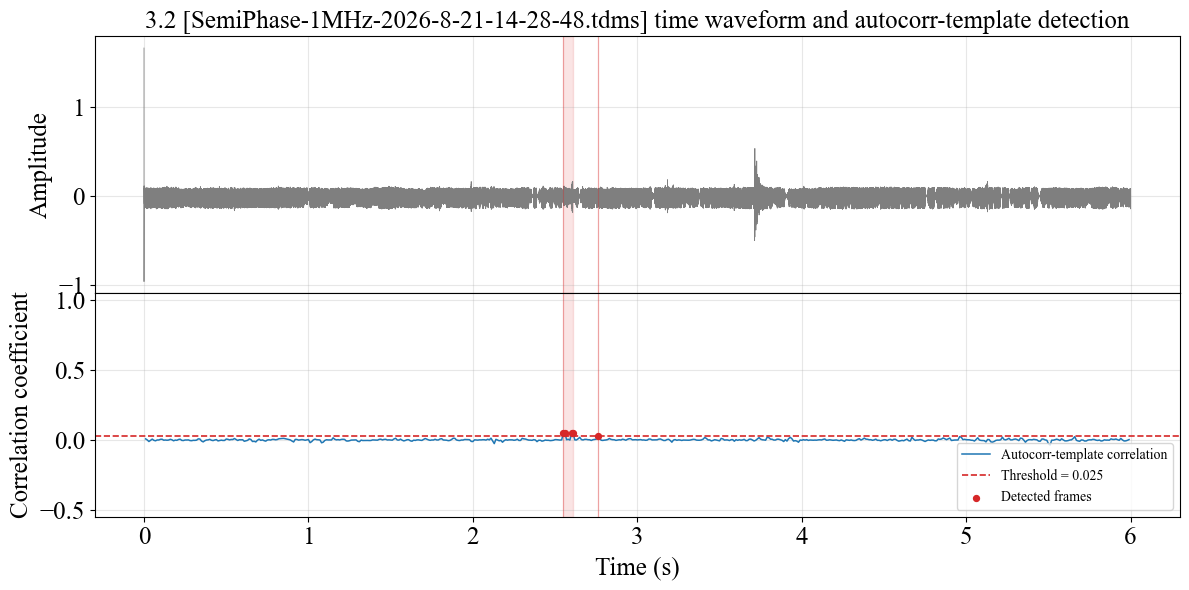

In [26]:
# ---------- 3.2 compute and plot: waveform + autocorr-template correlation ----------
ac32_results = detect_autocorr_template_files(
    FILES_32, AC32_TEMPLATE_PATH,
    win_ms=AC32_WIN_MS, step_ms=AC32_STEP_MS,
    corr_lag_ms=AC32_CORR_LAG_MS,
    threshold_k=AC32_K, min_gap_frames=AC32_MIN_GAP,
    band=(BP32_LO, BP32_HI), order=BP32_ORDER,
    channel=SEL_CH,
)
plot_autocorr_template_detection_results(ac32_results, section_label='3.2')


## 4、 1.5 m/s流速

In [48]:
%matplotlib qt

### 4.1、 短时能量

In [42]:
# ---------- 4.1 参数设置与计算：带内能量 + 软阈值检测（参照第 3 节） ----------
DATA_DIR_15 = Path(r'E:\codes\pccp\ZZ2026\bk\1.5')
_tdms15 = sorted(DATA_DIR_15.glob('*.tdms'))[:1]
BAND_FILES4 = {f'BK15-{i + 1}': str(p) for i, p in enumerate(_tdms15)}
print(f'1.5 m/s 共 {len(BAND_FILES4)} 个文件:', ', '.join(BAND_FILES4))

BAND_LO4, BAND_HI4 = 1e3, 20e3   # 指定频带 (Hz)，与第 3 节一致，可调

# 第 4 节滑窗参数（各节独立定义，不再使用全局统一参数）
WIN_MS4, OVLP_MS4 = 20.0, 5.0

# 第 4 节预处理参数（带通范围/阶数，各节独立定义、可调）
BP_LO4, BP_HI4, BP_ORDER4 = 1e3, 100e3, 4

THR_K4 = 8       # 阈值系数 k（thr = median + k*1.4826*MAD，可调）
MIN_GAP4 = 2      # 事件合并允许的最大间隔帧数

band_res4, detect_res4 = {}, {}   # {label: (t, band_energy)} / {label: (thr, mask, events)}
for label, p in BAND_FILES4.items():
    # 复用第 0 节封装：加载 + 带通预处理（参数取本节 BP_LO4/BP_HI4/BP_ORDER4）
    x_pp, f_ = load_preprocessed(p, band=(BP_LO4, BP_HI4), order=BP_ORDER4,
                                 channel=SEL_CH, fs_expected=None)
    # 带内能量（时域带通法，无 FFT 泄漏）
    band_res4[label] = short_time_band_feature(x_pp, f_, BAND_LO4, BAND_HI4, 'energy',
                                               win_ms=WIN_MS4, ovlp_ms=OVLP_MS4)
    t_, v_ = band_res4[label]
    # 软阈值检测（公式见 0.3 节）
    thr = soft_threshold(v_, THR_K4)
    mask, events = detect_events(t_, v_, thr, MIN_GAP4)
    detect_res4[label] = (thr, mask, events)
    print(f'{label} ({Path(p).stem}): 时长 {len(x_pp)/f_:.3f} s, {len(t_)} 帧, '
          f'窗长 {WIN_MS4:g} ms / 重叠 {OVLP_MS4:g} ms, '
          f'带内能量({BAND_LO4/1e3:g}-{BAND_HI4/1e3:g} kHz) 峰值 {np.max(v_):.3g}')
    print(f'  thr={thr:.4g} (median={np.median(v_):.4g}, k={THR_K4:g}), '
          f'异常帧 {mask.sum()}/{len(v_)} → {len(events)} 个事件')
    for i, ev in enumerate(events, 1):
        print(f'  事件 {i}: t={ev["t0"]:.3f}~{ev["t1"]:.3f} s, '
              f'峰值 {ev["v_peak"]:.3g} @ {ev["t_peak"]:.3f} s')


1.5 m/s 共 1 个文件: BK15-1
BK15-1 (SemiPhase-1MHz-2026-8-21-16-27-44): 时长 6.000 s, 399 帧, 窗长 20 ms / 重叠 5 ms, 带内能量(1-20 kHz) 峰值 7.02e+03
  thr=221.9 (median=75.28, k=8), 异常帧 36/399 → 17 个事件
  事件 1: t=0.190~0.205 s, 峰值 342 @ 0.205 s
  事件 2: t=0.580~0.595 s, 峰值 1.39e+03 @ 0.580 s
  事件 3: t=0.895~0.910 s, 峰值 7.02e+03 @ 0.895 s
  事件 4: t=0.985~0.985 s, 峰值 311 @ 0.985 s
  事件 5: t=1.210~1.240 s, 峰值 3.14e+03 @ 1.210 s
  事件 6: t=1.630~1.630 s, 峰值 263 @ 1.630 s
  事件 7: t=1.975~1.990 s, 峰值 1.7e+03 @ 1.975 s
  事件 8: t=2.305~2.320 s, 峰值 798 @ 2.305 s
  事件 9: t=2.725~2.740 s, 峰值 907 @ 2.725 s
  事件 10: t=2.935~3.010 s, 峰值 2.74e+03 @ 2.935 s
  事件 11: t=3.220~3.265 s, 峰值 1.47e+03 @ 3.250 s
  事件 12: t=3.775~3.820 s, 峰值 466 @ 3.775 s
  事件 13: t=3.910~3.955 s, 峰值 1.54e+03 @ 3.955 s
  事件 14: t=4.090~4.105 s, 峰值 712 @ 4.105 s
  事件 15: t=4.210~4.210 s, 峰值 4.19e+03 @ 4.210 s
  事件 16: t=4.435~4.435 s, 峰值 657 @ 4.435 s
  事件 17: t=5.590~5.605 s, 峰值 314 @ 5.590 s


对 `E:\codes\pccp\ZZ2026\bk\1.5` 中的全部 TDMS 文件（1.5 m/s 断丝）计算短时**带内能量**曲线，并用**软阈值**自动判定异常事件（参照第 3 节）。

- 预处理与滑窗参数与第 3 节一致（1~100 kHz 零相位带通、4 阶，窗长 25 ms / 重叠 10 ms），仅通道 1；参数均在本节独立定义、可调
- 带内特征用时域带通法（`short_time_band_feature`），频带 2~20 kHz（与第 3 节一致）；由滤波器抑制频谱泄漏，**无需对帧加窗**（技术细节见 0.2）
- 软阈值从曲线自身分布自适应估计：`thr = median + k * 1.4826 * MAD`（MAD 为中位数绝对偏差），对背景噪声与偶发尖峰稳健；`k` 越大阈值越严格（此处取 20，与第 3 节一致）
- 超过阈值的帧标记为异常帧；连续（或间隔 ≤ `min_gap_frames` 帧）的异常帧合并为一个异常事件，输出起止时间与峰值
- 也可选 `method='std'`（均值 ± k·标准差），但均值/标准差易被强异常拉偏，默认推荐 MAD


In [56]:
# ---------- 绘图：带内能量 + 软阈值/异常帧/事件标注（参照第 3 节） ----------
fig, ax = plt.subplots(figsize=(11, 4.5))
cyc = plt.rcParams['axes.prop_cycle'].by_key()['color']
CMAP4 = {label: cyc[i % len(cyc)] for i, label in enumerate(band_res4)}
_first4 = next(iter(band_res4))
for label, (t_, v_) in band_res4.items():
    thr, mask, events = detect_res4[label]
    c = CMAP4[label]
    ax.plot(t_, v_, '-o', ms=3, lw=1.0, color=c, label=label)
    ax.axhline(thr, color=c, ls='--', lw=1.0, alpha=0.9,
               label=f'Soft threshold (k={THR_K4:g})' if label == _first4 else None)
    ax.plot(t_[mask], v_[mask], 'o', ms=6, mfc='none', mec=c, mew=1.3,
            label='Anomaly frames' if label == _first4 else None)
    for ev in events:
        ax.axvspan(ev['t0'], ev['t1'], color=c, alpha=0.12)
ax.set_yscale('log')
ax.grid(alpha=0.3, which='both')
ax.set_xlabel('Time (s)', fontsize=16)
ax.set_ylabel(f'Band Energy ({BAND_LO4/1e3:g}-{BAND_HI4/1e3:g} kHz)', fontsize=16)
ax.set_title(f'Wire Break @ 1.5 m/s, Soft-threshold Anomaly Detection '
             f'(Window {WIN_MS4:g} ms, Overlap {OVLP_MS4:g} ms)', fontsize=16)
ax.legend(fontsize=11, ncol=2)
ax.tick_params(axis='both', which='major', labelsize=16)
plt.tight_layout()
plt.show()


In [55]:
# 绘制时域信号
fig, ax = plt.subplots(figsize=(11, 3.5))
for label, p in BAND_FILES4.items():
    dd = load_signal(p)
    x = dd['phase_data'][:, SEL_CH]
    # 滤波
    x = preprocess_bandpass(x, float(dd['sample_rate']), (BP_LO4, BP_HI4), BP_ORDER4)
    x[:1000]=0.0  # 避免开头滤波瞬态过大
    f_ = float(dd['sample_rate'])
    t_ = np.arange(len(x)) / f_
    ax.plot(t_, x, lw=1.0, label=label)
    ax.set_xlabel('Time (s)', fontsize=16)
    ax.set_ylabel('Amplitude (rad)', fontsize=16)
    ax.set_title('Wire Break @ 1.5 m/s, Time-domain Waveform (Channel 1)', fontsize=16)
ax.legend(fontsize=11)

### 4.2、 信号二阶自相关特征分析

#### 4.2.1 二阶自相关

二阶自相关用于度量信号与其自身延迟版本之间的相似程度。对断丝这类短时冲击信号而言，如果冲击事件、传播路径或反射结构具有相对稳定的时间尺度，则归一化自相关曲线会在相应时延附近呈现可重复的峰谷结构。与直接比较时域幅值不同，自相关更关注波形形状、周期性和时延结构，因此对整体幅值缩放相对更稳健。

对离散窗口信号 $x[n]$，先去均值得到：

$$\tilde{x}[n]=x[n]-\bar{x}, \quad \bar{x}=\frac{1}{N}\sum_{n=0}^{N-1}x[n]$$

本文采用的二阶自相关为：

$$R_{xx}[k]=\sum_{n\in\Omega_k}\tilde{x}[n]\tilde{x}[n+k]$$

归一化二阶自相关为：

$$r_{xx}[k]=\frac{R_{xx}[k]}{R_{xx}[0]}$$

其中：

- $x[n]$：当前窗口内第 $n$ 个采样点的原始或预处理后幅值；
- $\tilde{x}[n]$：去均值后的窗口信号；
- $N$：窗口内采样点数；
- $k$：离散时延，单位为采样点；对应物理时延 $\tau=k/f_s$，图中以 ms 显示；
- $f_s$：采样率；
- $\Omega_k$：保证 $n$ 和 $n+k$ 均落在窗口内的有效索引集合；
- $R_{xx}[k]$：未归一化的二阶自相关；
- $R_{xx}[0]$：零时延能量项；
- $r_{xx}[k]$：归一化二阶自相关，满足 $r_{xx}[0]=1$。

实际计算中，采用 FFT 相关法得到完整的正、负时延自相关序列，再用 $R_{xx}[0]$ 进行归一化。4.2.4 节将多个典型断丝窗口的 $r_{xx}[k]$ 求平均得到本地模板。短时检测时，对每个滑动窗口计算 $r_{xx}[k]$，并在指定 $|\tau|$ 范围内与模板计算 Pearson 相关系数。相关系数越高，表示当前窗口越接近断丝模板特征。


SemiPhase-1MHz-2026-8-21-17-10-58: fs=1e+06 Hz, npts=6000000, 时长 6.000 s, 通道=Untitled
预处理: Butterworth 4 阶带通 0.5~20 kHz (sosfiltfilt 零相位)
Segment 1: t=0.100~0.120 s (20 ms, 20000 点), r(0) 归一化
Segment 2: t=1.780~1.800 s (20 ms, 20000 点), r(0) 归一化
Segment 3: t=5.872~5.892 s (20 ms, 20000 点), r(0) 归一化


C:\Users\QiGh\AppData\Local\Temp\ipykernel_28524\2913629661.py:60: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout(); plt.show()
C:\Users\QiGh\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


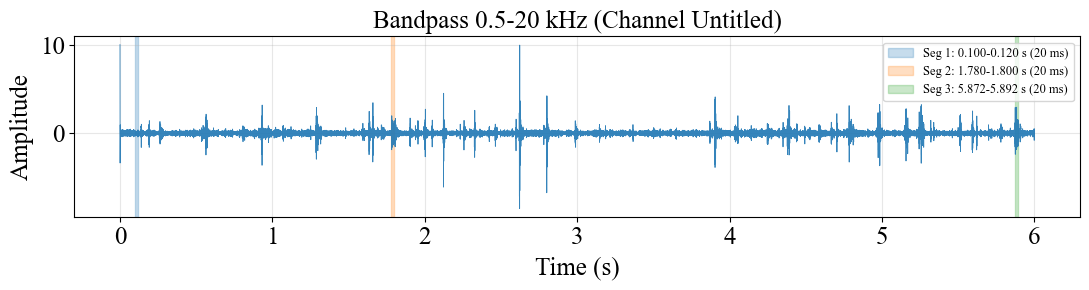

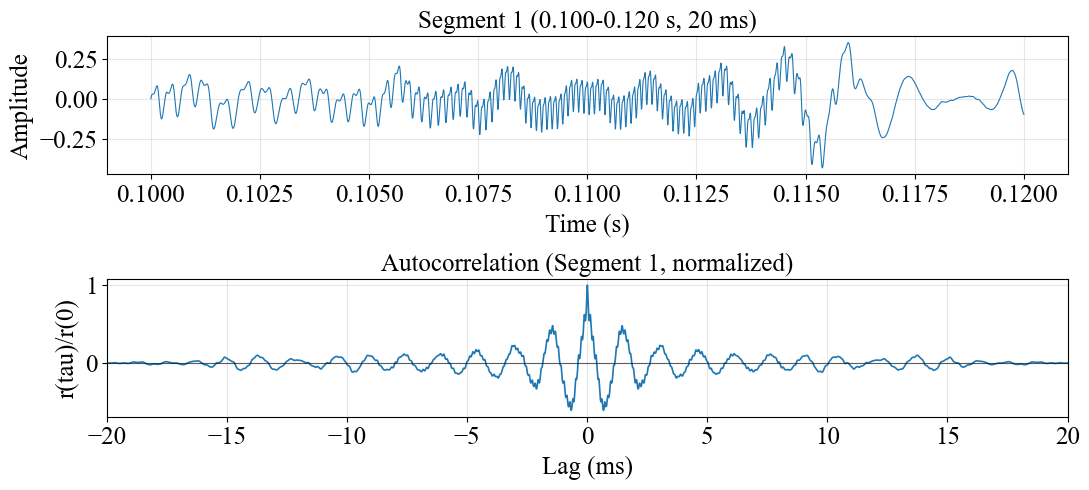

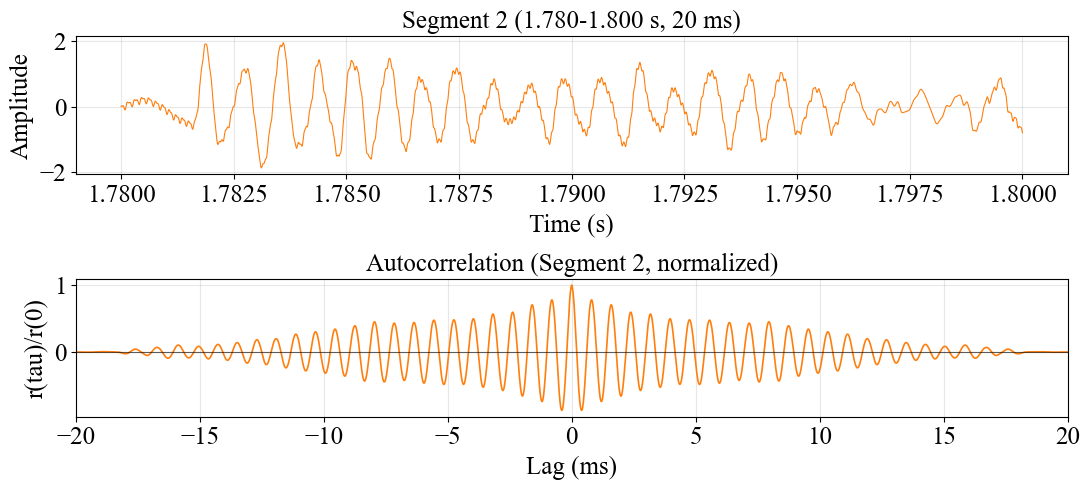

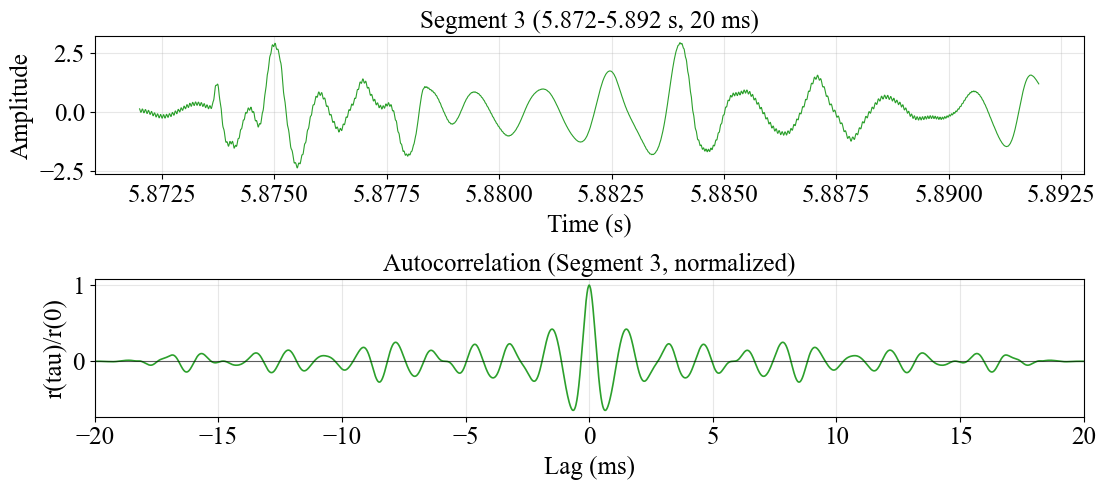

In [45]:
# ---------- 4.2 读取 + 预处理 + 多片段时域/自相关 ----------
FILE_42 = r"E:\codes\pccp\ZZ2026\bk\1.5\SemiPhase-1MHz-2026-8-21-17-10-58.tdms"

# 本节预处理参数（带通范围/阶数，独立定义、可调，不依赖 4.1）
BP_LO42, BP_HI42, BP_ORDER42 = 0.5e3, 20e3, 4

# 片段列表（可增删）：每项为 (起始时刻 s, 时长 ms)；起始时刻写 None 表示自动以 4.1 首个事件峰值为中心
SEGMENTS = [(0.10, 20.0),  (1.78,20), (5.872,20) ]
# SEGMENTS = [ (1.78,20)]

# (0.20, 20.0), (0.35, 20.0),,(4.97,20),(2.62, 20)
AC_LIM = 20           # 自相关横轴显示范围 (±ms)，可调

dd = load_signal(FILE_42)
x42 = dd['phase_data'][:, SEL_CH].astype(float)
fs42 = float(dd['sample_rate'])
x_pp42 = preprocess_bandpass(x42, fs42, (BP_LO42, BP_HI42), BP_ORDER42)
t42 = np.arange(len(x_pp42)) / fs42
print(f'{Path(FILE_42).stem}: fs={fs42:g} Hz, npts={len(x_pp42)}, '
      f'时长 {len(x_pp42)/fs42:.3f} s, 通道={dd["channel_names"][SEL_CH]}')
print(f'预处理: Butterworth {BP_ORDER42} 阶带通 {BP_LO42/1e3:g}~{BP_HI42/1e3:g} kHz '
      f'(sosfiltfilt 零相位)')

# ---------- 自动起始时刻（None -> 以 4.1 检测到的首个事件峰值为中心） ----------
_label42 = next((k for k, p in BAND_FILES4.items()
                 if Path(p).name == Path(FILE_42).name), None)
_ev42 = detect_res4[_label42][2][0] if (_label42 and detect_res4[_label42][2]) else None

# ---------- 逐段截取 + 自相关（去均值，FFT 法，r(0) 归一化） ----------
from scipy.signal import correlate

seg_res = []   # [(t0, dur_ms, t_seg, seg, lag_ms, r)]
for t0, dur in SEGMENTS:
    if t0 is None:
        t0 = max(_ev42['t_peak'] - dur * 1e-3 / 2, 0.0) if _ev42 else 0.20
    t0, dur = float(t0), float(dur)
    i0 = int(round(t0 * fs42))
    seg = x_pp42[i0:i0 + int(round(dur * 1e-3 * fs42))]
    t_seg = (np.arange(len(seg)) + i0) / fs42
    _s0 = seg - seg.mean()
    r = correlate(_s0, _s0, mode='full', method='fft')
    r = r / r[len(seg) - 1]                 # 归一化：r(0)=1
    lag_ms = (np.arange(len(r)) - (len(seg) - 1)) / fs42 * 1e3   # 时延 (ms)
    seg_res.append((t0, dur, t_seg, seg, lag_ms, r))
    print(f'Segment {len(seg_res)}: t={t_seg[0]:.3f}~{t_seg[-1]:.3f} s '
          f'({dur:g} ms, {len(seg)} 点), r(0) 归一化')

# ---------- 绘图 1：全程预处理波形 + 各片段位置 ----------
fig, ax = plt.subplots(figsize=(11, 3))
cyc = plt.rcParams['axes.prop_cycle'].by_key()['color']
ax.plot(t42, x_pp42, lw=0.6, alpha=0.9)
for i, (t0, dur, t_seg, *_rest) in enumerate(seg_res):
    c = cyc[i % len(cyc)]
    ax.axvspan(t_seg[0], t_seg[-1], color=c, alpha=0.25,
               label=f'Seg {i + 1}: {t_seg[0]:.3f}-{t_seg[-1]:.3f} s ({dur:g} ms)')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Amplitude')
ax.set_title(f'Bandpass {BP_LO42/1e3:g}-{BP_HI42/1e3:g} kHz '
             f'(Channel {dd["channel_names"][SEL_CH]})')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ---------- 绘图 2：每个片段一张图（上：时域波形，下：自相关曲线） ----------
for i, (t0, dur, t_seg, seg, lag_ms, r) in enumerate(seg_res):
    c = cyc[i % len(cyc)]
    fig, axes = plt.subplots(2, 1, figsize=(11, 5.0))
    axes[0].plot(t_seg, seg, lw=0.8, color=c)
    axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Amplitude')
    axes[0].set_title(f'Segment {i + 1} ({t_seg[0]:.3f}-{t_seg[-1]:.3f} s, {dur:g} ms)')
    axes[0].grid(alpha=0.3)

    axes[1].plot(lag_ms, r, lw=1.2, color=c)
    axes[1].axhline(0, color='k', lw=0.8, alpha=0.6)
    axes[1].set_xlim(-AC_LIM, AC_LIM)
    axes[1].set_xlabel('Lag (ms)'); axes[1].set_ylabel('r(tau)/r(0)')
    axes[1].set_title(f'Autocorrelation (Segment {i + 1}, normalized)')
    axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()


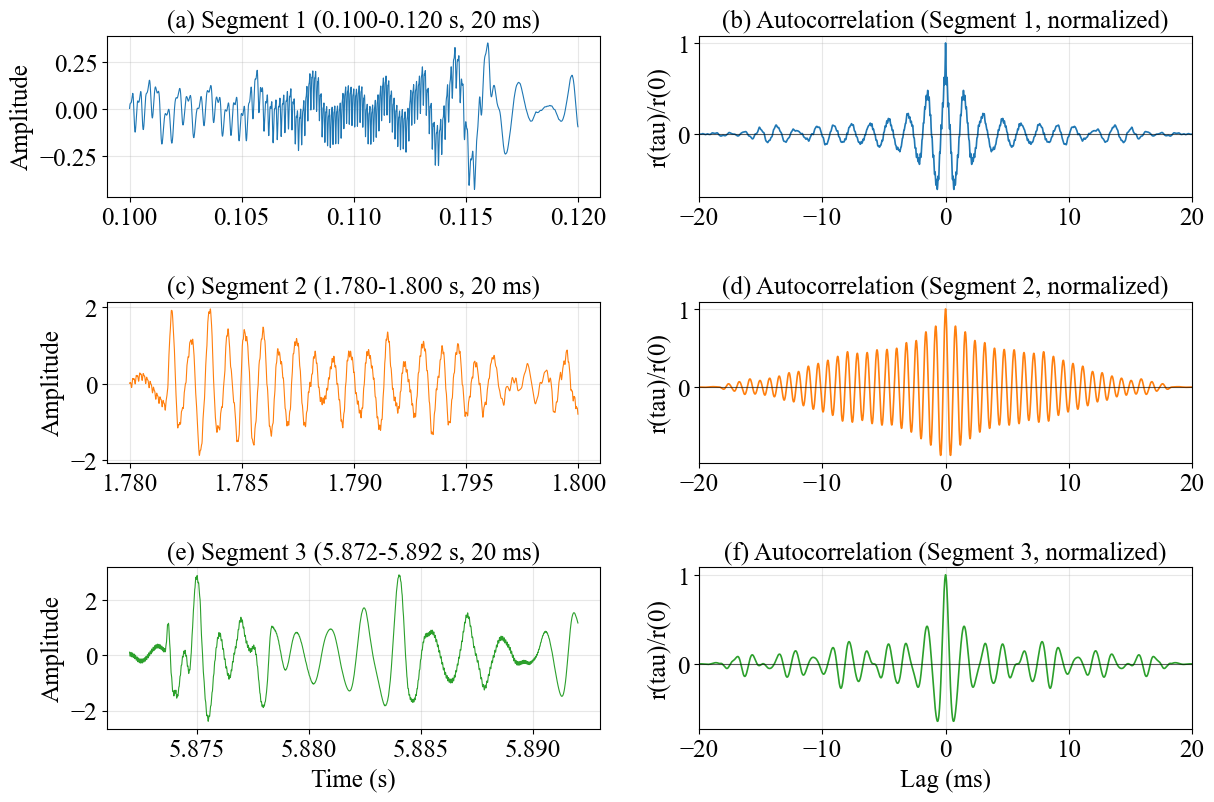

In [36]:
# 将上面三个片段时域图及其自相关曲线画到一张图上，三行两列
fig, axes = plt.subplots(3, 2, figsize=(14, 9), gridspec_kw={'hspace': 0.65})
LETTERS = 'abcdefghij'
last = len(seg_res) - 1
for i, (t0, dur, t_seg, seg, lag_ms, r) in enumerate(seg_res):
    c = cyc[i % len(cyc)]
    axes[i, 0].plot(t_seg, seg, lw=0.8, color=c)
    axes[i, 0].set_ylabel('Amplitude')
    axes[i, 0].set_title(f'({LETTERS[2 * i]}) Segment {i + 1} ({t_seg[0]:.3f}-{t_seg[-1]:.3f} s, {dur:g} ms)')
    axes[i, 0].grid(alpha=0.3)

    axes[i, 1].plot(lag_ms, r, lw=1.2, color=c)
    axes[i, 1].axhline(0, color='k', lw=0.8, alpha=0.6)
    axes[i, 1].set_xlim(-AC_LIM, AC_LIM)
    axes[i, 1].set_ylabel('r(tau)/r(0)')
    axes[i, 1].set_title(f'({LETTERS[2 * i + 1]}) Autocorrelation (Segment {i + 1}, normalized)')
    axes[i, 1].grid(alpha=0.3)
    if i == last:
        axes[i, 0].set_xlabel('Time (s)')
        axes[i, 1].set_xlabel('Lag (ms)')
    else:
        axes[i, 0].tick_params(axis='x', labelbottom=True)
        axes[i, 1].tick_params(axis='x', labelbottom=True)


#### 4.2.2 多片段时域与自相关合并绘图

**阶段 A**：五个文件（BK15-1~5）各取一个 20 ms 窗口，绘制时域波形与归一化自相关曲线（每文件一行）。

**阶段 B**：第一个文件（BK15-1，`SemiPhase-1MHz-2026-8-21-16-27-44`）的**冲击信号窗口**（24 个，`SEGMENTS_B`），以「左列时域波形 + 右列归一化自相关」合并绘制，颜色逐段对应；**每张图最多 6 个片段**（`CHUNK` 可调），片段多时自动分图。

**阶段 C**：第一个文件的**鼓包噪声窗口**（6 个，`SEGMENTS_C`），同样以「左列时域波形 + 右列归一化自相关」合并绘制。

自相关横轴显示范围为 `TAU_MAX_MS`（±ms，4.2.2 节**单独定义、可调**）。


BK15-1 (16-27-44): t=3.942~3.962 s (20 ms), r(0) 归一化
BK15-2 (16-28-20): t=2.305~2.325 s (20 ms), r(0) 归一化
BK15-3 (17-10-58): t=1.781~1.801 s (20 ms), r(0) 归一化
BK15-4 (17-11-46): t=5.343~5.363 s (20 ms), r(0) 归一化
BK15-5 (17-13-46): t=5.402~5.422 s (20 ms), r(0) 归一化
SemiPhase-1MHz-2026-8-21-16-27-44: fs=1e+06 Hz, npts=6000000, 时长 6.000 s, 通道=Untitled
预处理: Butterworth 4 阶带通 0.5~20 kHz (sosfiltfilt 零相位)
[B] t=0.187~0.207 s (20 ms, 20000 点), r(0) 归一化
[B] t=0.204~0.224 s (20 ms, 20000 点), r(0) 归一化
[B] t=0.570~0.590 s (20 ms, 20000 点), r(0) 归一化
[B] t=0.590~0.610 s (20 ms, 20000 点), r(0) 归一化
[B] t=0.885~0.905 s (20 ms, 20000 点), r(0) 归一化
[B] t=0.970~0.990 s (20 ms, 20000 点), r(0) 归一化
[B] t=1.205~1.225 s (20 ms, 20000 点), r(0) 归一化
[B] t=1.220~1.240 s (20 ms, 20000 点), r(0) 归一化
[B] t=1.620~1.640 s (20 ms, 20000 点), r(0) 归一化
[B] t=1.970~1.990 s (20 ms, 20000 点), r(0) 归一化
[B] t=2.295~2.315 s (20 ms, 20000 点), r(0) 归一化
[B] t=2.720~2.740 s (20 ms, 20000 点), r(0) 归一化
[B] t=2.930~2.950 s (20 ms, 20000

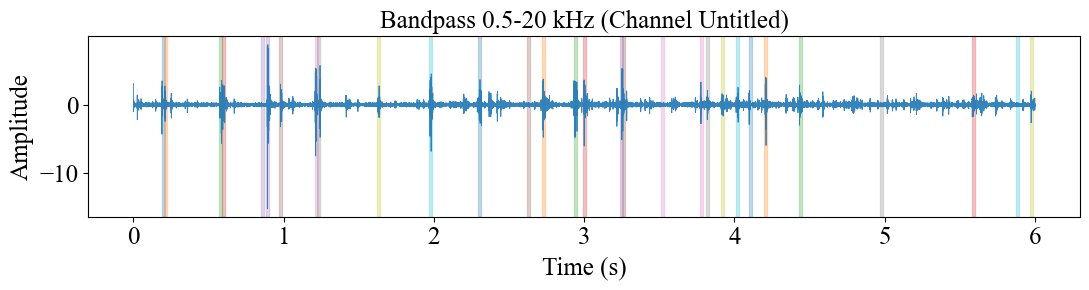

In [37]:
# ---------- 4.2 读取 + 预处理 + 多片段时域/自相关 ----------
# 五个文件（BK15-1~5）各取一个 20 ms 窗口：label -> (path, t0 s)
FILES_42 = {
    'BK15-1 (16-27-44)': (r"E:\codes\pccp\ZZ2026\bk\1.5\SemiPhase-1MHz-2026-8-21-16-27-44.tdms", 3.942),
    'BK15-2 (16-28-20)': (r"E:\codes\pccp\ZZ2026\bk\1.5\SemiPhase-1MHz-2026-8-21-16-28-20.tdms", 2.305),
    'BK15-3 (17-10-58)': (r"E:\codes\pccp\ZZ2026\bk\1.5\SemiPhase-1MHz-2026-8-21-17-10-58.tdms", 1.781),
    'BK15-4 (17-11-46)': (r"E:\codes\pccp\ZZ2026\bk\1.5\SemiPhase-1MHz-2026-8-21-17-11-46.tdms", 5.343),
    'BK15-5 (17-13-46)': (r"E:\codes\pccp\ZZ2026\bk\1.5\SemiPhase-1MHz-2026-8-21-17-13-46.tdms", 5.402),
}

# 本节预处理参数（带通范围/阶数，独立定义、可调，不依赖 4.1）
BP_LO42, BP_HI42, BP_ORDER42 = 0.5e3, 20e3, 4

DUR_MS42 = 20.0   # 窗口时长 (ms)

# 片段列表（可增删）：每项为 (起始时刻 s, 时长 ms)；起始时刻写 None 表示自动以 4.1 首个事件峰值为中心
# ======================= 阶段 B：第一个文件的冲击信号窗口【24 个】 =======================
SEGMENTS_B = [
    (0.187, 20.0), (0.204, 20.0), (0.57, 20.0), (0.59, 20.0), (0.885, 20.0),
    (0.97, 20.0), (1.205, 20.0), (1.22, 20.0), (1.62, 20.0), (1.97, 20.0),
    (2.295, 20.0), (2.72, 20.0), (2.93, 20.0), (2.99, 20.0), (3.24, 20.0),
    (3.25, 20.0), (3.77, 20.0), (3.81, 20.0), (3.91, 20.0),
    (4.01, 20.0), (4.095, 20.0), (4.2, 20.0), (4.43, 20.0), (5.58, 20.0),
]
# ======================= 阶段 C：第一个文件的鼓包噪声窗口【6 个】 =======================
SEGMENTS_C = [
    (0.85, 20.0), (2.62, 20), (3.51, 20.0), (4.97, 20), (5.97, 20.0), (5.872, 20),
]

# 二阶窗口自相关计算由 0.4 节 segment_autocorrelation 统一提供。

# ---------- 阶段 A：五个文件各取一个窗口的自相关 ----------
multi_res = {}   # label -> (stem, fs, t_seg, seg, lag_ms, r)
for label, (p, t0) in FILES_42.items():
    multi_res[label] = segment_autocorrelation(p, t0, DUR_MS42, SEL_CH, (BP_LO42, BP_HI42), BP_ORDER42)
    stem, f_, t_seg, seg, lag_ms, r = multi_res[label]
    print(f'{label}: t={t_seg[0]:.3f}~{t_seg[-1]:.3f} s ({DUR_MS42:g} ms), r(0) 归一化')

# ---------- 阶段 B：第一个文件（BK15-1）的多片段 ----------
_first_key = next(iter(FILES_42))
FILE_42 = FILES_42[_first_key][0]   # 第一个文件
dd = load_signal(FILE_42)
x42 = dd['phase_data'][:, SEL_CH].astype(float)
fs42 = float(dd['sample_rate'])
x_pp42 = preprocess_bandpass(x42, fs42, (BP_LO42, BP_HI42), BP_ORDER42)
t42 = np.arange(len(x_pp42)) / fs42
print(f'{Path(FILE_42).stem}: fs={fs42:g} Hz, npts={len(x_pp42)}, '
      f'时长 {len(x_pp42)/fs42:.3f} s, 通道={dd["channel_names"][SEL_CH]}')
print(f'预处理: Butterworth {BP_ORDER42} 阶带通 {BP_LO42/1e3:g}~{BP_HI42/1e3:g} kHz '
      f'(sosfiltfilt 零相位)')

# ---------- 自动起始时刻（None -> 以 4.1 检测到的首个事件峰值为中心） ----------
_label42 = next((k for k, p in BAND_FILES4.items()
                 if Path(p).name == Path(FILE_42).name), None)
_ev42 = detect_res4[_label42][2][0] if (_label42 and detect_res4[_label42][2]) else None

seg_resB = []   # 阶段 B 片段 [(t0, dur_ms, t_seg, seg, lag_ms, r)]
seg_resC = []   # 阶段 C 片段
for tag, seg_list in (('B', SEGMENTS_B), ('C', SEGMENTS_C)):
    for t0, dur in seg_list:
        if t0 is None:
            t0 = max(_ev42['t_peak'] - dur * 1e-3 / 2, 0.0) if _ev42 else 0.20
        t0, dur = float(t0), float(dur)
        i0 = int(round(t0 * fs42))
        seg = x_pp42[i0:i0 + int(round(dur * 1e-3 * fs42))]
        t_seg = (np.arange(len(seg)) + i0) / fs42
        lag_ms, r = autocorr_curve(seg, fs42, normalize=True, demean=True, method='fft')
        item = (t0, dur, t_seg, seg, lag_ms, r)
        (seg_resB if tag == 'B' else seg_resC).append(item)
        print(f'[{tag}] t={t_seg[0]:.3f}~{t_seg[-1]:.3f} s '
              f'({dur:g} ms, {len(seg)} 点), r(0) 归一化')
seg_res = seg_resB + seg_resC   # 合并（顺序：阶段 B 在前，阶段 C 在后），供 4.2.3/4.2.4 使用
print(f'阶段 B 共 {len(seg_resB)} 个片段, 阶段 C 共 {len(seg_resC)} 个片段, 合计 {len(seg_res)} 个')

# ---------- 绘图：全程预处理波形 + 各片段位置 ----------
fig, ax = plt.subplots(figsize=(11, 3))
cyc = plt.rcParams['axes.prop_cycle'].by_key()['color']
ax.plot(t42, x_pp42, lw=0.6, alpha=0.9)
for i, (t0, dur, t_seg, *_rest) in enumerate(seg_res):
    tag = 'B' if i < len(seg_resB) else 'C'
    c = cyc[i % len(cyc)]
    ax.axvspan(t_seg[0], t_seg[-1], color=c, alpha=0.25,
               label=f'{tag}{i + 1}: {t_seg[0]:.3f}-{t_seg[-1]:.3f} s ({dur:g} ms)')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Amplitude')
ax.set_title(f'Bandpass {BP_LO42/1e3:g}-{BP_HI42/1e3:g} kHz '
             f'(Channel {dd["channel_names"][SEL_CH]})')
plt.tight_layout(); plt.show()


#### 4.2.4 保存五文件平均自相关模板至本地

This subsection builds the mean normalized second-order autocorrelation template from the five 20 ms broken-wire windows in Section 4.2.2 stage A, then saves it as a local `.npz` file. Later sections 1.1, 2.3, 3.2, 4.2.5, and 5.1 read this same local template for short-time autocorrelation-template detection.


Saved mean autocorr template: E:\codes\ZZ-BK\notebooks\outputs\autocorr_template_bk15_mean.npz


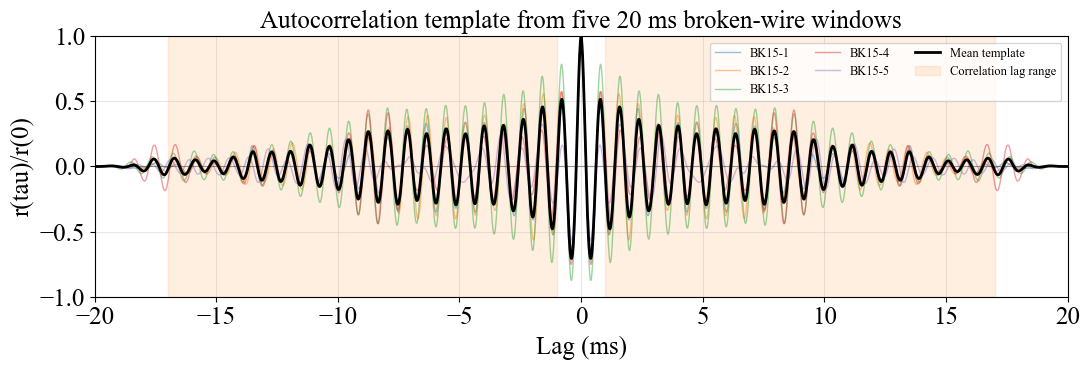

In [38]:
# ---------- 4.2.4 save five-file mean autocorr template locally ----------
AC_TEMPLATE_PATH = Path(r'E:\codes\ZZ-BK\notebooks\outputs\autocorr_template_bk15_mean.npz')
AC_TEMPLATE_TAU_MAX_MS = 20.0
AC_TEMPLATE_CORR_LAG_MS = (1.0, 17.0)

ac_tpl_lag_ms, ac_tpl, ac_tpl_stack = autocorr_template_from_results(multi_res)
ac_tpl_meta = {
    'source': '4.2.2 stage A, five 1.5 m/s broken-wire windows',
    'win_ms': 20.0,
    'corr_lag_ms': AC_TEMPLATE_CORR_LAG_MS,
    'band_hz': (BP_LO42, BP_HI42),
    'order': BP_ORDER42,
    'files': list(multi_res.keys()),
}
save_autocorr_template(AC_TEMPLATE_PATH, ac_tpl_lag_ms, ac_tpl, stack=ac_tpl_stack, meta=ac_tpl_meta)
print(f'Saved mean autocorr template: {AC_TEMPLATE_PATH}')

fig, ax = plt.subplots(figsize=(11, 3.8))
for j, (label, item) in enumerate(multi_res.items()):
    ax.plot(item[4], item[5], lw=1.0, color=cyc[j % len(cyc)], alpha=0.45, label=label.split(' (')[0])
ax.plot(ac_tpl_lag_ms, ac_tpl, color='k', lw=2.0, label='Mean template')
_lo, _hi = sorted(AC_TEMPLATE_CORR_LAG_MS)
ax.axvspan(_lo, _hi, color='tab:orange', alpha=0.12, label='Correlation lag range')
ax.axvspan(-_hi, -_lo, color='tab:orange', alpha=0.12)
ax.axhline(0, color='k', lw=0.8, alpha=0.35)
ax.set_xlim(-AC_TEMPLATE_TAU_MAX_MS, AC_TEMPLATE_TAU_MAX_MS); ax.set_ylim(-1, 1)
ax.set_xlabel('Lag (ms)'); ax.set_ylabel('r(tau)/r(0)')
ax.set_title('Autocorrelation template from five 20 ms broken-wire windows')
ax.legend(fontsize=9, ncol=3); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


#### 4.2.5 读取本地自相关模板检测 1.5 m/s 数据

This subsection loads the local mean autocorrelation template saved by 4.2.4 and applies short-time autocorrelation-template detection to every TDMS file under `E:\codes\pccp\ZZ2026\bk\1.5`, with one detection plot per file.


In [49]:
%matplotlib qt

In [50]:
# ---------- 4.2.5 parameters: paths, preprocessing, and autocorr-template detection ----------
# Data folder for this subsection. Edit FILES_425 if only part of the TDMS files should be processed.
DATA_DIR_425 = Path(r'E:\codes\pccp\ZZ2026\bk\1.5')
FILES_425 = sorted(DATA_DIR_425.glob('*.tdms'))

# Local autocorrelation template saved by Section 4.2.4.
AC425_TEMPLATE_PATH = Path(r'E:\codes\ZZ-BK\notebooks\outputs\autocorr_template_bk15_mean.npz')

# Preprocessing parameters: zero-phase Butterworth bandpass before feature calculation.
BP425_LO = 0.5e3       # Bandpass lower cutoff (Hz)
BP425_HI = 20e3        # Bandpass upper cutoff (Hz)
BP425_ORDER = 4        # Butterworth filter order

# Short-time autocorrelation-template feature parameters.
AC425_WIN_MS = 20.0              # Sliding window length (ms); aligned with the template window length
AC425_STEP_MS = 10.0             # Sliding step (ms); smaller values give denser detection curves
AC425_CORR_LAG_MS = (1.0, 17.0)  # Absolute lag range used for Pearson correlation (ms)

# Soft-threshold event detection parameters applied to the correlation curve.
AC425_K = 6.0                    # MAD threshold multiplier; larger values are stricter
AC425_MIN_GAP = 4                # Maximum frame gap for merging adjacent detections into one event

print(f'1.5 m/s directory has {len(FILES_425)} TDMS files:')
for _p in FILES_425:
    print('  -', _p.name)


1.5 m/s directory has 6 TDMS files:
  - SemiPhase-1MHz-2026-8-21-16-27-44.tdms
  - SemiPhase-1MHz-2026-8-21-16-28-20.tdms
  - SemiPhase-1MHz-2026-8-21-17-10-58.tdms
  - SemiPhase-1MHz-2026-8-21-17-11-46.tdms
  - SemiPhase-1MHz-2026-8-21-17-13-46.tdms
  - SemiPhase-1MHz-2026-8-21-17-13-5.tdms


In [51]:
# ---------- 4.2.5 compute and plot: waveform + autocorr-template correlation ----------
ac425_results = detect_autocorr_template_files(
    FILES_425, AC425_TEMPLATE_PATH,
    win_ms=AC425_WIN_MS, step_ms=AC425_STEP_MS,
    corr_lag_ms=AC425_CORR_LAG_MS,
    threshold_k=AC425_K, min_gap_frames=AC425_MIN_GAP,
    band=(BP425_LO, BP425_HI), order=BP425_ORDER,
    channel=SEL_CH,
)
plot_autocorr_template_detection_results(ac425_results, section_label='4.2.5')


Loaded autocorr template: E:\codes\ZZ-BK\notebooks\outputs\autocorr_template_bk15_mean.npz
SemiPhase-1MHz-2026-8-21-16-27-44.tdms: thr=0.350, events=1
SemiPhase-1MHz-2026-8-21-16-28-20.tdms: thr=0.345, events=4
SemiPhase-1MHz-2026-8-21-17-10-58.tdms: thr=0.360, events=1
SemiPhase-1MHz-2026-8-21-17-11-46.tdms: thr=0.398, events=2
SemiPhase-1MHz-2026-8-21-17-13-46.tdms: thr=0.416, events=1
SemiPhase-1MHz-2026-8-21-17-13-5.tdms: thr=0.392, events=2


In [52]:
# ---------- 4.2.2 多片段时域 + 自相关合并绘图（依赖上一单元的 multi_res / seg_res / cyc） ----------
TAU_MAX_MS = 20.0   # 自相关最大时延 (±ms)，4.2.2 节单独定义、可调
CHUNK = 6   # 每张图的片段数（n 行 × 2 列），可调
cyc = plt.rcParams['axes.prop_cycle'].by_key()['color']

# ---------- 阶段 A：五个文件各取一个窗口（时域 + 自相关） ----------
LETTERS = 'abcdefghijklmnopqrstuvwxyz'
nrA = len(multi_res)
fig, axes = plt.subplots(nrA, 2, figsize=(12, 2.8 * nrA), squeeze=False)
for j, (label, (stem, f_, t_seg, seg, lag_ms, r)) in enumerate(multi_res.items()):
    c = cyc[j % len(cyc)]
    ax1 = axes[j][0]
    ax1.plot(t_seg, seg, lw=0.8, color=c)
    ax1.set_ylabel('Amplitude')
    ax1.set_title(f'({LETTERS[2 * j]}) {label} ({t_seg[0]:.3f}-{t_seg[-1]:.3f} s)')
    ax1.grid(alpha=0.3)

    ax2 = axes[j][1]
    ax2.plot(lag_ms, r, lw=1.2, color=c)
    ax2.axhline(0, color='k', lw=0.8, alpha=0.6)
    ax2.set_xlim(-TAU_MAX_MS, TAU_MAX_MS)
    ax2.set_ylabel('r(tau)/r(0)')
    ax2.set_title(f'({LETTERS[2 * j + 1]}) Autocorrelation ({label}, normalized)')
    ax2.grid(alpha=0.3)
    if j == nrA - 1:
        ax1.set_xlabel('Time (s)')
        ax2.set_xlabel('Lag (ms)')
    else:
        ax1.tick_params(axis='x', labelbottom=True)
        ax2.tick_params(axis='x', labelbottom=True)
plt.tight_layout(); plt.show()

# ---------- 阶段 B / C：第一个文件的两组片段（时域 + 自相关），2 列分图 ----------
for tag, seg_list in (('B', seg_resB), ('C', seg_resC)):
    n_fig = int(np.ceil(len(seg_list) / CHUNK))
    for f_ in range(n_fig):
        grp = seg_list[f_ * CHUNK:(f_ + 1) * CHUNK]
        nr = len(grp)
        fig, axes = plt.subplots(nr, 2, figsize=(12, 2.8 * nr), squeeze=False)
        for j, (t0, dur, t_seg, seg, lag_ms, r) in enumerate(grp):
            c = cyc[(f_ * CHUNK + j) % len(cyc)]
            ax1 = axes[j][0]
            ax1.plot(t_seg, seg, lw=0.8, color=c)
            ax1.set_ylabel('Amplitude')
            ax1.set_title(f'({LETTERS[2 * j]}) [{tag}] Segment {f_ * CHUNK + j + 1} '
                          f'({t_seg[0]:.3f}-{t_seg[-1]:.3f} s, {dur:g} ms)')
            ax1.grid(alpha=0.3)

            ax2 = axes[j][1]
            ax2.plot(lag_ms, r, lw=1.2, color=c)
            ax2.axhline(0, color='k', lw=0.8, alpha=0.6)
            ax2.set_xlim(-TAU_MAX_MS, TAU_MAX_MS)
            ax2.set_ylabel('r(tau)/r(0)')
            ax2.set_title(f'({LETTERS[2 * j + 1]}) Autocorrelation ([{tag}] Segment {f_ * CHUNK + j + 1}, normalized)')
            ax2.grid(alpha=0.3)
            if j == nr - 1:
                ax1.set_xlabel('Time (s)')
                ax2.set_xlabel('Lag (ms)')
            else:
                ax1.tick_params(axis='x', labelbottom=True)
                ax2.tick_params(axis='x', labelbottom=True)
        plt.tight_layout(); plt.show()


NameError: name 'multi_res' is not defined

#### 4.2.3（补充）五文件窗口 / 首文件多片段：二阶自相关曲线

在 4.2.2 的时域 + 自相关合并图基础上，单独绘制**二阶自相关曲线**（自相关图），便于跨文件、跨片段比较：

- **阶段 A**：五个文件（BK15-1~5）各取一个 20 ms 窗口的自相关曲线叠加；
- **阶段 B**：第一个文件（BK15-1，`SemiPhase-1MHz-2026-8-21-16-27-44`）**冲击信号窗口**（24 个，`SEGMENTS_B`）的自相关曲线叠加；
- **阶段 C**：第一个文件**鼓包噪声窗口**（6 个，`SEGMENTS_C`）的自相关曲线叠加。

依赖上一单元的 `multi_res` / `seg_resB` / `seg_resC`；横轴范围 `TAU_MAX_MS` 可调。


In [43]:
# ---------- 4.2.3 补充：五文件窗口 + 首文件多片段，二阶自相关曲线（依赖上一单元 multi_res / seg_res） ----------
TAU_MAX_MS = 20.0   # 自相关横轴范围 (±ms)，可调
cyc = plt.rcParams['axes.prop_cycle'].by_key()['color']

# ---------- 阶段 A：五个文件各取一个窗口的自相关曲线 ----------
fig, ax = plt.subplots(figsize=(11, 3.8))
for j, (label, (stem, f_, t_seg, seg, lag_ms, r)) in enumerate(multi_res.items()):
    ax.plot(lag_ms, r, lw=1.3, color=cyc[j % len(cyc)], label=label.split(' (')[0])
ax.axhline(0, color='k', lw=0.8, alpha=0.6)
ax.set_xlim(-TAU_MAX_MS, TAU_MAX_MS)
ax.set_xlabel('Lag (ms)'); ax.set_ylabel('r(tau)/r(0)')
ax.set_title('Autocorrelation: one 20 ms window per file (5 files)')
# ax.legend(fontsize=18, loc='upper right'); ax.grid(alpha=0.3)
ax.set_ylim(-1,1)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ---------- 阶段 B：第一个文件冲击信号片段的自相关曲线叠加 ----------
fig, ax = plt.subplots(figsize=(11, 3.8))
for j, (t0, dur, t_seg, seg, lag_ms, r) in enumerate(seg_resB):
    ax.plot(lag_ms, r, lw=1.0, color=cyc[j % len(cyc)], alpha=0.9, label=f'B Seg {j + 1}')
ax.axhline(0, color='k', lw=0.8, alpha=0.6)
ax.set_xlim(-TAU_MAX_MS, TAU_MAX_MS)
ax.set_xlabel('Lag (ms)'); ax.set_ylabel('r(tau)/r(0)')
ax.set_title(f'Autocorrelation of {len(seg_resB)} impulse segments')
# ax.legend(fontsize=18, loc='upper right'); ax.grid(alpha=0.3)
ax.set_ylim(-1,1)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ---------- 阶段 C：第一个文件鼓包噪声片段的自相关曲线叠加 ----------
fig, ax = plt.subplots(figsize=(11, 3.8))
for j, (t0, dur, t_seg, seg, lag_ms, r) in enumerate(seg_resC):
    ax.plot(lag_ms, r, lw=1.0, color=cyc[j % len(cyc)], alpha=0.9, label=f'C Seg {j + 1}')
ax.axhline(0, color='k', lw=0.8, alpha=0.6)
ax.set_xlim(-TAU_MAX_MS, TAU_MAX_MS)
ax.set_xlabel('Lag (ms)'); ax.set_ylabel('r(tau)/r(0)')
ax.set_title(f'Autocorrelation of {len(seg_resC)} bulge segments')
# ax.legend(fontsize=18, loc='upper right'); ax.grid(alpha=0.3)
ax.set_ylim(-1,1)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### 4.3、 信号三阶自相关特征分析

#### 4.3.1 三阶自相关（二维时延平面 + 对角切片）

三阶自相关描述三个采样点之间的联合相关关系，是二阶自相关向高阶统计量的扩展。二阶自相关主要反映两点之间的线性时延相似性，而三阶自相关进一步引入第三个时延点，因此对非高斯性、非对称冲击、尖峰偏态以及相位耦合结构更敏感。对断丝信号而言，若冲击的尖峰性或偏态结构在若干时延上稳定重复，三阶自相关通常能比普通二阶特征更突出地呈现这类高阶结构。

三阶自相关定义为：

$$R_3(\tau_1,\tau_2)=\frac{1}{N_{\tau_1,\tau_2}}\sum_{t\in\Omega_{\tau_1,\tau_2}} x(t)\,x(t+\tau_1)\,x(t+\tau_2)$$

其中：

- $x(t)$：预处理后信号在时刻或采样索引 $t$ 处的幅值；
- $\tau_1,\tau_2$：两个时延变量，图中换算为 ms 显示；
- $\Omega_{\tau_1,\tau_2}$：保证 $t$、$t+\tau_1$ 和 $t+\tau_2$ 均落在窗口内的有效索引集合；
- $N_{\tau_1,\tau_2}=|\Omega_{\tau_1,\tau_2}|$：当前时延组合下参与平均的有效样本数；
- $R_3(\tau_1,\tau_2)$：三阶自相关值，表示当前样本与两个延迟样本乘积的平均耦合强度。

- **二维时延平面**：随 $(\tau_1,\tau_2)$ 变化，保留两个时延之间的联合结构，适合观察非对称冲击、尖峰、偏态和相位耦合特征。
- **对角切片**：$R_3(\tau,\tau)=E[x(t)x(t+\tau)^2]$。物理上，它度量当前样本与同一滞后位置“能量/幅值平方”的耦合强度。若断丝冲击具有稳定的非高斯尖峰或偏态结构，对角切片往往会在相关时延附近形成可重复的峰谷。

常见切片包括：$R_3(\tau,\tau)$ 用于提取紧凑的一维高阶冲击特征；$R_3(\tau,0)$ 或 $R_3(0,\tau)$ 用于观察瞬时能量与滞后样本的耦合；$R_3(\tau,-\tau)$ 关注事件中心前后对称时延上的三点耦合；固定某一时延的切片 $R_3(\tau_1,\tau_2=c)$ 可用于检查指定传播或反射时延附近的耦合结构。

二维图显示时，三阶自相关平面先去均值，但不做幅值归一化。色条范围由 `R3_COLOR_SCALE` 控制，默认取去均值后最小/最大值范围的 70%。


 每个片段一张图

In [ ]:
# ---------- 4.3.1 三阶自相关：二维时延平面 + 对角切片（单片段逐图显示） ----------
TAU_PLANE_MS = 10.0
TAU_SLICE_MS = 10.0
SEG_IDX_423 = [0, 1, 2]
MAX_PLANE_PTS = 2001
R3_COLOR_SCALE = 0.70

_sel_segments = [seg_res[i] for i in SEG_IDX_423]
lags_plane, tau_plane_ms, Ts, tau_slice_ms, d_tau, _step = lag_grid_for_segments(_sel_segments, fs42, TAU_PLANE_MS, TAU_SLICE_MS, MAX_PLANE_PTS)
r3_plane, r3_diag = {}, {}
for i in SEG_IDX_423:
    seg = seg_res[i][3].astype(float)
    r3_plane[i] = higher_order_plane(seg, lags_plane, fix=0, order=3)
    r3_diag[i] = ac3_diag(seg, Ts)
    print(f'Segment {i + 1} (t={seg_res[i][2][0]:.3f} s): R3(0,0)={r3_diag[i][Ts]:.4g}')

cyc = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, ax = plt.subplots(figsize=(11, 3.6))
for k, i in enumerate(SEG_IDX_423):
    ax.plot(tau_slice_ms, r3_diag[i], lw=1.3, color=cyc[k % len(cyc)], label=f'Seg {i + 1} ({seg_res[i][2][0]:.3f} s)')
ax.axhline(0, color='k', lw=0.8, alpha=0.6)
ax.set_xlabel('Lag (ms)'); ax.set_ylabel('R3(tau,tau)')
ax.set_title(f'Third-order diagonal slice (half-width {TAU_SLICE_MS:g} ms)')
ax.legend(fontsize=9, ncol=3); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

for i in SEG_IDX_423:
    fig, ax = plt.subplots(figsize=(6, 4.6))
    P, vmin, vmax = centered_color_limits(r3_plane[i], R3_COLOR_SCALE)
    im = ax.imshow(P, origin='lower', aspect='auto', cmap='RdBu_r', vmin=vmin, vmax=vmax, extent=[tau_plane_ms[0], tau_plane_ms[-1], tau_plane_ms[0], tau_plane_ms[-1]])
    ax.set_xlabel('tau1 (ms)'); ax.set_ylabel('tau2 (ms)')
    ax.set_title(f'Seg {i + 1} ({seg_res[i][2][0]:.3f} s): demeaned R3(tau1,tau2)')
    plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()


Segment 1 (t=0.187 s): R3(0,0)=-0.2405
Segment 2 (t=0.204 s): R3(0,0)=-0.002202
Segment 3 (t=0.570 s): R3(0,0)=-1.84


: 

所有片段一张图，各自做均方归一化

In [ ]:
# ---------- 4.3.1 三阶自相关：二维时延平面 + 对角切片（所有片段合并显示） ----------
TAU_PLANE_MS = 10.0
TAU_SLICE_MS = 10.0
SEG_IDX_423 = list(range(len(seg_res)))
MAX_PLANE_PTS = 2001
R3_COLOR_SCALE = 0.70

_sel_segments = [seg_res[i] for i in SEG_IDX_423]
lags_plane, tau_plane_ms, Ts, tau_slice_ms, d_tau, _step = lag_grid_for_segments(_sel_segments, fs42, TAU_PLANE_MS, TAU_SLICE_MS, MAX_PLANE_PTS)
r3_plane, r3_diag = {}, {}
for i in SEG_IDX_423:
    seg = seg_res[i][3].astype(float)
    r3_plane[i] = higher_order_plane(seg, lags_plane, fix=0, order=3)
    r3_diag[i] = ac3_diag(seg, Ts)

cyc = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, ax = plt.subplots(figsize=(11, 3.6))
for k, i in enumerate(SEG_IDX_423):
    ax.plot(tau_slice_ms, r3_diag[i], lw=1.0, color=cyc[k % len(cyc)], alpha=0.85, label=f'Seg {i + 1}')
ax.axhline(0, color='k', lw=0.8, alpha=0.6)
ax.set_xlabel('Lag (ms)'); ax.set_ylabel('R3(tau,tau)')
ax.set_title(f'Third-order diagonal slice: {len(SEG_IDX_423)} segments')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

_n = len(SEG_IDX_423); _ncol = 6; _nrow = int(np.ceil(_n / _ncol))
fig, axes = plt.subplots(_nrow, _ncol, figsize=(3.0 * _ncol, 2.8 * _nrow), squeeze=False)
for k, i in enumerate(SEG_IDX_423):
    ax = axes[k // _ncol][k % _ncol]
    P, vmin, vmax = centered_color_limits(r3_plane[i], R3_COLOR_SCALE)
    im = ax.imshow(P, origin='lower', aspect='auto', cmap='RdBu_r', vmin=vmin, vmax=vmax, extent=[tau_plane_ms[0], tau_plane_ms[-1], tau_plane_ms[0], tau_plane_ms[-1]])
    ax.set_xlabel('tau1 (ms)'); ax.set_ylabel('tau2 (ms)'); ax.set_title(f'Seg {i + 1} ({seg_res[i][2][0]:.3f} s)')
    plt.colorbar(im, ax=ax, fraction=0.046)
for k in range(_n, _nrow * _ncol): axes[k // _ncol][k % _ncol].axis('off')
fig.suptitle(f'Demeaned R3(tau1,tau2), no amplitude normalization, color scale={R3_COLOR_SCALE:g}')
plt.tight_layout(); plt.show()


#### 4.3.2（补充）五文件窗口 / 首文件多片段：三阶自相关对角切片

在 4.2.3 三阶自相关平面基础上，以**对角切片** $R_3(\tau,\tau)=E[x(t)x(t+\tau)^2]$ 作为一维三阶自相关曲线，全部画在**一张图**上：

- 上图（阶段 A）：五个文件（BK15-1~5）各取一个 20 ms 窗口的 $R_3(\tau,\tau)$ 曲线叠加；
- 中图（阶段 B）：第一个文件（BK15-1，`SemiPhase-1MHz-2026-8-21-16-27-44`）**冲击信号窗口**（24 个，`SEGMENTS_B`）的 $R_3(\tau,\tau)$ 曲线叠加；
- 下图（阶段 C）：第一个文件**鼓包噪声窗口**（6 个，`SEGMENTS_C`）的 $R_3(\tau,\tau)$ 曲线叠加。

各窗口除以自身均方 $E[x^2]$（`TAU3_NORM=True`，可关）使跨文件 / 跨片段可比；横轴半宽 `TAU3_SLICE_MS`（默认 ±10 ms）可调。依赖上一单元的 `multi_res` / `seg_resB` / `seg_resC` / `fs42`。


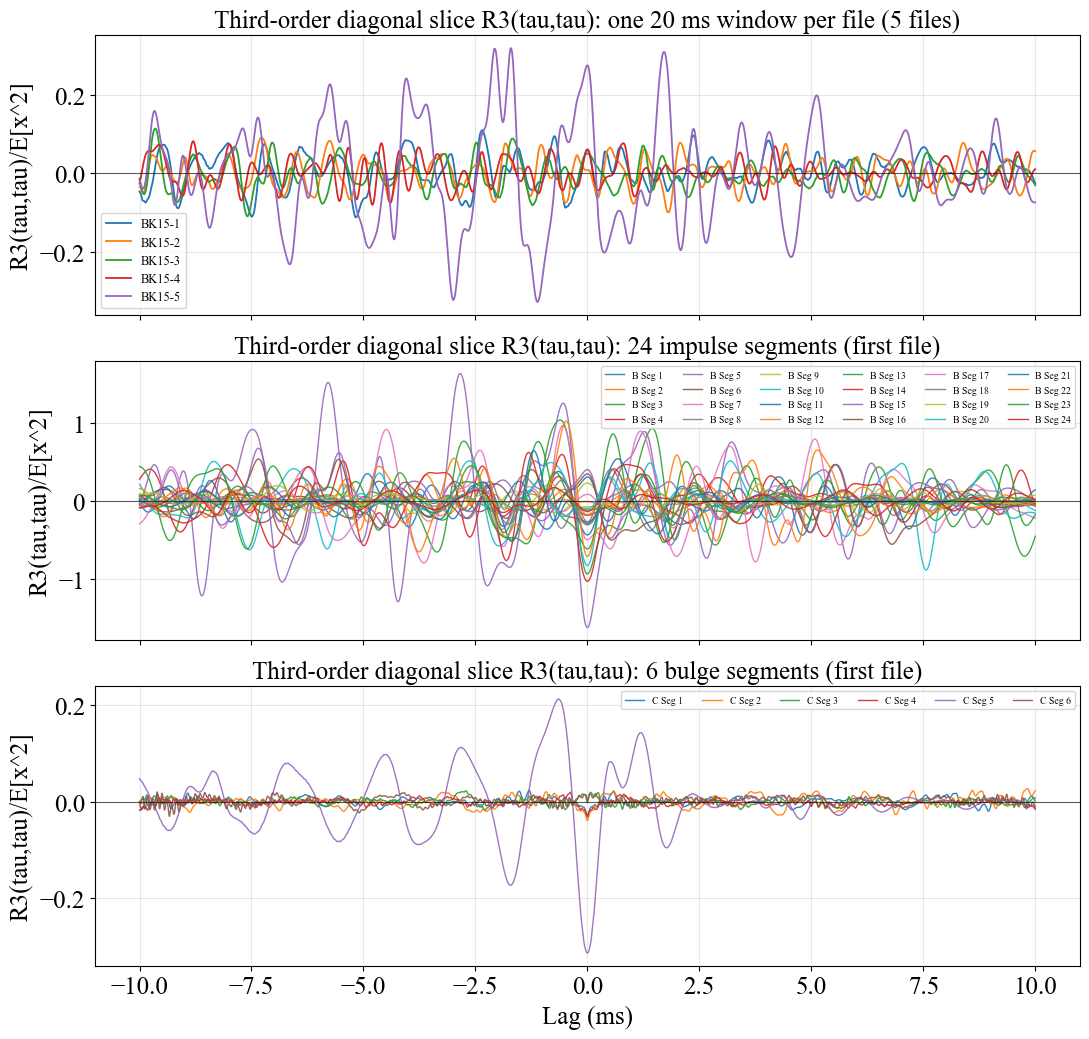

In [ ]:
# ---------- 4.3.2 补充：三阶自相关对角切片 R3(tau,tau)（依赖 multi_res / seg_res / fs42） ----------
TAU3_SLICE_MS = 10.0
TAU3_NORM = True

d_tau = 1e3 / fs42
_nmax3 = min(min(len(seg_res[i][3]) for i in range(len(seg_res))), min(len(multi_res[k][3]) for k in multi_res)) - 1
Ts3 = min(int(round(TAU3_SLICE_MS / d_tau)), _nmax3)
tau3_ms = np.arange(-Ts3, Ts3 + 1) * d_tau

cyc = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, axes = plt.subplots(3, 1, figsize=(11, 10.5), sharex=True)
for j, (label, (stem, f_, t_seg, seg, lag_ms, r)) in enumerate(multi_res.items()):
    s = seg.astype(float); v = ac3_diag(s, Ts3)
    if TAU3_NORM: v = v / np.mean(s ** 2)
    axes[0].plot(tau3_ms, v, lw=1.3, color=cyc[j % len(cyc)], label=label.split(' (')[0])
axes[0].axhline(0, color='k', lw=0.8, alpha=0.6); axes[0].set_ylabel('R3(tau,tau)/E[x^2]' if TAU3_NORM else 'R3(tau,tau)')
axes[0].set_title('Third-order diagonal slice R3(tau,tau): one 20 ms window per file (5 files)'); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
for j, (t0, dur, t_seg, seg, lag_ms, r) in enumerate(seg_resB):
    s = seg.astype(float); v = ac3_diag(s, Ts3)
    if TAU3_NORM: v = v / np.mean(s ** 2)
    axes[1].plot(tau3_ms, v, lw=1.0, color=cyc[j % len(cyc)], alpha=0.9, label=f'B Seg {j + 1}')
axes[1].axhline(0, color='k', lw=0.8, alpha=0.6); axes[1].set_ylabel('R3(tau,tau)/E[x^2]' if TAU3_NORM else 'R3(tau,tau)')
axes[1].set_title(f'Third-order diagonal slice R3(tau,tau): {len(seg_resB)} impulse segments (first file)'); axes[1].legend(fontsize=7, ncol=6); axes[1].grid(alpha=0.3)
for j, (t0, dur, t_seg, seg, lag_ms, r) in enumerate(seg_resC):
    s = seg.astype(float); v = ac3_diag(s, Ts3)
    if TAU3_NORM: v = v / np.mean(s ** 2)
    axes[2].plot(tau3_ms, v, lw=1.0, color=cyc[j % len(cyc)], alpha=0.9, label=f'C Seg {j + 1}')
axes[2].axhline(0, color='k', lw=0.8, alpha=0.6); axes[2].set_xlabel('Lag (ms)'); axes[2].set_ylabel('R3(tau,tau)/E[x^2]' if TAU3_NORM else 'R3(tau,tau)')
axes[2].set_title(f'Third-order diagonal slice R3(tau,tau): {len(seg_resC)} bulge segments (first file)'); axes[2].legend(fontsize=7, ncol=6); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()


#### 4.3.3 五文件窗口 / 首文件多片段：三阶二维自相关图

参照 4.2 的阶段划分，单独绘制三阶二维自相关结果：阶段 A 为五个文件各一个 20 ms 窗口（一行五列）；阶段 B 为文件 1 的冲击窗口（五列若干行）；阶段 C 为文件 1 的鼓包噪声窗口（五列若干行）。所有二维图均为三阶自相关结果去均值后显示，不做幅值归一化，色条上下限由 `R3_COLOR_SCALE_433` 控制。


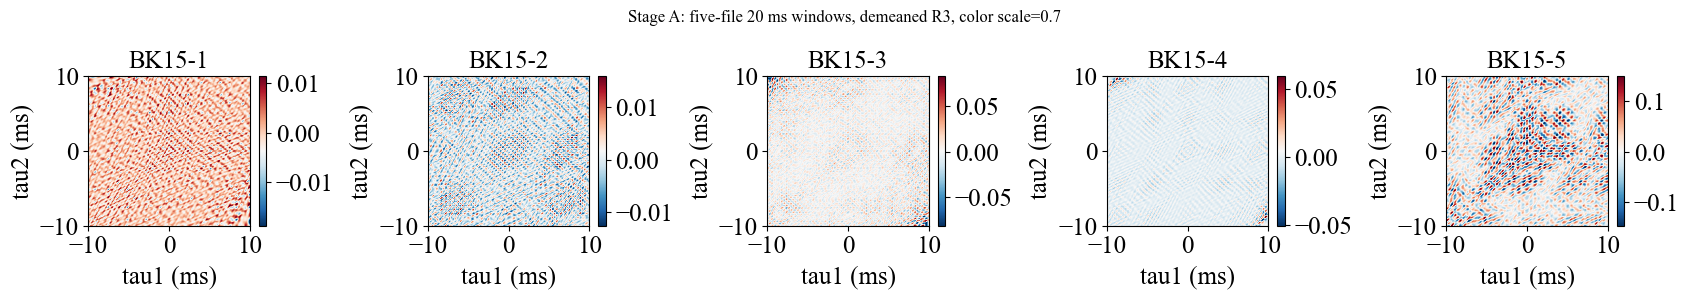

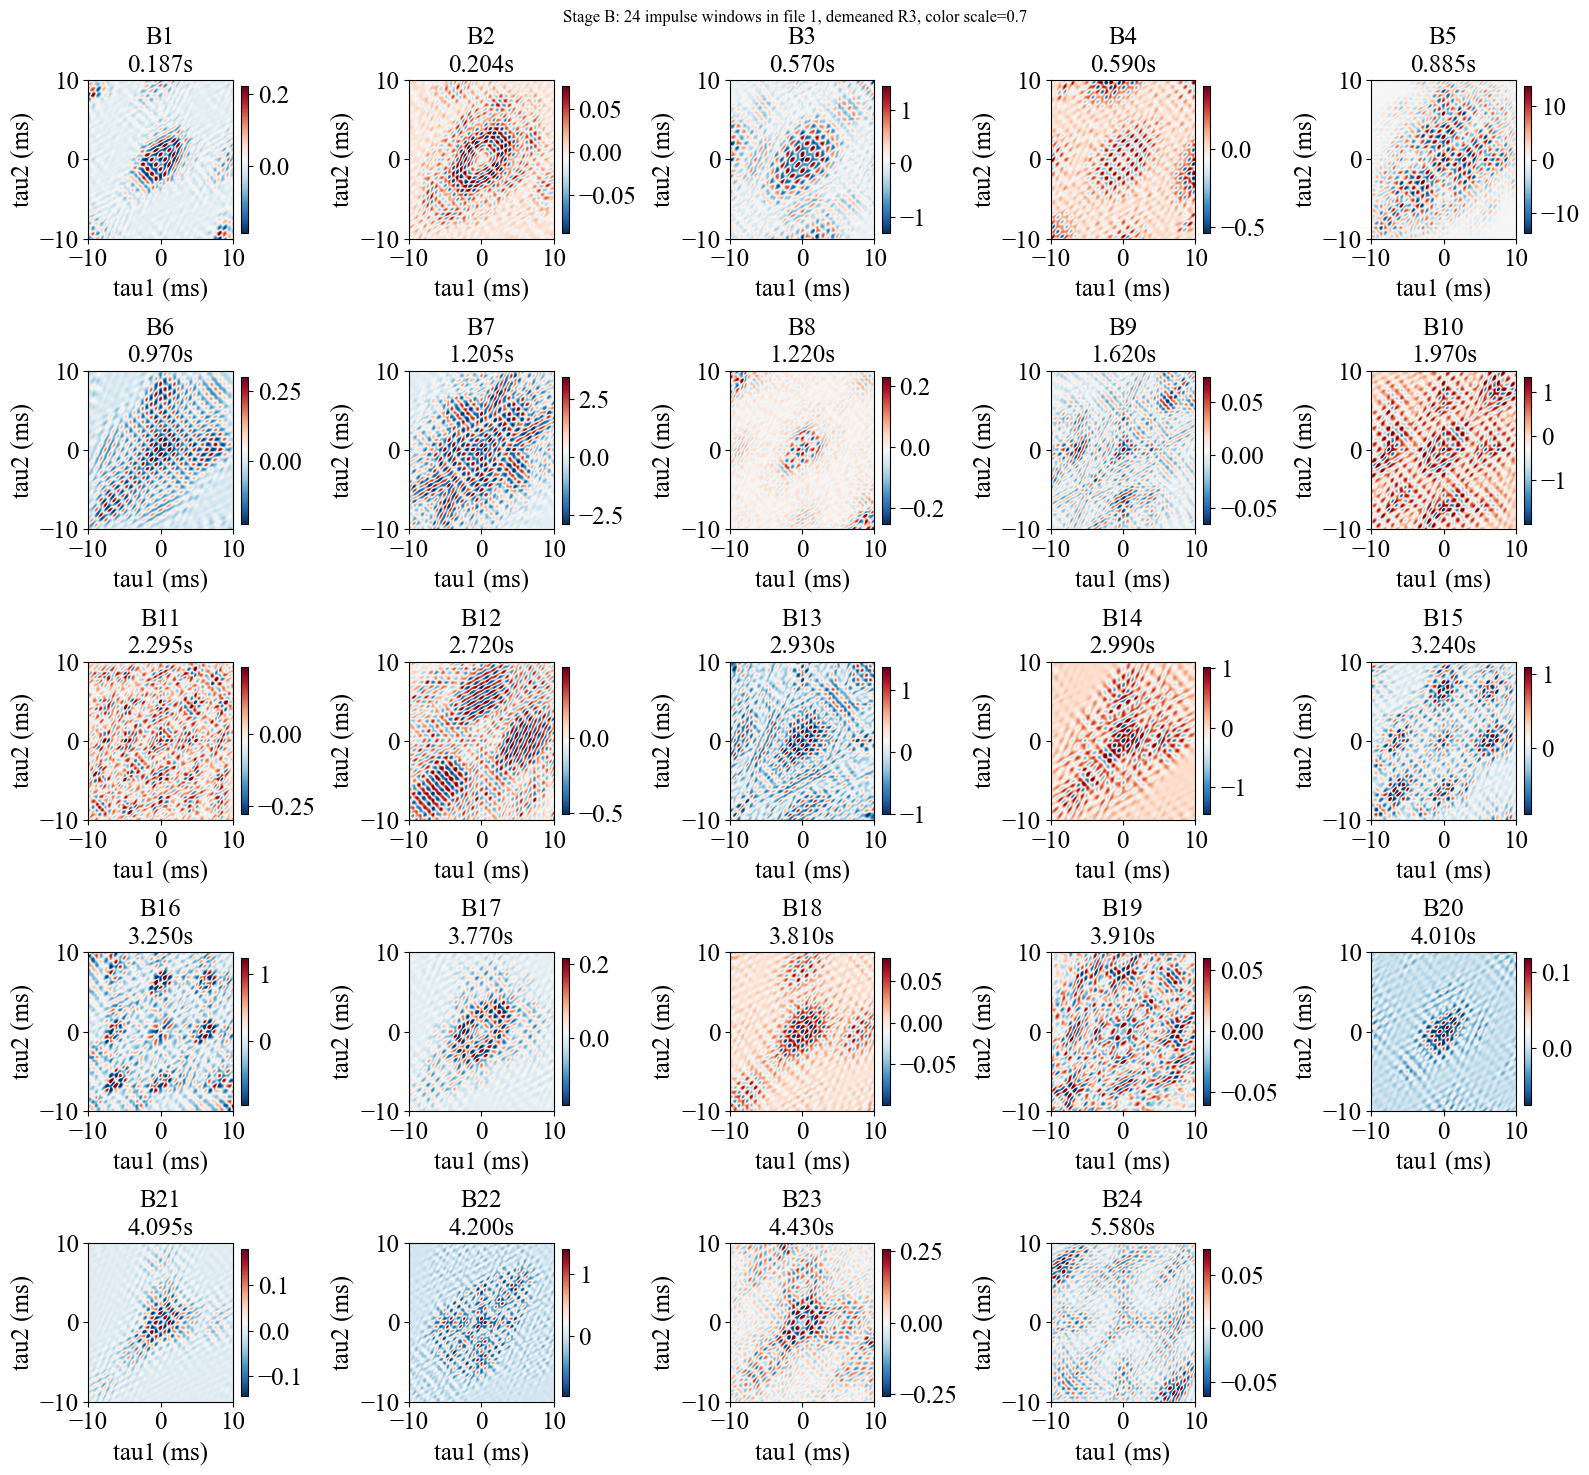

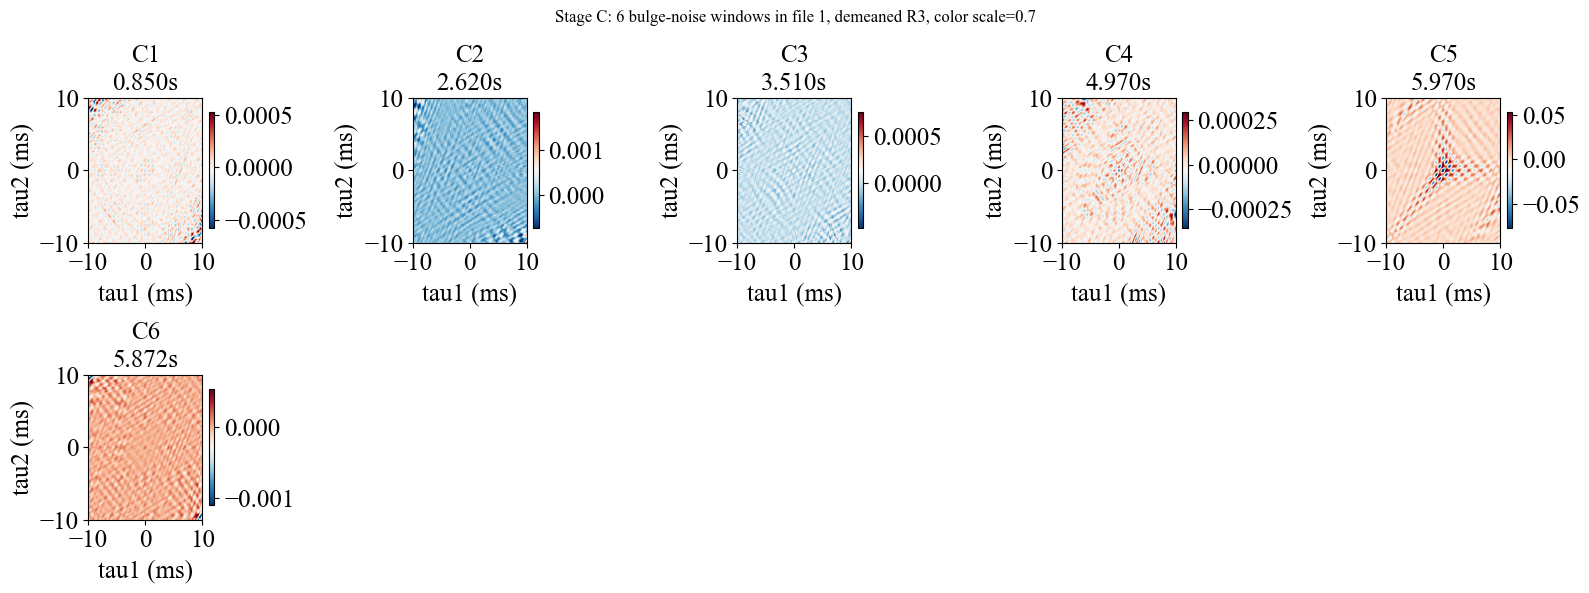

(<Figure size 1600x600 with 16 Axes>,
 array([[<Axes: title={'center': 'C1\n0.850s'}, xlabel='tau1 (ms)', ylabel='tau2 (ms)'>,
         <Axes: title={'center': 'C2\n2.620s'}, xlabel='tau1 (ms)', ylabel='tau2 (ms)'>,
         <Axes: title={'center': 'C3\n3.510s'}, xlabel='tau1 (ms)', ylabel='tau2 (ms)'>,
         <Axes: title={'center': 'C4\n4.970s'}, xlabel='tau1 (ms)', ylabel='tau2 (ms)'>,
         <Axes: title={'center': 'C5\n5.970s'}, xlabel='tau1 (ms)', ylabel='tau2 (ms)'>],
        [<Axes: title={'center': 'C6\n5.872s'}, xlabel='tau1 (ms)', ylabel='tau2 (ms)'>,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object))

In [ ]:
# ---------- 4.3.3 三阶二维自相关：阶段 A / B / C 单独绘图 ----------
TAU_PLANE_MS_433 = 10.0
MAX_PLANE_PTS_433 = 2001
R3_COLOR_SCALE_433 = 0.70
R3_NCOL_433 = 5

items_A = [(label.split(' (')[0], item) for label, item in multi_res.items()]
lags_A, tau_A_ms, _, _, _, step_A = lag_grid_for_segments([item for _, item in items_A], fs42, TAU_PLANE_MS_433, max_plane_pts=MAX_PLANE_PTS_433)
planes_A = {label: higher_order_plane(item[3].astype(float), lags_A, fix=0, order=3) for label, item in items_A}
plot_r3_plane_grid(items_A, planes_A, tau_A_ms, title=f'Stage A: five-file 20 ms windows, demeaned R3, color scale={R3_COLOR_SCALE_433:g}', color_scale=R3_COLOR_SCALE_433, ncol=5, figsize_per_ax=(3.4, 3.0))

items_B = [(f'B{j + 1}\n{item[2][0]:.3f}s', item) for j, item in enumerate(seg_resB)]
lags_B, tau_B_ms, _, _, _, step_B = lag_grid_for_segments([item for _, item in items_B], fs42, TAU_PLANE_MS_433, max_plane_pts=MAX_PLANE_PTS_433)
planes_B = {label: higher_order_plane(item[3].astype(float), lags_B, fix=0, order=3) for label, item in items_B}
plot_r3_plane_grid(items_B, planes_B, tau_B_ms, title=f'Stage B: {len(items_B)} impulse windows in file 1, demeaned R3, color scale={R3_COLOR_SCALE_433:g}', color_scale=R3_COLOR_SCALE_433, ncol=R3_NCOL_433, figsize_per_ax=(3.2, 3.0))

items_C = [(f'C{j + 1}\n{item[2][0]:.3f}s', item) for j, item in enumerate(seg_resC)]
lags_C, tau_C_ms, _, _, _, step_C = lag_grid_for_segments([item for _, item in items_C], fs42, TAU_PLANE_MS_433, max_plane_pts=MAX_PLANE_PTS_433)
planes_C = {label: higher_order_plane(item[3].astype(float), lags_C, fix=0, order=3) for label, item in items_C}
plot_r3_plane_grid(items_C, planes_C, tau_C_ms, title=f'Stage C: {len(items_C)} bulge-noise windows in file 1, demeaned R3, color scale={R3_COLOR_SCALE_433:g}', color_scale=R3_COLOR_SCALE_433, ncol=R3_NCOL_433, figsize_per_ax=(3.2, 3.0))


#### 4.3.4 四阶自相关（固定 $\tau_3$ 的二维切片平面 + 对角切片）

在 4.2.3 三阶自相关的基础上，计算**四阶自相关**，时延在本节**单独定义、可调**（与 4.2.2 / 4.2.3 无关）：

$$R_4(\tau_1,\tau_2,\tau_3)=\frac{1}{N_{\tau_1,\tau_2,\tau_3}}\sum_{t} x(t)\,x(t+\tau_1)\,x(t+\tau_2)\,x(t+\tau_3)$$

- **二维切片平面**：固定第三时延 `TAU4_FIX_MS` 后随 $(\tau_1,\tau_2)$ 变化；
- **对角切片曲线**：$R_4(\tau,\tau,\tau)$（与三阶对角切片同一横轴可比较）。

复用 0.4 节的辅助函数 `higher_order_plane` / `lag_shift_zero_fill` / `ac4_diag`；本节时延参数（独立定义、可调）：`TAU_PLANE_MS4`（$\tau_1/\tau_2$ 半宽，ms）、`TAU_SLICE_MS4`（对角切片半宽，ms）、`TAU4_FIX_MS`（固定 $\tau_3$，ms）、`SEG_IDX_424`（参与绘制的片段索引）。抽稀与内存约束同 4.2.3。

In [ ]:
# ---------- 4.3.4 四阶自相关：固定 tau3 的二维切片平面 + 对角切片（依赖 0.4 节函数） ----------
# 时延参数在本节单独定义、可调（与 4.2.2 / 4.2.3 无关）：
TAU_PLANE_MS4 = 10      # 二维切片平面 tau1/tau2 半宽 (±ms)，可调
TAU_SLICE_MS4 = 10.0    # 对角切片曲线半宽 (±ms)，可调
TAU4_FIX_MS = 0.0       # 固定的第三时延 tau3 (ms)，可调
SEG_IDX_424 = [0, 1, 2, 3, 4, 5]   # 参与绘制的片段索引（seg_res 下标），可调

d_tau = 1e3 / fs42                 # 每点时延 (ms)
_nmax4 = min(len(seg_res[i][3]) for i in SEG_IDX_424) - 1
Tp4 = min(int(round(TAU_PLANE_MS4 / d_tau)), _nmax4)   # 平面半宽（点）
Ts4 = min(int(round(TAU_SLICE_MS4 / d_tau)), _nmax4)   # 切片半宽（点）
t3 = max(-Tp4, min(Tp4, int(round(TAU4_FIX_MS / d_tau))))  # 固定 tau3（点）
if Tp4 < TAU_PLANE_MS4 / d_tau - 0.5:
    print(f'平面半宽受片段长度约束: TAU_PLANE_MS4={TAU_PLANE_MS4:g} ms → {Tp4*d_tau:.3f} ms')

# 平面单维最大点数（内存上界：P 至多 2001×2001 float64 ≈ 32 MB，可调）；抽稀逻辑同 4.2.3
MAX_PLANE_PTS4 = 2001
_step4 = int(np.ceil((2 * Tp4 + 1) / MAX_PLANE_PTS4))
if _step4 > 1:
    print(f'平面时延网格抽稀 {_step4}x: TAU_PLANE_MS4={TAU_PLANE_MS4:g} ms ({2*Tp4+1} 点) '
          f'→ 每 {_step4} 点采样一点（共 {int(np.ceil((2*Tp4+1)/_step4))} 点），保持显示范围')
lags_plane4 = np.arange(-Tp4, Tp4 + 1, _step4)
tau_plane_ms4 = lags_plane4 * d_tau
tau_slice_ms4 = np.arange(-Ts4, Ts4 + 1) * d_tau


r4_plane, r4_diag = {}, {}
for i in SEG_IDX_424:
    seg = seg_res[i][3].astype(float)
    r4_plane[i] = higher_order_plane(seg, lags_plane4, fix=t3, order=4)
    r4_diag[i] = ac4_diag(seg, Ts4)
    print(f'Segment {i + 1} (t={seg_res[i][2][0]:.3f} s): R4(0,0,0)={r4_diag[i][Ts4]:.4g}')

# ---------- 绘图 1：四阶对角切片曲线（各片段叠加） ----------
cyc = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, ax = plt.subplots(figsize=(11, 3.6))
for k, i in enumerate(SEG_IDX_424):
    ax.plot(tau_slice_ms4, r4_diag[i], lw=1.3, color=cyc[k % len(cyc)],
            label=f'Seg {i + 1} ({seg_res[i][2][0]:.3f} s)')
ax.axhline(0, color='k', lw=0.8, alpha=0.6)
ax.set_xlabel('Lag (ms)')
ax.set_ylabel('R4(tau,tau,tau) = E[x(t)x(t+tau)^3]')
ax.set_title(f'Fourth-order diagonal slice (half-width {TAU_SLICE_MS4:g} ms)')
ax.legend(fontsize=9, ncol=3)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ---------- 绘图 2：四阶二维切片平面（固定 tau3，每片段一图） ----------
for i in SEG_IDX_424:
    fig, ax = plt.subplots(figsize=(6, 4.6))
    im = ax.imshow(r4_plane[i], origin='lower', aspect='auto', cmap='RdBu_r',
                   extent=[tau_plane_ms4[0], tau_plane_ms4[-1], tau_plane_ms4[0], tau_plane_ms4[-1]])
    ax.set_xlabel('tau1 (ms)'); ax.set_ylabel('tau2 (ms)')
    ax.set_title(f'Seg {i + 1} ({seg_res[i][2][0]:.3f} s): '
                 f'R4(tau1,tau2; tau3={TAU4_FIX_MS:g} ms)')
    plt.colorbar(im, ax=ax)
    plt.tight_layout(); plt.show()


平面时延网格抽稀 10x: TAU_PLANE_MS4=10 ms (20001 点) → 每 10 点采样一点（共 2001 点），保持显示范围
Segment 1 (t=0.187 s): R4(0,0,0)=6.225
Segment 2 (t=0.204 s): R4(0,0,0)=1.732
Segment 3 (t=0.570 s): R4(0,0,0)=21.55
Segment 4 (t=0.590 s): R4(0,0,0)=5.766


KeyboardInterrupt: 

## 5、 2.0 m/s流速

### 5.1、 2.0 m/s 数据自相关模板检测（读取本地模板）

This subsection reads the local mean autocorrelation template saved by 4.2.4, then applies short-time autocorrelation-template detection to each TDMS file under `E:\codes\pccp\ZZ2026\bk\2.0`, with one plot per file.

The sliding-window, threshold, event-merge, and preprocessing parameters are defined independently in Section 5.1. The default template path is the same as in 4.2.4.


In [ ]:
# ---------- 5.1 parameters: paths, preprocessing, and autocorr-template detection ----------
# Data folder for this subsection. Edit FILES_51 if only part of the TDMS files should be processed.
DATA_DIR_51 = Path(r'E:\codes\pccp\ZZ2026\bk\2.0')
FILES_51 = sorted(DATA_DIR_51.glob('*.tdms'))

# Local autocorrelation template saved by Section 4.2.4.
AC51_TEMPLATE_PATH = Path(r'E:\codes\ZZ-BK\notebooks\outputs\autocorr_template_bk15_mean.npz')

# Preprocessing parameters: zero-phase Butterworth bandpass before feature calculation.
BP51_LO = 0.5e3       # Bandpass lower cutoff (Hz)
BP51_HI = 20e3        # Bandpass upper cutoff (Hz)
BP51_ORDER = 4        # Butterworth filter order

# Short-time autocorrelation-template feature parameters.
AC51_WIN_MS = 20.0              # Sliding window length (ms); aligned with the template window length
AC51_STEP_MS = 10.0             # Sliding step (ms); smaller values give denser detection curves
AC51_CORR_LAG_MS = (1.0, 17.0)  # Absolute lag range used for Pearson correlation (ms)

# Soft-threshold event detection parameters applied to the correlation curve.
AC51_K = 6.0                    # MAD threshold multiplier; larger values are stricter
AC51_MIN_GAP = 4                # Maximum frame gap for merging adjacent detections into one event

print(f'2.0 m/s directory has {len(FILES_51)} TDMS files:')
for _p in FILES_51:
    print('  -', _p.name)


2.0 m/s directory has 4 TDMS files:
  - SemiPhase-1MHz-2026-8-21-18-56-0.tdms
  - SemiPhase-1MHz-2026-8-21-19-5-17.tdms
  - SemiPhase-1MHz-2026-8-21-19-6-23.tdms
  - SemiPhase-1MHz-2026-8-21-19-7-11.tdms


Loaded autocorr template: E:\codes\ZZ-BK\notebooks\outputs\autocorr_template_bk15_mean.npz
SemiPhase-1MHz-2026-8-21-18-56-0.tdms: thr=0.353, events=1
SemiPhase-1MHz-2026-8-21-19-5-17.tdms: thr=0.403, events=1
SemiPhase-1MHz-2026-8-21-19-6-23.tdms: thr=0.385, events=1
SemiPhase-1MHz-2026-8-21-19-7-11.tdms: thr=0.369, events=1


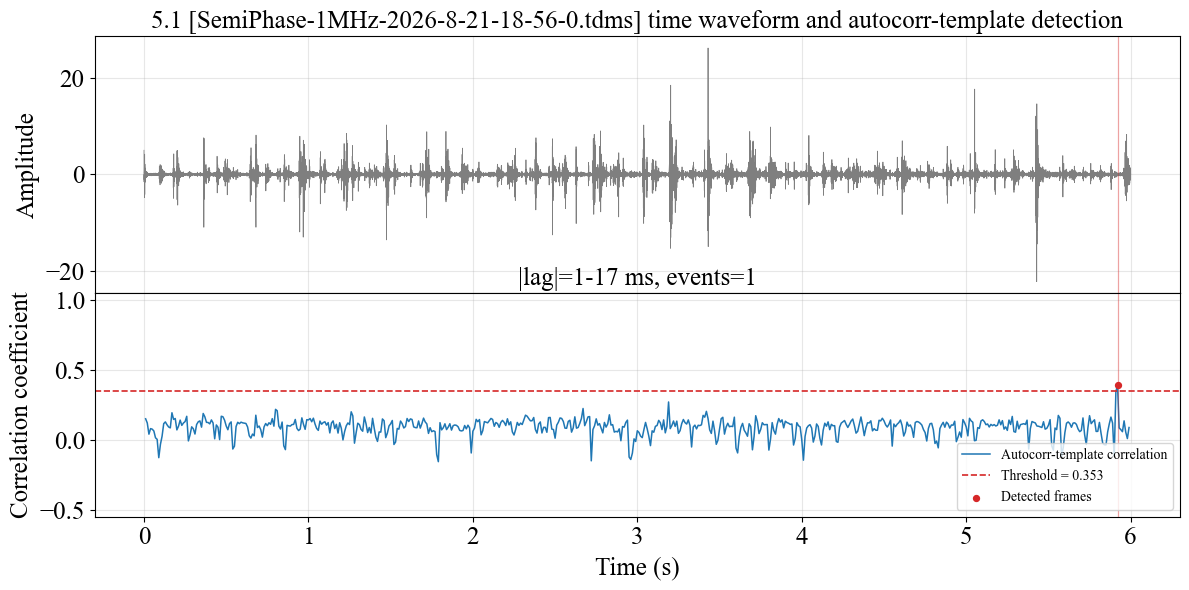

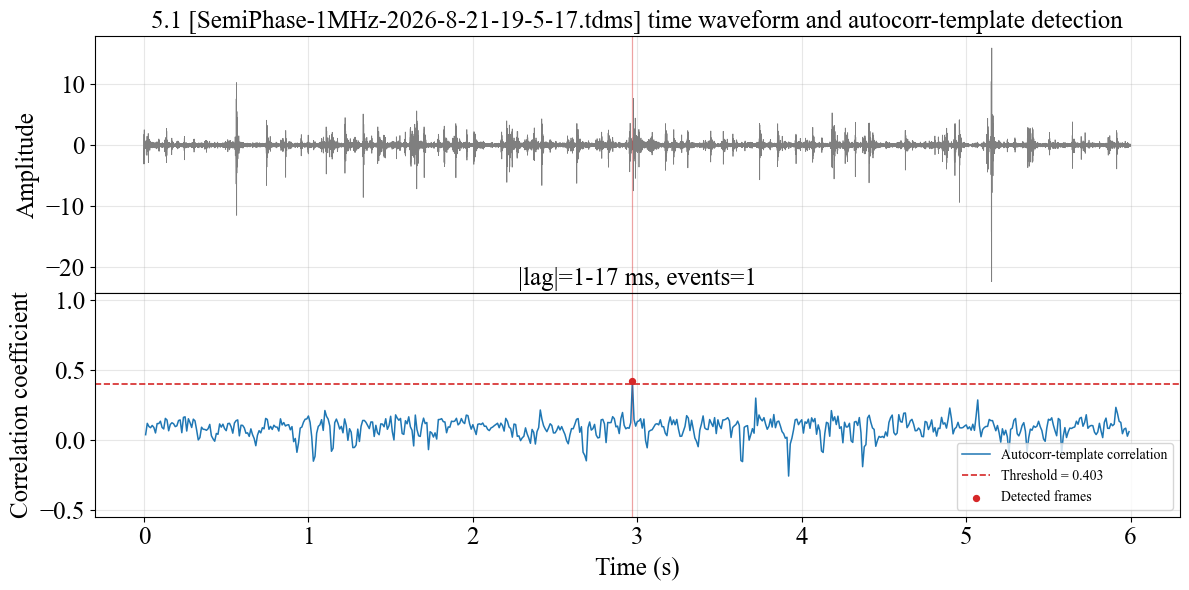

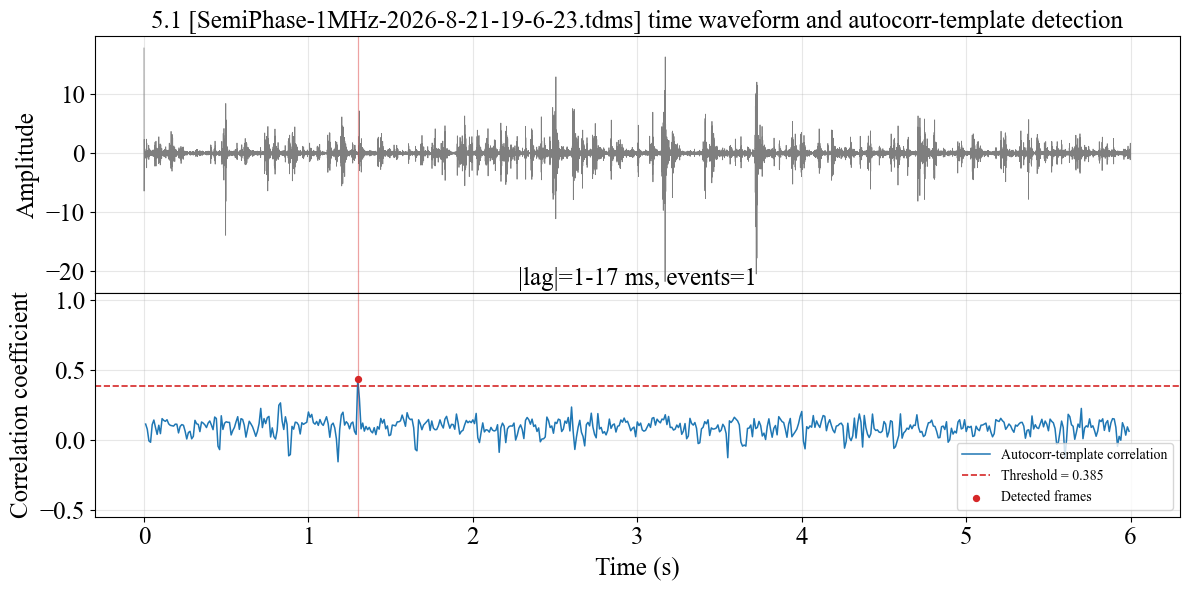

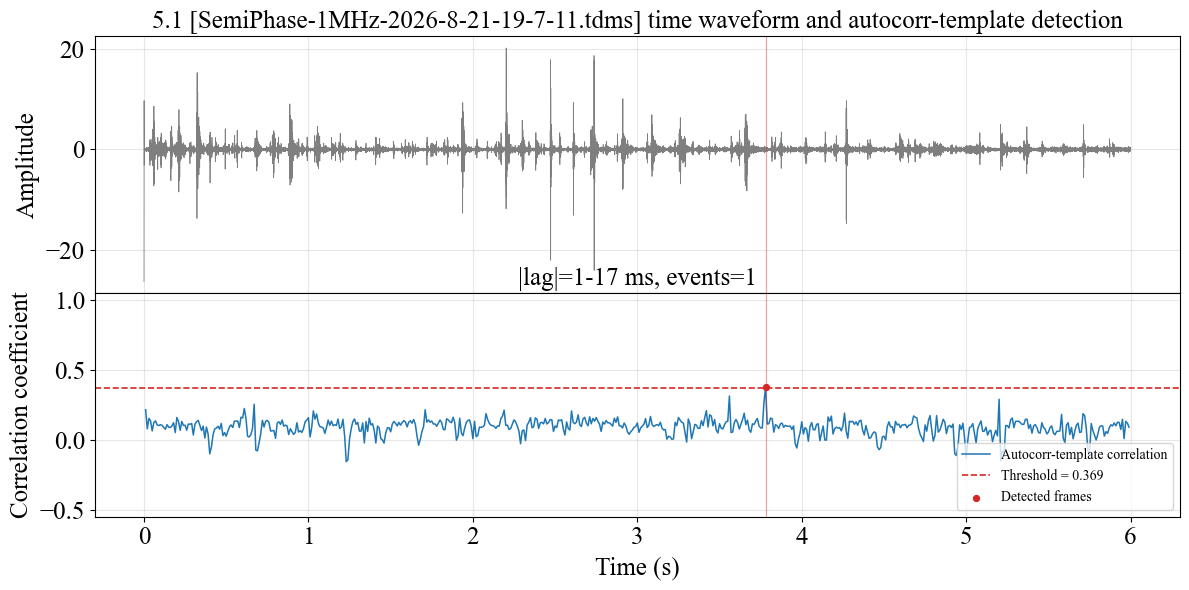

In [ ]:
# ---------- 5.1 compute and plot: waveform + autocorr-template correlation ----------
ac51_results = detect_autocorr_template_files(
    FILES_51, AC51_TEMPLATE_PATH,
    win_ms=AC51_WIN_MS, step_ms=AC51_STEP_MS,
    corr_lag_ms=AC51_CORR_LAG_MS,
    threshold_k=AC51_K, min_gap_frames=AC51_MIN_GAP,
    band=(BP51_LO, BP51_HI), order=BP51_ORDER,
    channel=SEL_CH,
)
plot_autocorr_template_detection_results(ac51_results, section_label='5.1')
